# Final Homework — Unsupervised Learning, Dimensionality Reduction and Anomaly Detection

**Holon Institute of Technology (HIT) — Faculty of Computer Science**

| | |
|---|---|
| **Course** | Introduction to Data Science |
| **Assignment** | Final Homework |
| **Student name** | Sean Mazon |
| **ID number** | 212234660 |
| **Head lecturer** | Dr. Uri Itai |
| **Teaching assistant** | Hanit Hadad Ohayon |
| **Grader** | Dror Meirovich |
| **Submission deadline** | 18.09.2026 |

---

## Table of Contents

0. [Introduction](#0-introduction)
1. [Dataset Selection](#1-dataset-selection)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Dimensionality Reduction (PCA)](#3-dimensionality-reduction-pca)
4. [Clustering Analysis](#4-clustering-analysis)
5. [Multi-Dimensional Anomaly Detection](#5-multi-dimensional-anomaly-detection)
6. [Comparison of Anomaly Detection Methods](#6-comparison-of-anomaly-detection-methods)
7. [Critical Analysis and Reflection](#7-critical-analysis-and-reflection)
8. [Ethical Considerations](#8-ethical-considerations)
9. [Final Visualization Dashboard](#9-final-visualization-dashboard-optional)

## 0. Introduction

This chapter states the objective, the stance the analysis takes towards its own
results, and the methodology. It contains no code and no results; the analysis
begins in chapter 1.

### 0.1 Objective

The assignment sets out to explore the structure of a real-world dataset using
unsupervised methods: clustering, dimensionality reduction, and multi-dimensional
anomaly detection. No labels guide any part of it.

Its framing matters more than its component list. The assignment opens by
observing that unsupervised problems are **fundamentally ill-defined**: nothing
tells us how many clusters should exist, which observations are anomalous, or
whether meaningful clusters and anomalies exist at all. Different methods,
distance measures and parameter choices can lead to different conclusions, and
more than one may be reasonable.

Two consequences follow, and they govern how this notebook is written.

**First, the goal is not to produce output.** The assignment states plainly that
it does not grade "beautiful" clusters. It grades understanding of what the
methods assume, why they disagree, and what their results mean for the data.
Every algorithm applied here is therefore accompanied by its mathematical
intuition, its assumptions, and an account of where those assumptions fail on
this dataset.

**Second, a negative result is a legitimate result.** The assignment states
explicitly that an inability to find meaningful clusters, significant anomalies
or effective dimensionality reduction does not indicate poor analysis — the
structure may simply not be there. This notebook therefore commits in advance to
reporting weak or absent structure where that is what the evidence shows, rather
than selecting the parameters that produce the most attractive picture. Where
methods disagree, the disagreement is reported and examined rather than resolved
by preference.

### 0.2 Methodology

Each analytical section follows the same four-part pattern:

- **Method** — what is being done and why.
- **Results** — the actual numerical and visual output.
- **Interpretation** — what the results mean, including where they contradict
  what was expected.
- **Conclusion** — the single insight the section establishes.

Interpretations are written **after** the results have been read, never drafted
in advance. Where the data shows a pattern but cannot establish its cause, the
proposed cause is labelled as a hypothesis and the evidence that would test it is
named. Claims about what an algorithm "found" are kept separate from claims about
what is true of the games themselves.

The analysis proceeds in the order the assignment specifies: the dataset and its
provenance, exploratory analysis, PCA, clustering of both samples and features,
the three required anomaly detection methods, their comparison, critical
reflection, and ethical considerations.

### 0.3 What the Assignment Requires and What Is Chosen Here

The assignment fixes the analytical programme but leaves the material open. Kept
distinct throughout:

**Required by the assignment** — the five dataset selection criteria and the
provenance description; the exploratory, PCA, clustering, anomaly-detection,
comparison, reflection and ethics sections with their listed contents; at least
three clustering methods; clustering of the feature space as well as the samples;
all three anomaly detection methods; mathematical intuition for each method.

**Chosen here, and justified where it appears** — the dataset; which eight
features form the numeric matrix and which columns are held back; the log
transform applied to the heavy-tailed features; which three clustering algorithms
are used; how every hyperparameter is selected; and which evaluation metrics are
reported beyond the one the assignment names.

No choice in the second list is presented as though it came from the first.

## 1. Dataset Selection

**Method.** This chapter identifies the dataset, verifies it against the five
selection criteria, records what the source does and does not document, defines
every feature used, states which columns were excluded and why, and sets out the
limitations that constrain everything the later chapters can claim.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# The helper package for this assignment sits one level above the notebook and
# adds Assignment 1's package to the path, so the cleaning and the derived
# features defined there are reused unchanged rather than reimplemented.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from unsupervised.data_setup import (
    ANNOTATION_VARIABLES,
    LOG_TRANSFORMED_FEATURES,
    MODEL_FEATURES,
    NEW_FEATURES,
    ORIGINAL_FEATURES,
    PRIOR_ENGINEERED_FEATURES,
    SNAPSHOT_DATE,
    build_matrix,
    describe_feature_provenance,
    describe_source_file,
    load_analysis_frame,
    summarise_excluded_candidates,
    verify_selection_requirements,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

games = load_analysis_frame()
print(f"Rows loaded: {len(games):,}")

Rows loaded: 1,500


### 1.1 Source and Provenance

The dataset is the one used in Assignments 1 and 2, which the assignment
explicitly permits. It records the 1,500 highest-revenue games released on Steam
during 2024.

In [2]:
describe_source_file()

,Value
Property,
File,Steam_2024_bestRevenue_1500.csv
Size,"180,690 bytes (176.5 KB)"
Distributed via,"Kaggle, user 'alicemtopcu'"
Dataset URL,https://www.kaggle.com/datasets/alicemtopcu/top-1500-games-on-steam-by-revenue-09-09-2024
Extraction date,"2024-09-09, stated in the dataset title"
Why it was collected,Not specified by the source
Who originally collected it,Not specified by the source
Licence,Not recorded in the downloaded file
Methodology note,None supplied with the file


**Where the dataset comes from.** It was downloaded from Kaggle, from the dataset
*Top 1500 Games on Steam by Revenue (09-09-2024)*, published by the user
`alicemtopcu`. The extraction date of 9 September 2024 is stated in the dataset's
own title, and Assignment 1 corroborated it independently: the file's creation
timestamp is 11 September 2024, two days later, which is what a download delay
looks like.

**Why it was collected — not specified by the source.** The Kaggle page carries
no statement of purpose, and no datasheet, methodology note or licence file
accompanies the download. Nothing in the file records why it was assembled. The
field selection is consistent with commercial market intelligence rather than
research, but that is an inference from the shape of the data and is not
documented anywhere, so it is recorded as such rather than asserted.

**Who collected it — not specified by the source.** The Kaggle account is the
*distributor*, and a distributor is not necessarily the collector. The originating
producer is not named on the dataset page or in the file.

One fact bears on this and is verifiable independently: **Valve publishes no
per-title sales or revenue figures for Steam.** No public interface exposes how
many copies a game has sold. It follows that `revenue` and `copiesSold` cannot be
direct measurements and must be estimates produced by some third-party model.
Assignment 2 established the point quantitatively — regressing log revenue on log
copies and log price returned coefficients of 0.988 and 1.005 with an R² of
0.9901, recovering an accounting identity almost exactly. **Which** estimator
produced them, and with what error, is not stated. This is the single most
important property of the dataset for an anomaly-detection assignment, and
section 1.5 returns to it.

### 1.2 Verification Against the Selection Criteria

The assignment lists five criteria a dataset must satisfy. They are checked in
code rather than asserted.

In [3]:
verify_selection_requirements(games)

,Required,Observed,Status
Requirement,,,
"At least 1,000 rows",">= 1,000","1,500",PASS
At least 8 features,>= 8,"9 in the source file, excluding 2 identifiers; 8 used for modelling",PASS
Mostly numerical variables,majority numeric,5 of 9 source features are numeric; the modelling matrix is 8/8 numeric,PASS
Real-world dataset,yes,"Commercially released Steam titles, published on Kaggle",PASS
No pre-labeled anomaly column,none present,"No column encodes an outlier, anomaly or class label",PASS


**Results and interpretation.** All five criteria are satisfied, though two
deserve a precise reading rather than a tick.

**"At least 8 features."** The source file has 11 columns, two of which — `name`
and `steamId` — are identifiers with 1,500 distinct values apiece and carry no
distributional information. Excluding them leaves **9 analysable features**, above
the minimum. The numeric matrix built in section 1.3 uses **8** of them.

**"Mostly numerical variables."** Of the 9 analysable source features, **5 are
numeric** — a majority, so the criterion holds, but only just. This is the
dataset's weakest point against the assignment, since PCA, distance-based
clustering and multi-dimensional anomaly detection all operate on numeric
matrices. Section 1.3 sets out how a matrix of eight numeric features is obtained
without inventing anything for the purpose.

**"No pre-labeled anomaly column."** No column in the file encodes an outlier,
anomaly, or class label of any kind. Nothing in the analysis that follows has
access to a ground truth, which is the condition the assignment intends.

### 1.3 The Analysis Matrix, and Where Each Feature Came From

**Method.** A concern applies to any dataset that only narrowly meets a feature
count: features can always be manufactured to satisfy it, and manufactured
features distort exactly the analyses this assignment performs. Ratios of
existing columns create collinearity that PCA then reports as redundancy;
duplicate encodings of one variable create correlations that clustering then
reports as structure.

Each feature is therefore classified by origin, and the count is checked against
the requirement **without** any feature created for this assignment.

In [4]:
print(f"Original dataset columns                     : {len(ORIGINAL_FEATURES)}  {ORIGINAL_FEATURES}")
print(f"Engineered in Assignment 1, reused in A2     : {len(PRIOR_ENGINEERED_FEATURES)}  {PRIOR_ENGINEERED_FEATURES}")
print(f"Newly created for this assignment            : {len(NEW_FEATURES)}  {NEW_FEATURES or '[]'}")
print()
print(f"Modelling matrix                             : {len(MODEL_FEATURES)} features")
print(f"Minimum required by the assignment           : 8")
print(f"Requirement met without any new feature      : {len(ORIGINAL_FEATURES) + len(PRIOR_ENGINEERED_FEATURES) >= 8}")

display(describe_feature_provenance())

Original dataset columns                     : 5  ['copiesSold', 'price', 'revenue', 'avgPlaytime', 'reviewScore']
Engineered in Assignment 1, reused in A2     : 3  ['daysOnSale', 'publisherReleaseCount', 'selfPublished']
Newly created for this assignment            : 0  []

Modelling matrix                             : 8 features
Minimum required by the assignment           : 8
Requirement met without any new feature      : True


,Provenance,Meaning,Unit
Feature,,,
copiesSold,Original column,Estimated lifetime units sold at the snapshot date,count
price,Original column,Listed store price; zero denotes a free-to-play title,USD (currency not stated by the source; inferred)
revenue,Original column,Estimated lifetime gross revenue at the snapshot date,USD (currency and gross/net basis not stated; inferred)
avgPlaytime,Original column,Average time played per owner,hours (unit not stated; inferred from the observed range)
reviewScore,Original column,"Share of user reviews that are positive; 0 is a placeholder, not a score","percent, 0-100 (definition not stated; inferred)"
daysOnSale,Engineered in Assignment 1,"Days between release and the 2024-09-09 snapshot, i.e. exposure",days
publisherReleaseCount,Engineered in Assignment 1,Titles in this dataset by the most prolific publisher credited on the game,count
selfPublished,Engineered in Assignment 1,"1 when the publisher and developer strings match, 0 otherwise",binary


**Interpretation — what each feature represents.** The table above gives the
meaning and unit of all eight. Three points are worth drawing out.

**Five features are original columns** and three were derived in Assignment 1 and
reused unchanged in Assignment 2. **No feature was created for this assignment.**
The eight-feature minimum is met by 5 + 3 = 8, so nothing was engineered to reach
the threshold.

**Several units are inferred rather than documented.** The source states no
currency for `price` and `revenue`, no unit for `avgPlaytime`, and no definition
for `reviewScore`. USD, hours and percent-positive are the only readings
consistent with the observed ranges, but they are inferences. An undocumented
unit is a limitation of the data, and marking it visibly is more honest than
silently adopting the obvious guess.

**Two features are not continuous measurements**, which matters for methods that
assume continuity:

- `selfPublished` is **binary**. It is a legitimate feature — Assignment 1 found
  publisher and developer identical for roughly half the catalogue — but a
  balanced binary variable cannot produce a large standardised deviation, so it
  can never contribute to a Z-score anomaly. Section 5.1 measures this directly.
  It also carries full weight in Euclidean distance once standardised, so it
  influences clustering considerably. That is a property of the **representation**
  chosen, not of any tuning parameter, and section 4 examines it under that
  heading.
- `publisherReleaseCount` is a **count computed within this dataset**. Because
  the dataset was selected on revenue, a studio appears often partly because
  several of its titles earned well, so the feature carries a faint trace of the
  selection. Assignment 2 measured its rank correlation with log revenue at 0.12.

In [5]:
summarise_excluded_candidates()

,Would have been,Reason for exclusion
Column,,
publisherTier,Would have been new for this assignment,Ordinal encoding of plotClass. Excluded on evidence: a Z-score on it flags exactly the 52 AAA ti...
releaseMonth,Would have been new for this assignment,Correlates -0.99 with daysOnSale because both derive from releaseDate. Including both would crea...
"revenuePerCopy, revenuePerDay, priceRealisation",Engineered in Assignment 1,"Algebraic functions of features already in the matrix, so they would manufacture collinearity ra..."
"name, steamId",Original columns,"Identifiers with 1,500 distinct values; carry no distributional signal."
"publishers, developers",Original columns,"Free-text with 1,131 and 1,406 distinct values; not numeric and not encodable at this cardinalit..."
"plotClass, priceBand, isFreeToPlay",Engineered in Assignment 1,Categorical. Held back as annotations used to interpret and validate the clusters and anomalies ...


**Interpretation — what was excluded, and why.** Two exclusions were decided on
measured evidence rather than preference, and both would have corrupted later
chapters had they been kept.

**`publisherTier`** — an ordinal encoding of studio scale (Indie < AA < AAA) —
was the only candidate that would have been newly created here. It was rejected
on three independent grounds. A Z-score computed on it flags exactly the 52 AAA
titles, which would convert a **studio label into a statistical anomaly** and
contaminate chapter 5. It raises the number of components needed for 90% of
variance from six to seven, adding a dimension without adding structure. And it
lowers the k = 3 silhouette from 0.195 to 0.181. Encoding three categories
as 0, 1, 2 also imposes an arbitrary claim that the step
from Indie to AA equals the step from AA to AAA, which directly distorts every
distance computed from it. `plotClass` is therefore retained as an **annotation**:
it is used to interpret and validate the clusters and anomalies that the methods
find, which is more informative than burying it inside a distance metric.

**`releaseMonth`** correlates **−0.99** with `daysOnSale`, because both are
functions of the release date under a fixed snapshot. Including both would have
placed a near-duplicate pair in the matrix, and PCA would then have reported the
resulting redundancy as a finding about the data rather than an artefact of the
feature set.

The three ratio features from Assignment 1 — `revenuePerCopy`, `revenuePerDay`
and `priceRealisation` — are algebraic functions of columns already present and
were excluded for the same reason.

In [6]:
analysis_matrix = build_matrix(games, log_transform=False)

print(f"Matrix shape                : {analysis_matrix.shape[0]:,} x {analysis_matrix.shape[1]}")
print(f"All columns numeric         : {analysis_matrix.dtypes.apply(lambda d: d.kind in 'ifb').all()}")
print(f"Duplicate rows              : {analysis_matrix.duplicated().sum()}")
print(f"Constant columns            : {[c for c in analysis_matrix if analysis_matrix[c].nunique() <= 1] or 'none'}")
print()
print("Missing values (placeholders converted by the Assignment 1 cleaning):")
print(analysis_matrix.isna().sum().loc[lambda counts: counts > 0].to_string())
print()
print(f"Annotation variables held out of the matrix : {ANNOTATION_VARIABLES}")
print(f"Heavy-tailed features to be log-transformed : {LOG_TRANSFORMED_FEATURES}")
print(f"Snapshot date used for daysOnSale           : {SNAPSHOT_DATE:%Y-%m-%d}")

Matrix shape                : 1,500 x 8
All columns numeric         : True
Duplicate rows              : 0
Constant columns            : none

Missing values (placeholders converted by the Assignment 1 cleaning):
avgPlaytime     1
reviewScore    99

Annotation variables held out of the matrix : ['name', 'steamId', 'plotClass', 'priceBand', 'isFreeToPlay']
Heavy-tailed features to be log-transformed : ['copiesSold', 'revenue', 'avgPlaytime', 'publisherReleaseCount']
Snapshot date used for daysOnSale           : 2024-09-09


**Results.** The matrix is 1,500 × 8, fully numeric, with no duplicate rows and
no constant columns. Two features carry missing values — 99 in `reviewScore` and
one in `avgPlaytime` — and both are the placeholder zeros identified in Assignment
1, converted to missing values by the cleaning imported from it rather than left
in as scores of zero. Leaving them would have created a spurious group of 99
identical-looking games that every clustering and anomaly method would then have
reported as structure. Imputation is deferred to the point of use so that each
method's sensitivity to it can be examined.

### 1.4 Annotation Variables

Three categorical columns are deliberately excluded from the numeric matrix and
retained for interpretation: `plotClass` (studio scale), `priceBand`, and
`isFreeToPlay`. Together with `name` they allow a cluster or a flagged anomaly to
be described in terms a reader can recognise — "this cluster is mostly cheap indie
titles", "this anomaly is a free-to-play game" — without those descriptions having
influenced the geometry that produced them.

This separation is what makes the later validation meaningful. If clusters
discovered from eight numeric features turn out to align with studio scale, that
is evidence the structure is real, precisely because studio scale was not
available to the algorithm.

### 1.5 Limitations and Biases

**Method.** The assignment requires possible limitations and biases to be stated.
Four apply here, and each constrains what later chapters may legitimately claim.

**1. Survivorship: the sample is selected on the quantity of greatest interest.**
These are the 1,500 highest-earning games of 2024. They are not a sample of games
on Steam; they are its commercial upper tail. Every statement about distributions,
clusters or anomalies in this notebook therefore describes structure **within an
already-successful population**. An observation flagged as anomalous is anomalous
relative to other top earners, not relative to Steam. Assignment 1 measured one
consequence directly: the relationship between how long a game had been on sale
and how much it earned is absent in this sample, because selecting on revenue
removes it.

**2. The monetary columns are estimates, not measurements.** As section 1.1 set
out, Valve publishes no sales figures, so `revenue` and `copiesSold` are the
output of an undisclosed third-party model with unknown systematic error and no
confidence interval. For an anomaly-detection assignment this is the most
consequential limitation of all: **a point flagged as anomalous may be an
artefact of the estimator rather than an unusual game.** Chapter 6 must therefore
distinguish three possibilities for every flagged observation — a genuine rare
case, a data error, and an estimation artefact — and the dataset alone cannot
always separate them.

**3. Documented placeholders remain a hazard.** `reviewScore` used 0 for "no
score available" in 99 rows and `avgPlaytime` used 0 in one. Both are handled, but
they illustrate that this file encodes missingness as valid numbers. Any
undiscovered instance of the same pattern would be read by every method in this
notebook as a dense group of ordinary observations.

**4. Coverage stops on 6 September 2024.** The fourth quarter — which contains
the Black Friday and winter sales, commercially the most important weeks of the
year — is absent entirely. Structure that is seasonal will not be visible.

**Conclusion.** The dataset satisfies all five selection criteria, and the
eight-feature numeric matrix is built from five original columns and three
features validated in earlier assignments, with nothing engineered to meet the
threshold. Its principal weaknesses are that it is a truncated, revenue-selected
sample and that its two most important variables are modelled rather than
observed. Both are carried forward explicitly rather than noted and forgotten:
the first bounds the population any conclusion describes, and the second bounds
what "anomaly" can be taken to mean.

## 2. Exploratory Data Analysis

**Method.** This chapter does three things. It establishes the structure and
completeness of the matrix; it characterises the distribution of every feature
with a histogram, a box plot, its skewness and its kurtosis; and it examines the
extreme values, distinguishing heavy tails from noise, measurement artefacts and
data-entry problems.

It also settles one preprocessing question that chapters 3 to 5 all depend on:
whether to analyse the heavy-tailed features on their original scale or on a
logarithmic one. That decision is taken here from measurements rather than
assumed in the chapter that first needs it.

In [7]:
from unsupervised.eda import (
    correlation_shift,
    distribution_statistics,
    outlier_counts,
    structural_summary,
)
from unsupervised.plots import (
    apply_house_style,
    plot_boxplot_grid,
    plot_correlation_pair,
    plot_distribution_grid,
    plot_transform_effect,
)

apply_house_style()

raw_matrix = build_matrix(games, log_transform=False)
log_matrix = build_matrix(games, log_transform=True)

structural_summary(games, raw_matrix)

,Value
Property,
Rows,"1,500"
Features in the matrix,8
Columns available in the loaded frame,28
Total cells in the matrix,"12,000"
Missing cells,100 (0.833%)
Features with missing values,"reviewScore (99), avgPlaytime (1)"
Duplicate rows,0
Constant features,none
Numeric dtypes,8 of 8


### 2.1 Structural Analysis

In [8]:
display(raw_matrix.dtypes.rename("dtype").to_frame())
raw_matrix.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(2)

,dtype
copiesSold,int64
price,float64
revenue,float64
avgPlaytime,float64
reviewScore,float64
daysOnSale,int64
publisherReleaseCount,int64
selfPublished,int64


,count,mean,std,min,1%,25%,50%,75%,99%,max
copiesSold,1500.0,141482.57,1132756.66,593.00,1132.99,4918.75,11928.50,37869.75,2087213.99,3.073915e+07
price,1500.0,17.52,12.65,0.00,0.00,9.99,14.99,19.99,59.99,9.999000e+01
revenue,1500.0,2632381.98,27810239.62,20674.00,21259.08,45504.25,109053.00,455156.75,34683031.82,8.377934e+08
avgPlaytime,1499.0,12.57,21.55,0.55,0.88,3.57,6.76,13.11,96.51,2.963300e+02
reviewScore,1401.0,81.59,13.92,11.00,37.00,75.00,85.00,92.00,99.00,1.000000e+02
daysOnSale,1500.0,127.11,68.16,3.00,4.99,74.00,130.00,186.00,245.01,2.520000e+02
publisherReleaseCount,1500.0,3.22,4.28,1.00,1.00,1.00,1.00,3.00,22.00,2.200000e+01
selfPublished,1500.0,0.49,0.50,0.00,0.00,0.00,0.00,1.00,1.00,1.000000e+00


**Results and interpretation.** The matrix is 1,500 × 8 with every column
numeric, no duplicate rows and no constant features. **100 cells are missing —
0.833% of the matrix** — confined to `reviewScore` (99) and `avgPlaytime` (1).
Both are the placeholder zeros documented in chapter 1, converted to missing
values rather than left in as valid measurements.

The summary table already shows why this dataset needs care. For `revenue` the
**mean is $2,632,382 and the median $109,053** — the mean is 24 times the
median, which is possible only if a small number of observations are enormous.
`copiesSold` behaves the same way: mean 141,483 against a median of 11,929. The
99th percentile of revenue is $34.7M while the maximum is $838M, so the top
percentile alone spans a further factor of 24.

Three features behave quite differently and are worth noting because they will
matter later. `daysOnSale` runs from 3 to 252 with a median of 130 and shows no
sign of a tail. `reviewScore` is bounded at 100 and concentrated near it, with a
median of 85. `selfPublished` is binary with a mean of 0.49, so the catalogue
splits almost evenly between self-published and externally published titles.

### 2.2 Distribution Analysis

**Method.** The assignment asks for a histogram, a box plot, the skewness and
the kurtosis of each major feature. All four are reported below for all eight
features. Skewness measures asymmetry, and kurtosis measures how much of the
variance comes from rare extreme values rather than typical ones; a normal
distribution has an excess kurtosis of 0.

In [9]:
distribution_statistics(raw_matrix, log_matrix)

,Skew (raw),Kurtosis (raw),Log applied,Skew (analysis scale),Kurtosis (analysis scale),Distinct values
Feature,,,,,,
copiesSold,18.60,420.0,yes,0.98,1.4,1460
price,1.58,3.9,no,1.58,3.9,58
revenue,22.90,607.8,yes,1.19,1.5,1497
avgPlaytime,7.16,71.5,yes,0.35,0.2,1499
reviewScore,-1.31,2.1,no,-1.31,2.1,71
daysOnSale,-0.05,-1.1,no,-0.05,-1.1,235
publisherReleaseCount,2.50,6.0,yes,1.18,0.2,16
selfPublished,0.04,-2.0,no,0.04,-2.0,2


**Results.** The eight features fall into three clearly separated groups.

**Extremely heavy-tailed (two features).** `revenue` has a skewness of **22.90**
and an excess kurtosis of **607.8**; `copiesSold` has 18.60 and 420.0. For
reference, a normal distribution has 0 and 0. Kurtosis of this magnitude means
essentially all of the variance is contributed by a handful of observations.

**Moderately skewed (three).** `avgPlaytime` at 7.16, `publisherReleaseCount` at
2.50 and `price` at 1.58.

**Well behaved or bounded (three).** `reviewScore` is the only **left**-skewed
feature at −1.31, reflecting a ceiling at 100 with most games clustered near it.
`daysOnSale` has a skewness of −0.05 and an excess kurtosis of −1.1, which is
close to **uniform** — releases are spread evenly across the covered period.
`selfPublished` has an excess kurtosis of −2.0, the theoretical minimum, which is
simply what a balanced binary variable looks like.

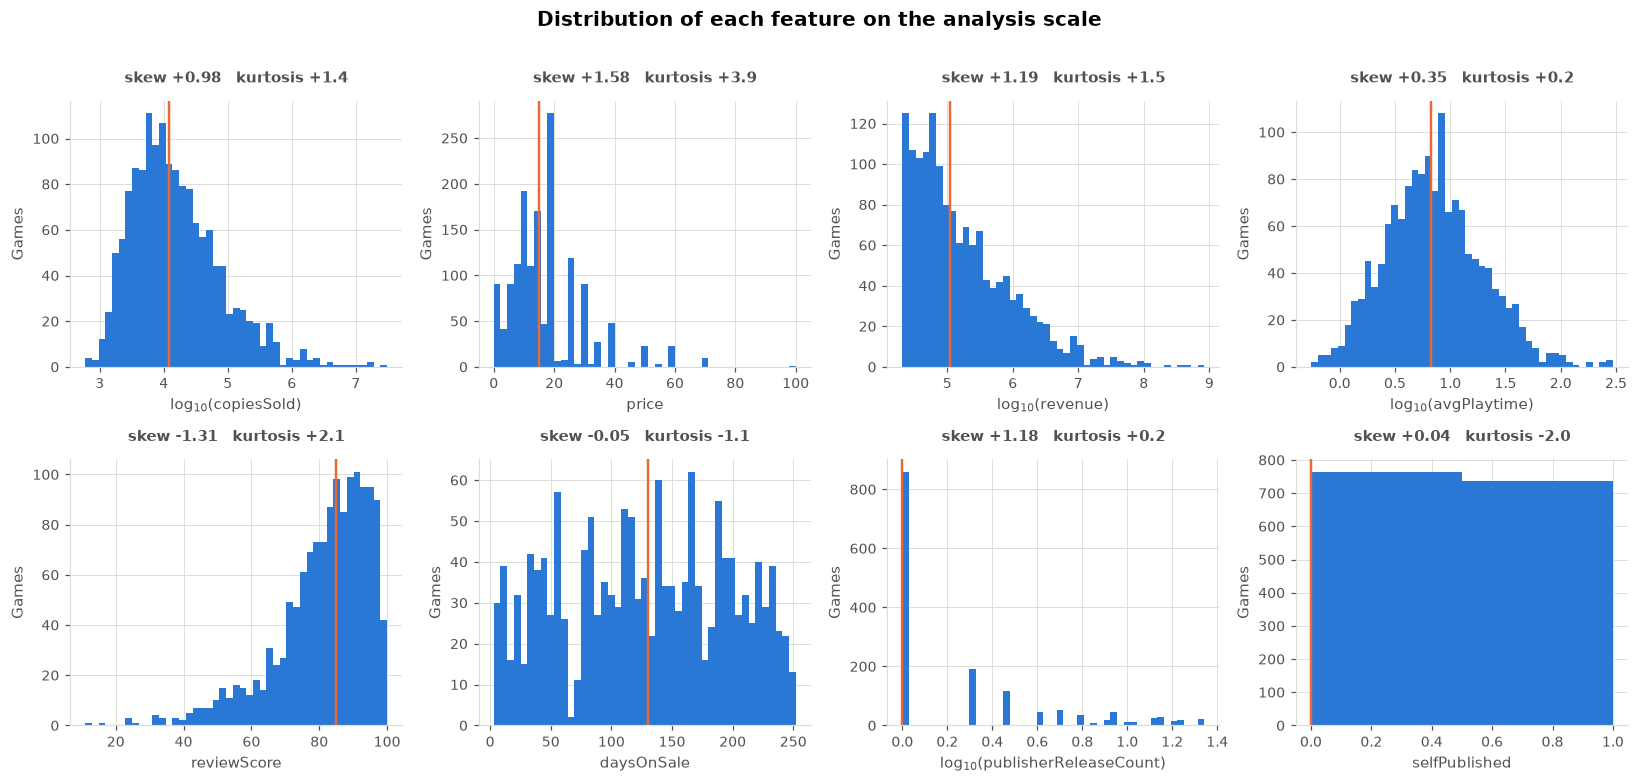

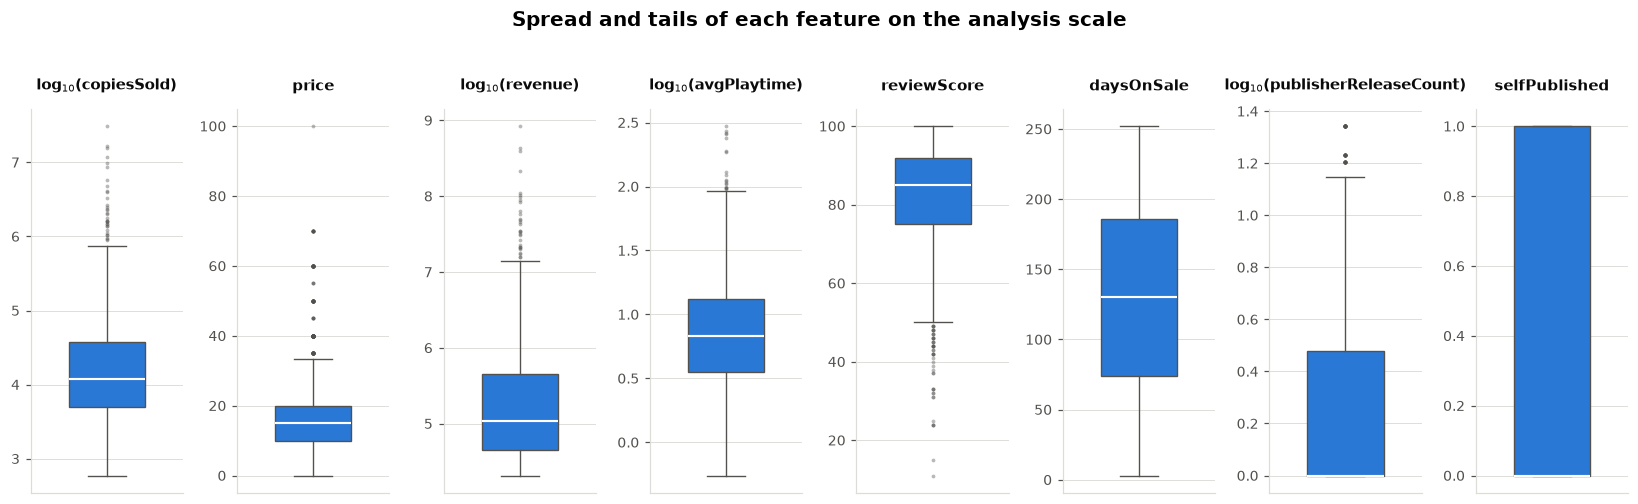

In [10]:
display(plot_distribution_grid(
    log_matrix, LOG_TRANSFORMED_FEATURES,
    "Distribution of each feature on the analysis scale",
))
display(plot_boxplot_grid(
    log_matrix, LOG_TRANSFORMED_FEATURES,
    "Spread and tails of each feature on the analysis scale",
))

**Interpretation of the figures.** Plotted on the scale used for the rest of the
analysis, the shapes become legible and several are informative in their own
right.

`log10(copiesSold)` and `log10(avgPlaytime)` are close to symmetric and unimodal
— a single population rather than distinct groups. `log10(revenue)` retains a
visible right tail even after the transform.

**`price` shows a distinctive comb pattern** rather than a smooth distribution:
tall spikes at a few values with near-empty space between them. This is not
noise. It is psychological pricing, and it means `price` is effectively a
discrete variable with a small number of levels rather than a continuous
measurement. Section 2.4 treats it as a measurement artefact.

`daysOnSale` is visibly flat, confirming the near-uniformity the statistics
indicated, and its box plot has **no points outside the whiskers at all**.

`selfPublished` is a two-bar histogram, which is the honest picture of a binary
feature and a reminder that it does not carry the kind of information the
distance-based methods in later chapters are designed to exploit.

### 2.3 The Preprocessing Decision: Should the Heavy Tails Be Transformed?

**Method.** PCA, K-Means, DBSCAN, hierarchical clustering, LOF and the Z-score
method are all built on variances or distances. A feature with a skewness of 22.9
dominates any such quantity: after standardisation, one observation can sit 30
standard deviations from the mean while 99% of the data occupies a fraction of a
single unit.

The alternative is a base-10 logarithm on the four positively skewed features.
Rather than assume it is an improvement, the decision is made by measuring what
it does to the distributions and to the relationships between them.

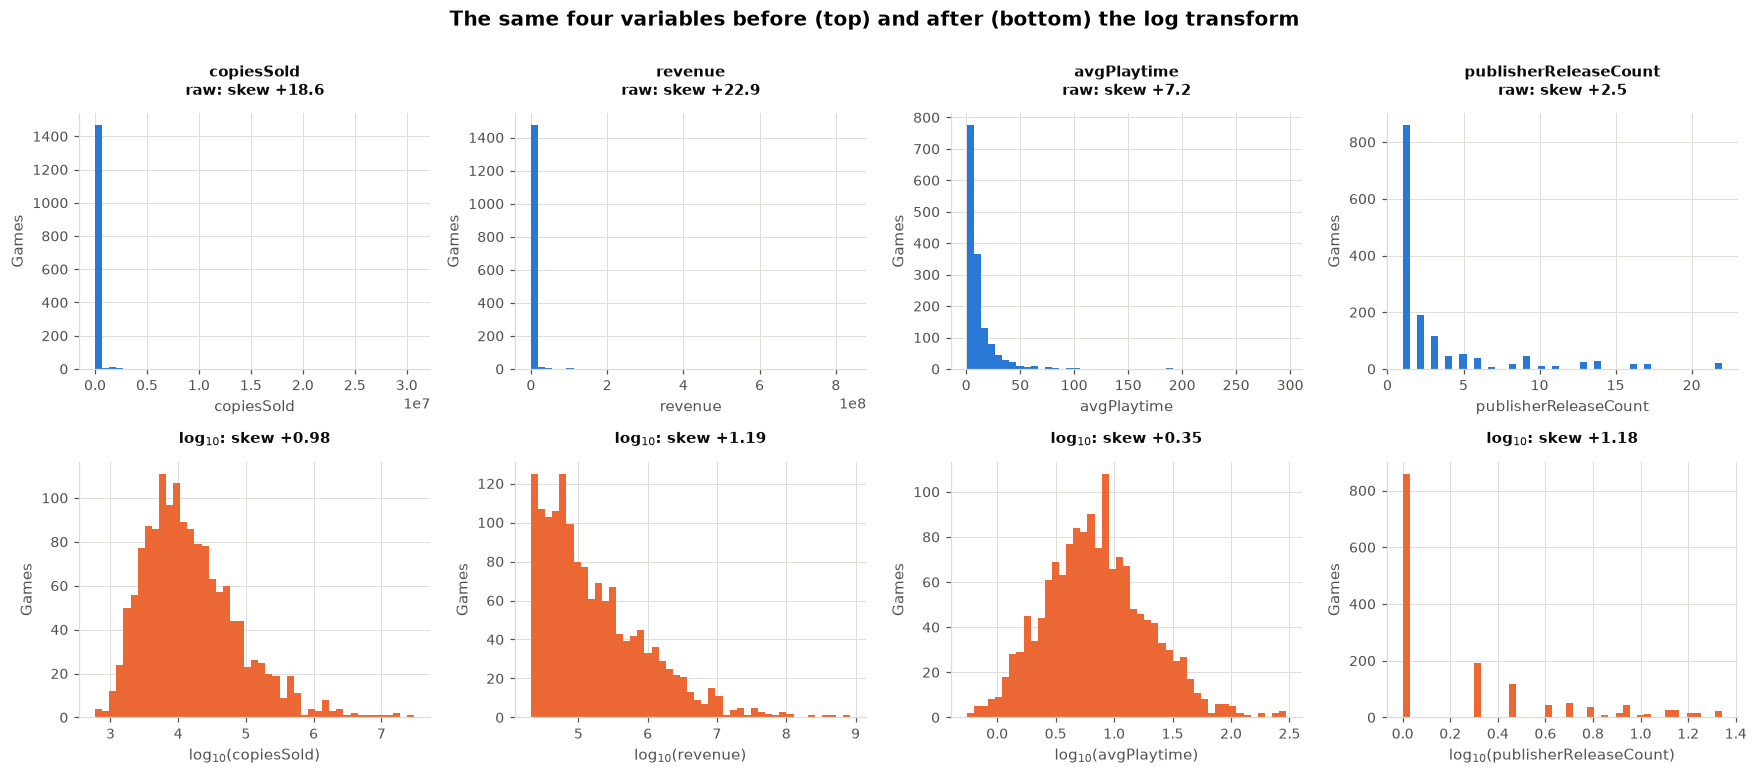

,r (raw),r (log),Change in |r|
Pair,,,
revenue ~ avgPlaytime,0.082,0.453,0.371
copiesSold ~ revenue,0.628,0.897,0.269
copiesSold ~ avgPlaytime,0.099,0.354,0.255
price ~ revenue,0.163,0.398,0.235
price ~ avgPlaytime,0.030,0.255,0.225
publisherReleaseCount ~ selfPublished,-0.426,-0.539,0.113
revenue ~ selfPublished,0.015,-0.120,0.105
price ~ publisherReleaseCount,0.086,0.181,0.095


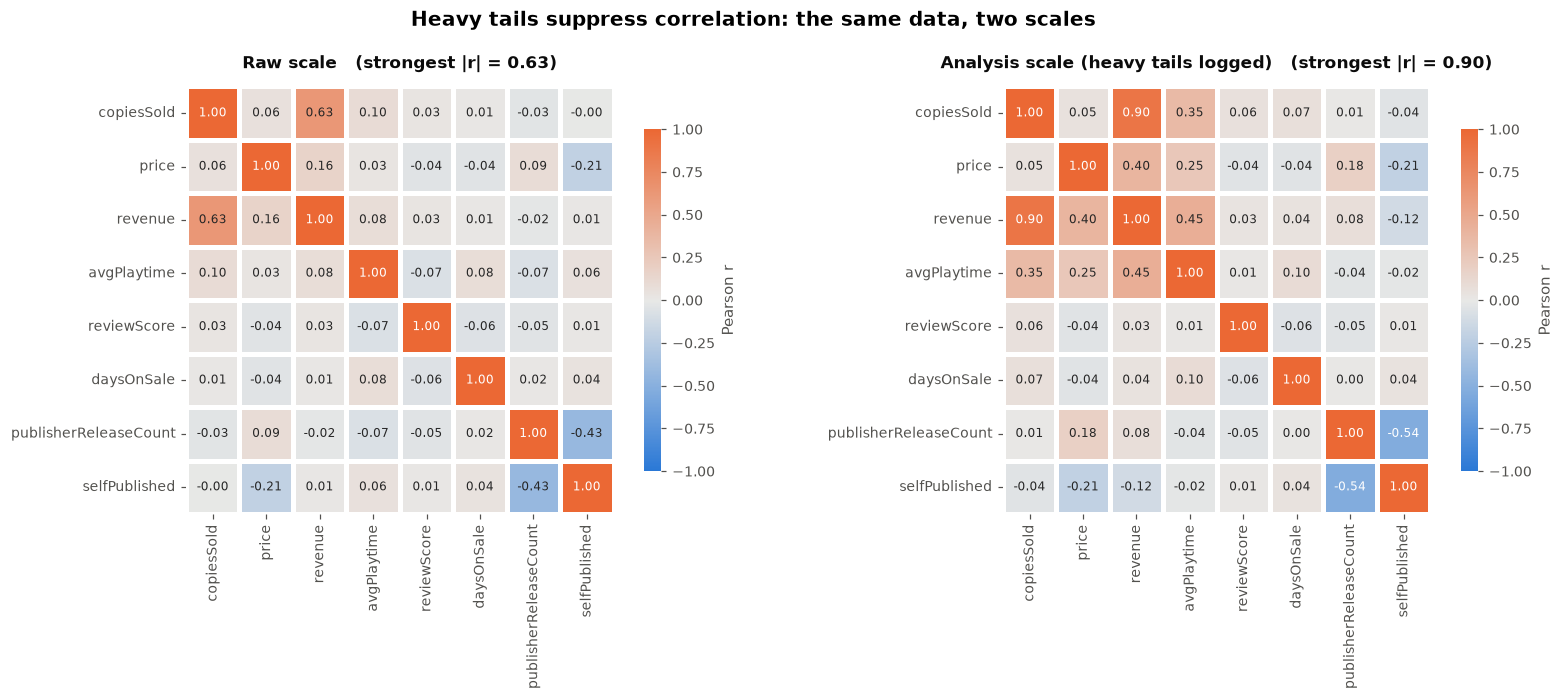

In [11]:
display(plot_transform_effect(raw_matrix, log_matrix, LOG_TRANSFORMED_FEATURES))
display(correlation_shift(raw_matrix, log_matrix).head(8))
display(plot_correlation_pair(raw_matrix, log_matrix))

**Results.** The transform changes both the shapes and the measured
relationships, and the second effect is the more consequential.

| Feature | Skew before → after | Kurtosis before → after |
|---|---|---|
| `revenue` | 22.90 → **1.19** | 607.8 → **1.5** |
| `copiesSold` | 18.60 → **0.98** | 420.0 → **1.4** |
| `avgPlaytime` | 7.16 → **0.35** | 71.5 → **0.2** |
| `publisherReleaseCount` | 2.50 → 1.18 | 6.0 → 0.2 |

**Every pairwise correlation involving a transformed feature becomes stronger,
several of them dramatically:**

| Pair | r (raw) | r (log) | Change |
|---|---|---|---|
| `revenue ~ avgPlaytime` | 0.082 | **0.453** | +0.371 |
| `copiesSold ~ revenue` | 0.628 | **0.897** | +0.269 |
| `copiesSold ~ avgPlaytime` | 0.099 | **0.354** | +0.255 |
| `price ~ revenue` | 0.163 | **0.398** | +0.235 |
| `price ~ avgPlaytime` | 0.030 | **0.255** | +0.225 |

The strongest relationship anywhere in the matrix rises from **0.63 to 0.90**.

**Interpretation.** The raw scale does not merely make the distributions awkward
to plot — **it conceals the structure of the data.** On the raw scale,
`avgPlaytime` and `revenue` correlate at 0.082, a value any analyst would read as
"no relationship". On the log scale the same two variables correlate at 0.453.
Nothing about the data changed; the extreme values were dominating the
covariance, and the relationship among the remaining 99% of games was being
averaged away.

The `copiesSold ~ revenue` pair is the clearest case. Assignment 2 established
that this dataset's vendor computes revenue as approximately copies × price, and
that a regression on the logged variables recovers the identity with coefficients
of 0.988 and 1.005. That relationship is **multiplicative**, so it appears as a
straight line only in log space. On the raw scale it reads as 0.63; on the log
scale, 0.90 — much closer to the near-deterministic link it actually is.

This has a direct consequence for chapter 3. PCA finds directions of maximum
variance in a linear space; if the strongest genuine relationship in the data is
multiplicative, PCA on the raw scale would be looking for the wrong kind of
structure and would spend its first component describing the tail of a single
variable.

**One honest qualification.** The transform is not a universal improvement.
`publisherReleaseCount` is a discrete count with 16 levels and 858 of the 1,500
games sitting at the value 1; taking logarithms reduces its skew from 2.50 to
1.18 but cannot make a spike at a single value into a continuous distribution.
Its histogram remains lumpy, and no transform will change that.

**Conclusion.** The four positively skewed features — `copiesSold`, `revenue`,
`avgPlaytime` and `publisherReleaseCount` — are analysed on a base-10 logarithmic
scale. `price`, `reviewScore`, `daysOnSale` and `selfPublished` are used as they
are: none has a heavy tail, and two are not continuous. Standardisation is
applied on top of this within each method's own pipeline, since PCA and every
distance-based method here would otherwise be dominated by whichever feature
happens to have the largest units.

### 2.4 Outlier Exploration

**Method.** The assignment asks for a discussion of heavy tails, extreme values,
possible noise, measurement artefacts and data-entry problems. These are
different things, and this section keeps them separate: an extreme value is not
necessarily an error, and an error is not necessarily extreme.

Two conventional rules are applied on both scales, not to identify the "real"
outliers but to demonstrate that the count depends on choices the analyst makes.

In [12]:
outlier_counts(raw_matrix, log_matrix)

,"|z| > 3, raw","|z| > 3, analysis scale","1.5xIQR, raw","1.5xIQR, analysis scale"
Feature,,,,
copiesSold,10,17,201,33
price,34,34,140,140
revenue,8,20,223,30
avgPlaytime,24,7,147,17
reviewScore,17,17,48,48
daysOnSale,0,0,0,0
publisherReleaseCount,39,0,199,55
selfPublished,0,0,0,0


**Results.** The number of flagged points depends heavily on both the rule and
the scale.

| Feature | 1.5×IQR raw | 1.5×IQR log | \|z\|>3 raw | \|z\|>3 log |
|---|---|---|---|---|
| `revenue` | 223 | **30** | **8** | **20** |
| `copiesSold` | 201 | 33 | 10 | 17 |
| `avgPlaytime` | 147 | 17 | 24 | 7 |
| `publisherReleaseCount` | 199 | 55 | 39 | **0** |
| `daysOnSale` | 0 | 0 | 0 | 0 |

**Interpretation.** Two findings here are worth more than the counts themselves.

**The IQR rule and the Z-score rule disagree in opposite directions on the same
variable.** For `revenue`, moving to the log scale takes the IQR count *down*
from 223 to 30, while it takes the Z-score count *up* from 8 to 20. The IQR rule
responds to the skew: on the raw scale the quartiles sit close together and the
upper fence falls far below most of the tail, so a seventh of the dataset is
flagged. The Z-score behaves in the opposite way, and the reason is the more
instructive one: **on the raw scale the extreme values inflate the standard
deviation used to judge them.** With a standard deviation of $27.8M, a threshold
of three standard deviations sits at roughly $86M, and only eight games in 1,500
clear it. The outliers hide themselves by making the yardstick enormous. This is
the masking effect, and it is a preview of exactly why chapter 5.1 must treat the
Z-score method's Gaussian assumption sceptically.

**`daysOnSale` has no outliers under any rule on any scale.** Its near-uniform
distribution has nothing that either rule can call extreme. It is a useful
control: it shows that these methods are not flagging points indiscriminately.

**The four categories the assignment asks about, with examples from this
dataset.**

**Heavy tails.** *Black Myth: Wukong* earned $837.8M from 15.5M copies. The next
four largest earn $436M, $392M, $217M and $111M. These are not errors, and they
are not separable from the distribution — they are its tail. Commercial success
in this market is generated multiplicatively, and the resulting distribution has
no natural cut point beyond which a game becomes "too successful to be real".

**Extreme values that are legitimate.** *Firestone: Online Idle RPG* records an
average playtime of **296 hours**, more than 40 times the median of 6.8. Three of
the four highest playtimes belong to free-to-play idle games, a genre designed to
run continuously for months. *The First Descendant* earns **$102M at a listed
price of zero.** Every one of these will be flagged by the methods in chapter 5,
and none is an error. They are a coherent subpopulation — free-to-play
live-service titles — that the feature set describes poorly because `price` says
nothing about how such a game monetises.

**Data-entry problems.** *The Elder Scrolls Online: Gold Road* was recorded with
an average playtime of exactly 0 despite 27,601 owners and $960,791 in revenue.
An MMO expansion cannot have zero average playtime; the value is a placeholder
for a field the source could not populate. The same applies to the 99 games whose
review score was stored as 0: Assignment 1 established that this group **outsells
the scored games**, which a genuine 0% approval rating cannot explain. Both were
converted to missing values in chapter 1. They are the clearest illustration in
this dataset of an error that is not extreme in the ordinary sense — a 0 sits
inside the plausible range of both variables and would pass any range check.

**Measurement artefacts.** `price` takes only **58 distinct values across 1,500
games**, and the six most common cover 54% of the catalogue — $19.99 alone
accounts for 230 games. This is a real property of how games are priced, but for
this analysis it is an artefact: `price` is presented as a continuous variable
and is not one. Distances computed along it are quantised, and any method that
assumes a continuous density will be working against the data. A second and more
serious artefact was established in chapter 1: `revenue` and `copiesSold` are
**model output rather than measurements**, so an extreme value in either may
reflect the estimator's behaviour rather than the game's.

**Possible noise.** With review scores recorded to the nearest percent and
playtimes to fourteen decimal places, the file gives no direct evidence of
measurement noise, and none can be separated from genuine variation without
repeated observations of the same title. What can be said is that the estimation
process is itself a source of uncertainty of unknown size, and chapter 7 returns
to the difficulty of distinguishing that from real variation.

**Conclusion.** The dataset contains a very large number of extreme values, but
few of them are errors. Its two most important variables are heavy-tailed by
nature rather than by contamination, and the log transform adopted in 2.3 makes
them tractable without removing anything. The errors that do exist are
placeholders that sit *inside* the normal range rather than outside it, which is
the harder kind to find. Most importantly for the chapters that follow, the count
of "outliers" in this dataset ranges from 0 to 223 for a single feature depending
on the rule and the scale chosen — **there is no scale-free answer to how many
anomalies this data contains**, which is precisely the ill-posedness the
assignment sets out to examine.

## 3. Dimensionality Reduction (PCA)

**Method — the mathematical intuition.** PCA looks for the directions along which
the data varies most. Given a standardised matrix $X$ with $n$ rows and $p$
features, it computes the covariance matrix $C=\frac{1}{n-1}X^{\top}X$ and takes
its eigendecomposition $C=V\Lambda V^{\top}$. The eigenvectors $v_1,\dots,v_p$
are the principal components — orthogonal directions in feature space — and each
eigenvalue $\lambda_i$ is the variance the data has along its direction. Ordering
by eigenvalue and keeping the leading $k$ gives the $k$-dimensional projection
that preserves more variance than any other, and the share of variance retained
is $\sum_{i\le k}\lambda_i / \sum_i\lambda_i$.

Two properties of that construction matter for reading everything below. PCA is
**linear**: it can only find structure expressible as a rotation of the original
axes. And it is **variance-driven**, so it is a statement about the global spread
of the cloud and says nothing directly about local neighbourhoods or clusters.

**Preprocessing.** The matrix is median-imputed and then standardised. Scaling is
not optional: the eight features are measured in dollars, hours, days, counts and
a binary flag, and PCA maximises variance, so on native units the first component
would simply report which column has the largest numbers. The heavy-tailed
features are on the logarithmic scale decided in section 2.3.

In [13]:
from unsupervised.dimensionality import (
    bootstrap_stability,
    components_needed,
    loading_table,
    neighbourhood_preservation,
    prepare_matrix,
    reconstruction_error,
    timing_table,
    variance_table,
)
from unsupervised.plots import (
    plot_component_stability,
    plot_loadings,
    plot_projection_2d,
    plot_projection_3d,
    plot_reconstruction_error,
    plot_scree,
)
from sklearn.decomposition import PCA

scaled_matrix = prepare_matrix(games, log_transform=True)
scaled_matrix_raw = prepare_matrix(games, log_transform=False)

variance = variance_table(scaled_matrix)
display(variance)
display(components_needed(scaled_matrix))

,Eigenvalue,Explained variance,Cumulative
Component,,,
PC1,2.353,0.2940,0.2940
PC2,1.600,0.1999,0.4938
PC3,1.065,0.1331,0.6269
PC4,0.983,0.1228,0.7497
PC5,0.872,0.1090,0.8586
PC6,0.640,0.0800,0.9386
PC7,0.455,0.0569,0.9955
PC8,0.036,0.0045,1.0000


,Components
Criterion,
80% of variance retained,5
90% of variance retained,6
95% of variance retained,7
Kaiser rule (eigenvalue > 1),3


### 3.1 Explained Variance and How Many Components Are Needed

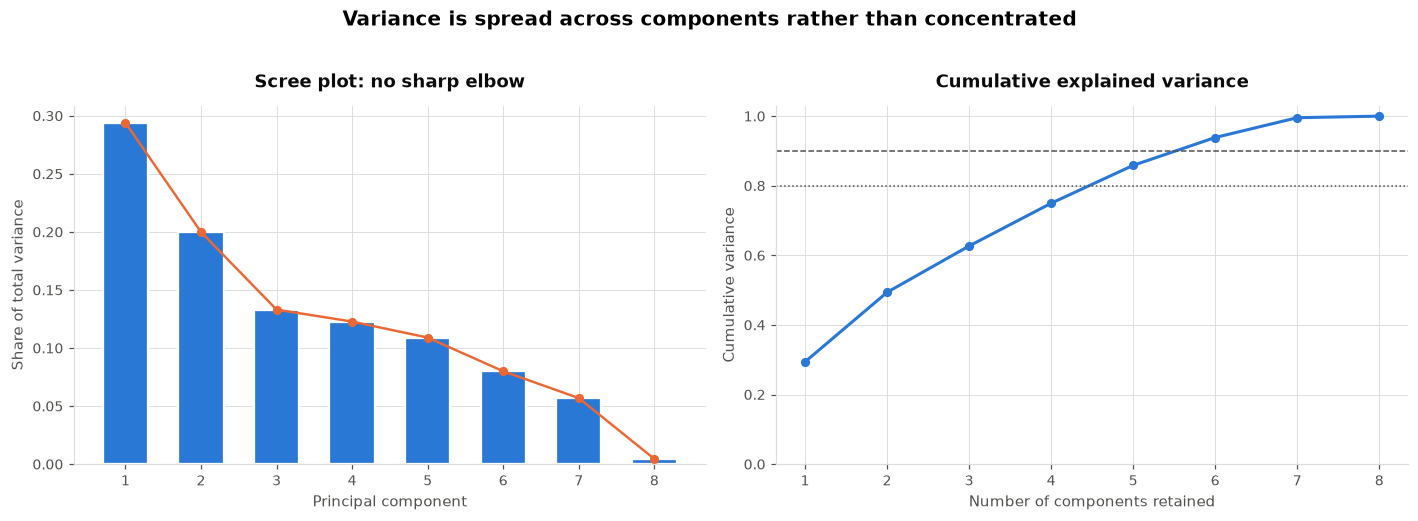

,Analysis scale (logged),Raw scale
Component,,
PC1,0.294,0.211
PC2,0.494,0.402
PC3,0.627,0.544
PC4,0.750,0.666
PC5,0.859,0.779
PC6,0.939,0.886
PC7,0.996,0.955
PC8,1.000,1.000


Components needed for 90% of variance:
  analysis scale : 6
  raw scale      : 7


In [14]:
display(plot_scree(variance))

raw_variance = variance_table(scaled_matrix_raw)
comparison = pd.DataFrame({
    "Analysis scale (logged)": variance["Cumulative"],
    "Raw scale": raw_variance["Cumulative"],
})
display(comparison.round(3))
print("Components needed for 90% of variance:")
print(f"  analysis scale : {int(np.searchsorted(variance['Cumulative'], 0.90) + 1)}")
print(f"  raw scale      : {int(np.searchsorted(raw_variance['Cumulative'], 0.90) + 1)}")

**Results.** The variance is spread across the components rather than
concentrated in a few.

| | PC1 | PC2 | PC3 | PC4 | PC5 | PC6 | PC7 | PC8 |
|---|---|---|---|---|---|---|---|---|
| Explained | 29.4% | 20.0% | 13.3% | 12.3% | 10.9% | 8.0% | 5.7% | 0.5% |
| Cumulative | 29.4% | 49.4% | 62.7% | 75.0% | 85.9% | 93.9% | 99.6% | 100% |

| Criterion | Components |
|---|---|
| 80% of variance | 5 |
| 90% of variance | **6** |
| 95% of variance | 7 |
| Kaiser rule (eigenvalue > 1) | 3 |

**Interpretation — how many components are needed?** The answer depends on the
criterion, and the criteria disagree by a factor of two.

The **Kaiser rule** retains 3 components, keeping every direction that explains
more variance than a single standardised feature would. The **variance-threshold
rule** at the conventional 90% retains **6 of 8**, and even 80% requires 5. The
**scree plot shows no elbow**: the sequence 29.4, 20.0, 13.3, 12.3, 10.9, 8.0 has
no point at which it drops sharply, so the visual criterion gives no clear answer
at all.

**This disagreement is itself the finding.** A dataset with strong redundancy
produces a steep scree curve and all three criteria agree. Here they do not,
because the underlying structure is genuinely spread out: **discarding two of
eight dimensions costs 6% of the variance, and there is no natural point at which
to stop.**

The comparison with the untransformed matrix confirms the section 2.3 decision.
On the raw scale PC1 captures only 21.1% and reaching 90% requires **7**
components; on the analysis scale PC1 captures 29.4% and 90% requires 6. The log
transform makes the data measurably more compressible, because it converts the
multiplicative relationship between revenue and copies into a linear one that
PCA is able to represent.

### 3.2 Component Interpretation and Correlation Structure

,PC1,PC2,PC3,PC4
copiesSold,0.539,-0.238,0.077,0.229
price,0.322,0.254,-0.023,-0.535
revenue,0.617,-0.123,0.058,0.006
avgPlaytime,0.411,-0.170,-0.128,-0.169
reviewScore,0.029,-0.104,0.703,0.475
daysOnSale,0.060,-0.110,-0.689,0.560
publisherReleaseCount,0.139,0.643,-0.037,0.239
selfPublished,-0.178,-0.631,-0.049,-0.191


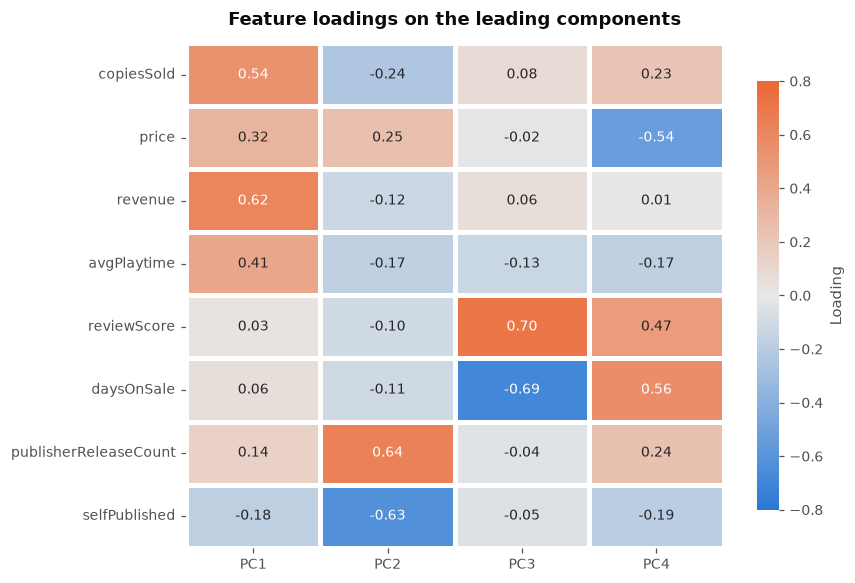

In [15]:
loadings = loading_table(scaled_matrix, n_components=4)
display(loadings)
display(plot_loadings(loadings))

**Results and interpretation — what the components mean.** Three of the four
leading components have a clean reading.

**PC1 (29.4%) is a commercial-scale axis.** Its largest loadings are `revenue`
(0.617), `copiesSold` (0.539), `avgPlaytime` (0.411) and `price` (0.322), all
positive. A game scores high on PC1 by selling more copies, earning more, costing
more and being played longer. Notably `reviewScore` loads 0.029 — essentially
zero — so **critical reception contributes nothing to the dataset's dominant
axis of variation.** That is consistent with Assignment 1, which found review
score uncorrelated with commercial outcome.

**PC2 (20.0%) is a publishing-structure axis.** It contrasts
`publisherReleaseCount` (+0.643) against `selfPublished` (−0.631), with `price`
(+0.254) alongside. High PC2 means a title from a prolific external publisher;
low PC2 means a self-published one. This is close to a pure two-variable
contrast, which is what the correlation of −0.54 between those features implies.

**PC3 (13.3%) pairs reception against recency**, loading `reviewScore` (+0.703)
against `daysOnSale` (−0.689). These are the two features that correlate with
almost nothing else, so PCA places them together in a component of their own —
not because they are related, but because whatever variance remains after PC1 and
PC2 belongs largely to them.

**Which variables are strongly correlated, and how does that affect the result?**
Section 2.3 established the correlation structure: `copiesSold ~ revenue` at
**0.90** is by far the strongest pair, followed by `revenue ~ avgPlaytime` (0.45),
`price ~ revenue` (0.40) and `publisherReleaseCount ~ selfPublished` (−0.54).

The effect on PCA is direct and visible in the loadings. The four mutually
correlated commercial variables collapse into PC1, and the two publishing
variables collapse into PC2. **PCA has not discovered anything the correlation
matrix did not already contain** — it has reorganised it, replacing eight
correlated axes with a smaller number of uncorrelated ones. That is precisely
what the method does, and it is worth stating plainly rather than presenting the
components as a discovery.

The absence of *more* correlation is what limits the compression. With only one
pair above 0.5 in absolute value, most of the eight features carry variance that
no other feature shares, and a method that works by exploiting shared variance
has little to exploit.

### 3.3 Projections into Two and Three Dimensions

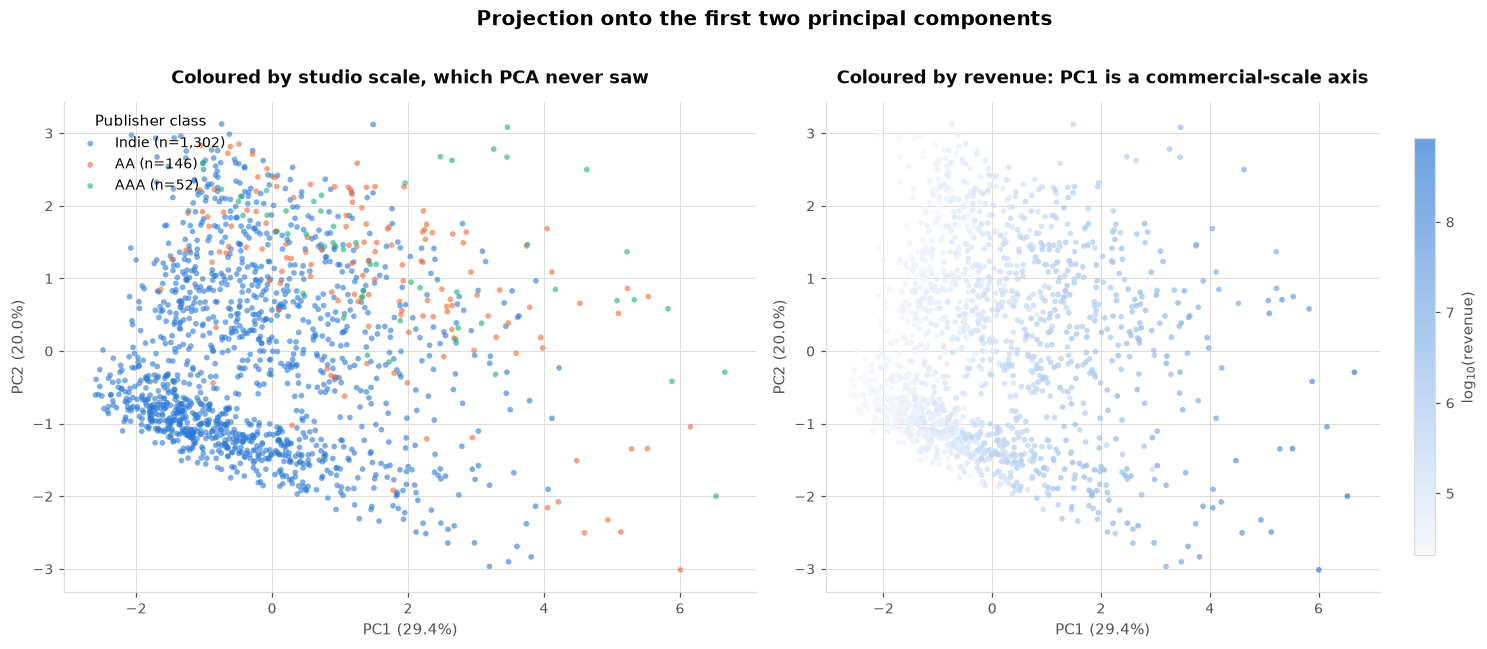

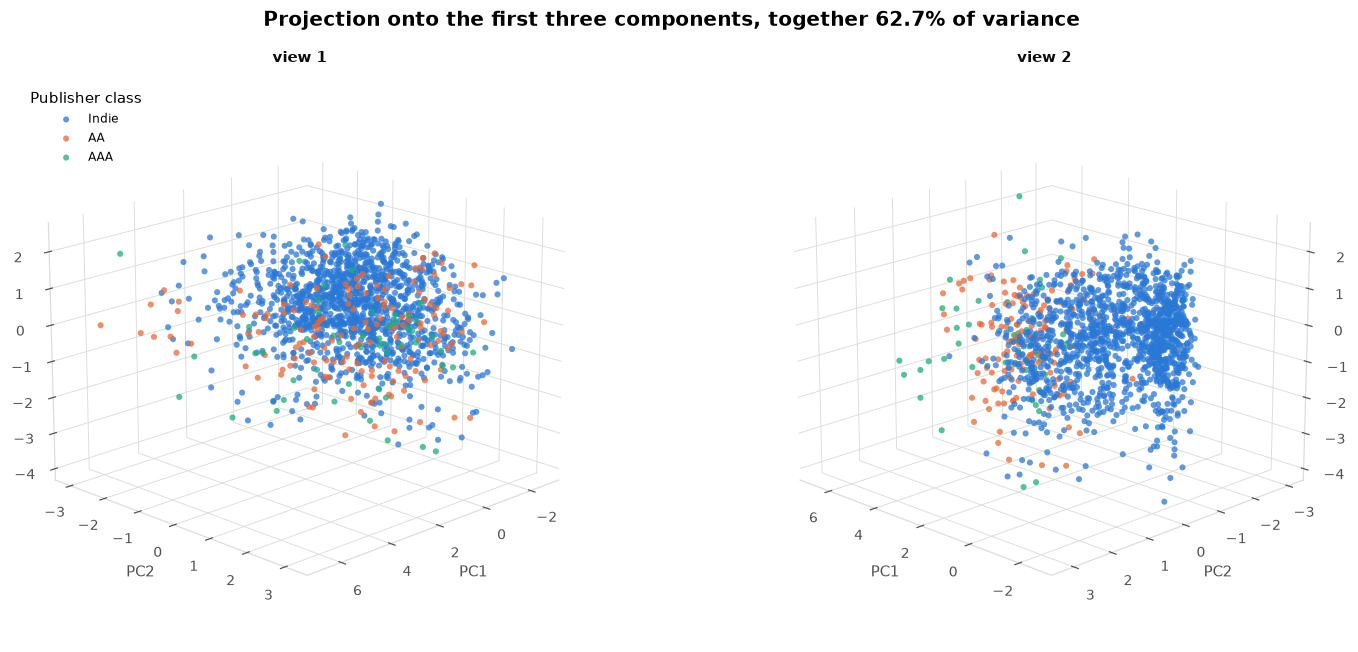

In [16]:
scores = PCA(n_components=3, random_state=42).fit_transform(scaled_matrix)
display(plot_projection_2d(scores, games, variance))
display(plot_projection_3d(scores, games, variance))

**Results and interpretation.** Both projections show **a single diffuse cloud
with no separated groups.** There are no gaps, no distinct lobes and no visible
boundaries — in two dimensions or in three, from either viewing angle.

The annotation confirms that this is not a failure of the projection to represent
something real. Colouring by `plotClass`, a variable PCA never saw, shows AA and
AAA titles drifting towards higher PC1 exactly as the loadings predict, but
**overlapping the Indie population almost completely.** Studio scale shifts a
game's position along PC1; it does not place it in a separate region. Colouring
by revenue shows the same gradient continuously, with no threshold at which the
cloud divides.

**This is a substantive result for chapter 4 and it is reported as such.** The
assignment states explicitly that meaningful clusters may not exist. The leading
two components carry 49.4% of the variance, and within them the data looks like
one population with continuous internal variation rather than several
populations. Any clustering algorithm applied in chapter 4 will still return
clusters, because they are constructed to; the question that chapter has to
answer is whether those partitions correspond to anything, and this projection is
the first evidence that they may not.

**A caution about reading it.** These pictures show 49.4% and 62.7% of the total
variance. The remaining 37–51% lies in directions not displayed, and structure
living there would be invisible here. Section 3.4 measures how much distortion
that involves, and section 7 returns to why post-projection visualisations can
mislead.

### 3.4 How Much Information Is Lost, and What Kind

,Variance kept,copiesSold,price,revenue,avgPlaytime,reviewScore,daysOnSale,publisherReleaseCount,selfPublished
Components,,,,,,,,,
2,49.4%,0.48,0.81,0.28,0.75,0.99,0.99,0.54,0.54
3,62.7%,0.47,0.81,0.28,0.73,0.67,0.68,0.54,0.54
4,75.0%,0.41,0.61,0.28,0.71,0.48,0.40,0.48,0.50
5,85.9%,0.16,0.38,0.23,0.63,0.05,0.17,0.48,0.50
6,93.9%,0.12,0.05,0.14,0.06,0.02,0.05,0.48,0.47


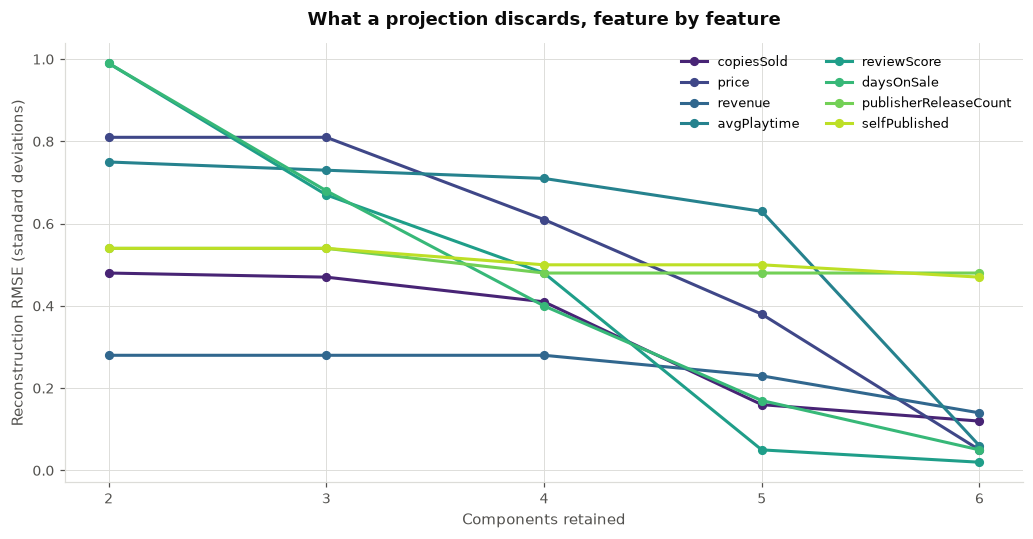

,Trustworthiness (k=15)
Projection,
2D,0.848
3D,0.920
5D,0.983


In [17]:
display(reconstruction_error(scaled_matrix))
display(plot_reconstruction_error(reconstruction_error(scaled_matrix)))
display(neighbourhood_preservation(scaled_matrix))

**Results.** Reporting a single "information lost" percentage would obscure the
more useful fact, which is *which* information is lost. Rebuilding the data from
$k$ components and measuring the per-feature error, in standard deviations,
gives:

| Components | Variance kept | `revenue` | `copiesSold` | `price` | `reviewScore` | `selfPublished` |
|---|---|---|---|---|---|---|
| 2 | 49.4% | **0.28** | 0.48 | 0.81 | 0.99 | 0.54 |
| 3 | 62.7% | 0.28 | 0.47 | 0.81 | 0.67 | 0.54 |
| 5 | 85.9% | 0.23 | 0.16 | 0.38 | 0.05 | 0.50 |
| 6 | 93.9% | 0.14 | 0.12 | 0.05 | 0.02 | **0.47** |

Neighbourhood preservation, measured by trustworthiness at $k=15$:

| Projection | Trustworthiness |
|---|---|
| 2D | **0.848** |
| 3D | 0.920 |
| 5D | 0.983 |

**Interpretation — the loss is uneven, and that matters more than its size.**
A two-component projection reconstructs `revenue` to within 0.28 standard
deviations but leaves `reviewScore` at 0.99 — essentially the whole of its
variance is discarded. In other words, **the 2D picture in section 3.3 contains
almost no information about how well a game was reviewed.** A reader inspecting
that scatter for patterns in reception would find none, and would be right to
find none, but for the wrong reason.

`selfPublished` and `publisherReleaseCount` behave differently again: their error
stays near 0.48 even at six components and 93.9% variance retained. Their shared
variance is captured by PC2, but each also carries independent variance that
survives into the discarded components. A binary feature is intrinsically hard
for a linear projection to represent.

**Local versus global structure.** Explained variance is a global measure — it
says how much of the total spread is preserved, and nothing about whether points
near each other stay near each other. Trustworthiness answers the local question,
and the answer is that **the 2D projection preserves about 85% of local
neighbourhood structure**: roughly one neighbour in seven appearing close in the
picture was not actually close in the eight-dimensional space. Three dimensions
recovers this to 0.92 and five to 0.98.

This gap between global and local fidelity is exactly the mechanism by which a
PCA plot can mislead. Two points can appear adjacent in the projection while
being separated along the discarded directions, and a density-based method such
as DBSCAN or LOF — which depends entirely on local neighbourhoods — would reach
different conclusions in the projected space than in the original one. Every such
method in chapters 4 and 5 is therefore run on the **full eight-dimensional
matrix**, with PCA used only to display the results.

### 3.5 Stability and Computational Cost

,Mean |cosine|,5th percentile,Resamples below 0.9
Component,,,
PC1,0.996,0.991,0
PC2,0.993,0.983,0
PC3,0.891,0.500,54


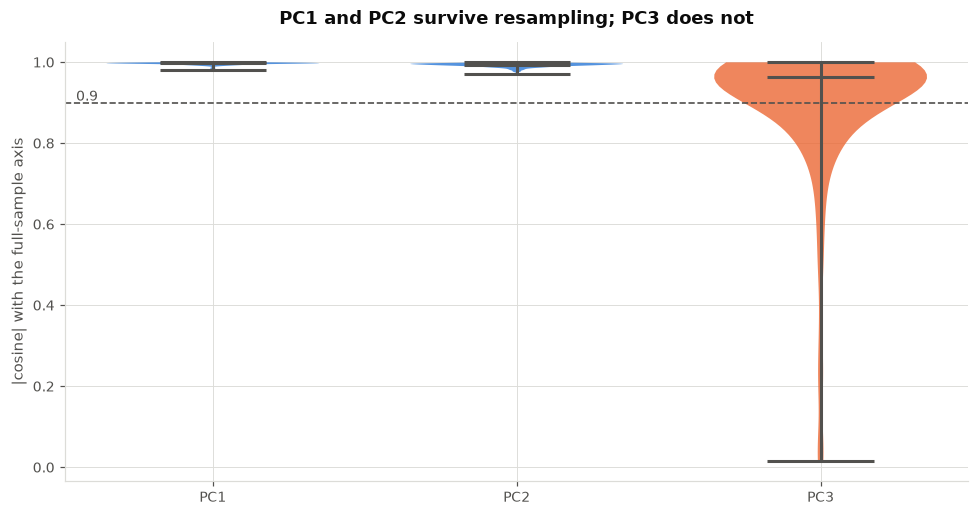

,Seconds for 20 fits
Components,
2,0.0030
3,0.0024
8,0.0024


In [18]:
stability, similarity_samples = bootstrap_stability(scaled_matrix, n_components=3, n_resamples=200)
display(stability)
display(plot_component_stability(similarity_samples))
display(timing_table(scaled_matrix))

**Results.** Refitting PCA on 200 bootstrap resamples and comparing each axis
with the full-sample axis by absolute cosine similarity:

| Component | Mean \|cosine\| | 5th percentile | Resamples below 0.9 |
|---|---|---|---|
| PC1 | 0.996 | 0.991 | 0 |
| PC2 | 0.993 | 0.983 | 0 |
| **PC3** | **0.891** | **0.500** | **54 of 200** |

**Interpretation.** PC1 and PC2 are highly stable: no resample moved either axis
appreciably, so the commercial-scale and publishing-structure interpretations in
3.2 are properties of the data rather than of this particular sample.

**PC3 is not stable.** In 54 of 200 resamples it rotated far enough that its
cosine with the full-sample axis fell below 0.9, and at the 5th percentile it
reached 0.500 — a rotation of about 60 degrees. The cause is visible in the
eigenvalues: PC3 explains 13.3% and PC4 explains 12.3%, a difference of one
percentage point. When two eigenvalues are close, the *plane* they span is well
determined but the individual axes within that plane are nearly free to rotate,
and resampling is enough to spin them.

The consequence is a limit on interpretation. The "reception versus recency"
reading of PC3 in section 3.2 describes this sample; a different sample of 1,500
games would likely produce a differently-oriented third axis spanning the same
subspace. **PC1 and PC2 may be interpreted; PC3 should not be, beyond noting
which variables occupy that subspace.**

**Computational cost.** Twenty full fits take under 0.01 seconds regardless of
the number of components requested. At $n=1{,}500$ and $p=8$ the eigendecomposition
is trivial, and cost plays no part in the choice of method here. This would not
remain true at large $p$: exact PCA costs $O(np^2 + p^3)$, so it is the number of
*features*, not rows, that eventually becomes limiting — which is worth noting
because the anomaly-detection methods in chapter 5 scale quite differently.

### 3.6 Does the Reduced Representation Improve on the Original?

**Interpretation.** Taking the assignment's question directly: **for this dataset,
only marginally, and the honest answer is that PCA offers limited compression
here.**

The evidence is consistent across the chapter. Retaining 90% of the variance
requires 6 of 8 components — a reduction of 25% in dimensionality. The scree plot
has no elbow. Reconstruction error at two components leaves several features
essentially unrepresented. The correlation matrix contains exactly one pair above
0.5 in absolute value.

**The level of redundancy in the original data is low.** This is not a defect of
the analysis; it is a property of the feature set, and it was partly designed in.
Chapter 1 deliberately excluded the candidate features that were algebraic
functions of others — `revenuePerCopy`, `revenuePerDay`, `priceRealisation`, and
`releaseMonth` at −0.99 with `daysOnSale`. Had those been retained, PCA would have
produced an impressive-looking scree plot and a high first-component share, and
**all of it would have been an artefact of the feature set rather than a finding
about games.** The modest compression reported here is the price of not having
manufactured redundancy, and it is the more honest result.

**Where PCA is nonetheless useful in this analysis.** Not as a compression step,
but as an instrument. It provides a coordinate system for displaying the results
of chapters 4 and 5; it supplies, through the loadings, a compact summary of the
correlation structure; and section 3.4's trustworthiness measurement quantifies
how much a two-dimensional picture can be trusted — which is needed to interpret
every projection that follows.

**Interpretability.** The components are interpretable to the extent that their
loadings are concentrated, and here PC1 and PC2 are. But every component is a
weighted mixture of all eight features, so a position on PC1 has no unit and
cannot be quoted to a non-technical audience without translation. The original
features are individually meaningful — dollars, hours, a count — and the
components are not. That trade is worth making for visualisation and not worth
making for the analysis itself.

**Conclusion.** The dataset's variance is spread rather than concentrated: 6 of 8
components are needed for 90%, the scree plot has no elbow, and the three
conventional criteria disagree between 3 and 7 components. PC1 is a
commercial-scale axis and PC2 a publishing-structure axis, both stable under
resampling; PC3 is not stable and should not be interpreted. The projections show
one diffuse cloud with no separated groups, which is the first evidence that this
dataset may not contain distinct clusters. Because the 2D projection preserves
only 85% of local neighbourhood structure, every distance-based method in the
following chapters operates on the full eight-dimensional matrix, and PCA is used
for display only.

## 4. Clustering Analysis

**Method.** Three methods are applied to the samples — K-Means, DBSCAN and Ward
hierarchical clustering — and a fourth analysis clusters the feature space by
operating on the transpose of the data matrix. All four run on the full
eight-dimensional standardised matrix, for the reason established in section
3.4: the 2D projection preserves only 85% of local neighbourhood structure, and
density-based methods depend entirely on local neighbourhoods.

Every parameter is swept rather than assumed. This matters more than usual here.
Section 3.3 found one diffuse cloud with no visible separation, so there is a
real risk of choosing the parameters that produce the most attractive partition
and then reporting it as a discovery. **Clustering algorithms always return
clusters — they are constructed to.** The question this chapter must answer is
whether those partitions correspond to anything in the data.

,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,Smallest cluster
k,,,,,
2,9659.0,0.214,363.0,1.855,470
3,8174.0,0.196,350.3,1.722,313
4,7567.0,0.171,292.1,1.827,261
5,7030.0,0.171,264.2,1.699,146
6,6543.0,0.170,249.2,1.694,129
7,6142.0,0.161,237.4,1.708,120
8,5806.0,0.168,227.4,1.649,78
9,5525.0,0.165,218.4,1.578,73
10,5300.0,0.162,209.3,1.575,66


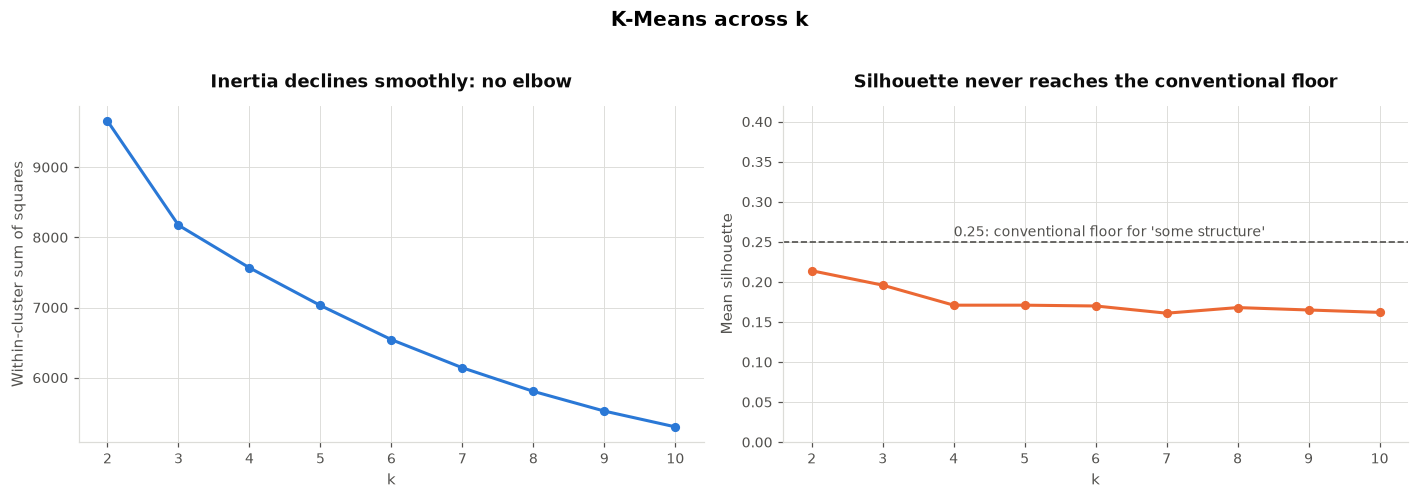

In [19]:
from scipy.cluster.hierarchy import linkage
from sklearn.cluster import KMeans

from unsupervised.clustering import (
    DBSCAN_EPS,
    DBSCAN_MIN_SAMPLES,
    HIERARCHICAL_K,
    KMEANS_K,
    agreement_matrix,
    cluster_features,
    compare_linkages,
    evaluate_partitions,
    feature_distance_matrix,
    feature_isolation,
    fit_all,
    k_distance_curve,
    profile_clusters,
    sweep_dbscan,
    sweep_kmeans,
    variance_ratio,
)
from unsupervised.plots import (
    plot_clusters_on_pca,
    plot_dendrogram,
    plot_feature_space,
    plot_k_distance,
    plot_kmeans_sweep,
    plot_metric_disagreement,
)

kmeans_sweep = sweep_kmeans(scaled_matrix)
display(kmeans_sweep)
display(plot_kmeans_sweep(kmeans_sweep))

### 4.1 K-Means

**Mathematical intuition.** K-Means partitions the points into $k$ groups by
minimising the within-cluster sum of squared distances to the cluster centres:

$$\arg\min_{S}\sum_{i=1}^{k}\sum_{x\in S_i}\lVert x-\mu_i\rVert^2$$

where $\mu_i$ is the mean of cluster $S_i$. Lloyd's algorithm alternates between
assigning each point to its nearest centre and recomputing the centres, which
decreases the objective at every step and converges to a local minimum.

**Assumptions.** That clusters are roughly spherical and of comparable spread,
since the objective is isotropic squared Euclidean distance; that they are of
broadly similar size, because the mean is pulled towards dense regions; and that
$k$ is known. It also assumes every point belongs to a cluster — there is no
provision for noise.

**Strengths.** Fast, deterministic given a seed, and its output is easy to
describe: each cluster has a centre that can be read as a profile.
**Weaknesses.** It cannot represent elongated or nested shapes, it is sensitive
to initialisation, and — most importantly here — **it will partition data that
has no natural partition**, because the objective always decreases as $k$ grows.

**Results.** Silhouette peaks at $k=2$ with **0.214** and declines thereafter;
$k=3$ gives 0.196. Inertia falls smoothly from 9,659 to 5,300 across $k=2$ to
$k=10$ with **no elbow** at any point. Calinski-Harabasz is highest at $k=2$
(363.0) and declines monotonically. Davies-Bouldin never falls below 1.575.

**Interpretation.** A silhouette of 0.21 is weak. The conventional reading is
that values below roughly 0.25 indicate no substantial structure, and every value
across the entire sweep sits below that line. The smooth inertia curve says the
same thing differently: an elbow appears when adding a cluster stops paying,
which happens when the data contains a fixed number of real groups. Here each
additional cluster pays about as much as the last, which is what happens when an
algorithm is slicing a continuum.

$k=3$ is carried forward — not because the evidence favours it, but because it
gives a partition to compare against the other two methods. Section 4.4 returns
to whether any of these partitions is meaningful.

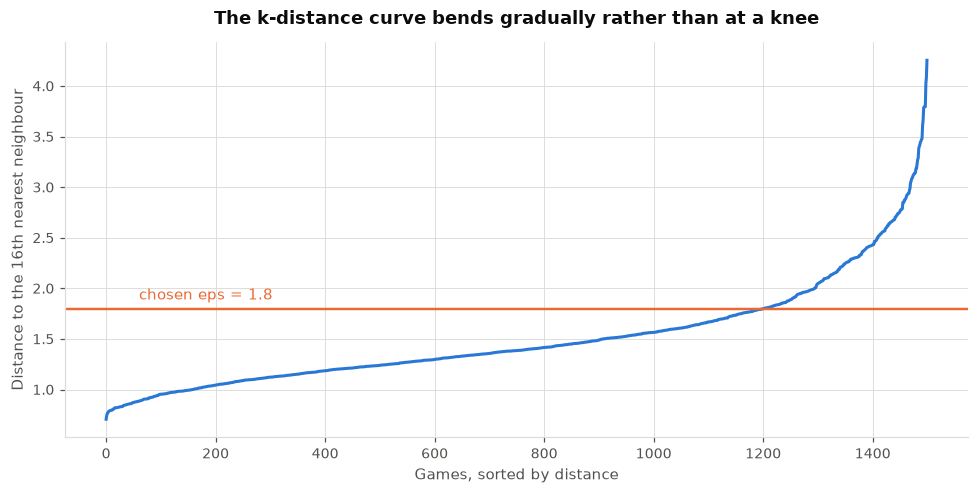

,eps,min_samples,Clusters,Noise %,Largest cluster %,Silhouette (excl. noise)
0,1.5,8,2,11.5%,44.6%,0.216
1,1.5,16,2,16.9%,42.7%,0.227
2,1.5,24,2,21.0%,41.3%,0.233
3,1.8,8,2,5.7%,47.5%,0.202
4,1.8,16,2,7.7%,46.3%,0.207
5,1.8,24,2,9.3%,45.5%,0.212
6,2.0,8,2,3.4%,48.9%,0.196
7,2.0,16,2,4.5%,48.2%,0.199
8,2.0,24,2,5.8%,47.6%,0.203
9,2.2,8,1,1.6%,98.4%,NaN


In [20]:
display(plot_k_distance(k_distance_curve(scaled_matrix), DBSCAN_EPS, DBSCAN_MIN_SAMPLES))
display(sweep_dbscan(scaled_matrix))

### 4.2 DBSCAN

**Mathematical intuition.** DBSCAN defines clusters as regions of high density
rather than as groups around centres. A point is a *core point* if at least
`min_samples` points lie within distance `eps` of it. Core points that are within
`eps` of each other are joined into the same cluster, non-core points within
reach of a core point are attached as border points, and everything else is
labelled **noise**. No number of clusters is specified in advance; it emerges
from the density structure.

**Assumptions.** That clusters are dense regions separated by sparser ones, and
that a single density threshold applies everywhere. It makes no assumption about
shape, which is its main advantage over K-Means.

**Strengths.** Finds arbitrarily shaped clusters, discovers the number of
clusters itself, and explicitly models noise — which is why it is often used for
anomaly detection. **Weaknesses.** It is very sensitive to `eps`, it cannot
handle clusters of differing density with one threshold, and in higher dimensions
distances concentrate so that a single `eps` separating dense from sparse becomes
harder to find.

**Choosing `eps`.** The conventional heuristic reads it off the knee of the
sorted k-distance curve. Here **the curve bends gradually rather than at a knee**
— the 50th, 75th, 90th and 95th percentiles of the 16th-neighbour distance are
1.38, 1.70, 2.24 and 2.59 — so no value is clearly indicated, which is itself
consistent with the absence of a density gap. A value of 1.8 was chosen from the
sweep as the setting that produces more than one cluster without labelling an
implausible share of the data as noise.

**Results.** The sweep divides sharply at `eps ≈ 2.1`. Below it DBSCAN returns
exactly **2** clusters. Above it the entire dataset collapses into **1 cluster
containing 96–99% of the points**. No parameter combination produced three or
more clusters.

**Interpretation — and an unexpected finding examined below.** The collapse at
`eps ≥ 2.2` is the important result: at that radius every point is
density-reachable from every other, meaning **the data forms one connected
region with no density gap running through it.** That is direct evidence against
the existence of separated clusters, obtained from a method that would have found
them had they been there.

In [21]:
dbscan_labels = fit_all(scaled_matrix)[f"DBSCAN (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})"]
kmeans_two = KMeans(n_clusters=2, n_init=20, random_state=42).fit_predict(scaled_matrix)

check = pd.DataFrame({
    "Games": pd.Series(dbscan_labels).value_counts().sort_index(),
    "selfPublished share": games.assign(c=dbscan_labels).groupby("c")["selfPublished"].mean().round(3),
    "Median revenue": games.assign(c=dbscan_labels).groupby("c")["revenue"].median().round(0),
})
check.index = ["noise" if i == -1 else f"cluster {i}" for i in check.index]
display(check)

from sklearn.metrics import adjusted_rand_score
print(f"ARI between the DBSCAN partition and K-Means at k=2: "
      f"{adjusted_rand_score(dbscan_labels, kmeans_two):.3f}")

,Games,selfPublished share,Median revenue
noise,115,0.4,1902618.0
cluster 0,690,1.0,73644.0
cluster 1,695,0.0,125882.0


ARI between the DBSCAN partition and K-Means at k=2: 0.087


**What DBSCAN actually found.** The two clusters are **a perfect split on
`selfPublished`**: cluster 0 is 100% self-published and cluster 1 is 0%. DBSCAN
did not find two populations of games — it found the two parallel slabs that a
standardised binary feature creates in Euclidean space. With seven continuous
features and one binary, the point cloud sits in two copies of the same shape
offset along a single axis, and the gap between them is wide enough at
`eps ≤ 2.0` to prevent density connection.

The agreement with K-Means at $k=2$ is **ARI 0.087** — essentially chance. The
two methods, given the same data and the same number of clusters, found
completely different things: K-Means cut along the commercial-scale axis while
DBSCAN cut along the binary flag.

This is the concrete form of the caution recorded in chapter 1.3. `selfPublished`
is a legitimate feature, but it carries full weight in Euclidean distance after
standardisation, and here it dominates a density-based method entirely. **This is
a property of the feature-space representation, not of any tuning parameter**,
and it would not have been visible from the parameter sweeps alone.

,Cophenetic r,Silhouette at k=3,Cluster sizes
Linkage,,,
ward,0.487,0.158,"[420, 561, 519]"
complete,0.524,0.141,"[36, 405, 1059]"
average,0.679,0.263,"[4, 104, 1392]"
single,0.526,0.337,"[1498, 1, 1]"


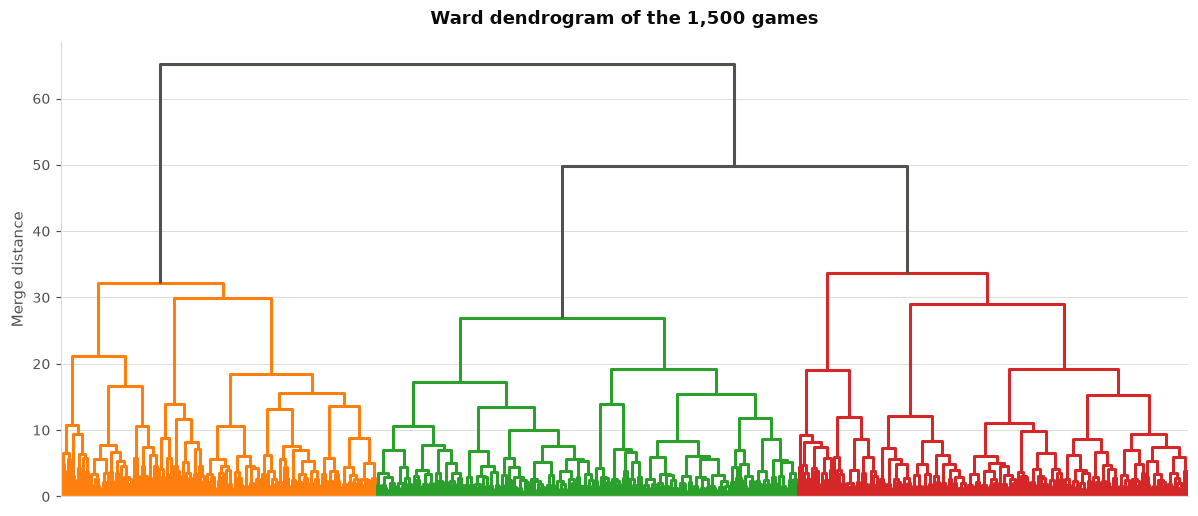

In [22]:
display(compare_linkages(scaled_matrix, k=HIERARCHICAL_K))
display(plot_dendrogram(linkage(scaled_matrix, method="ward"),
                        title="Ward dendrogram of the 1,500 games",
                        colour_threshold=40))

### 4.3 Hierarchical Clustering

**Mathematical intuition.** Agglomerative clustering begins with every point in
its own cluster and repeatedly merges the two closest clusters, producing a tree.
The linkage rule defines "closest": *single* uses the minimum distance between
members, *complete* the maximum, *average* the mean, and *Ward* merges the pair
that produces the smallest increase in total within-cluster variance,

$$\Delta = \frac{n_i n_j}{n_i+n_j}\lVert \mu_i-\mu_j\rVert^2 .$$

Cutting the tree at a chosen height yields a partition.

**Assumptions.** No assumption about shape or the number of clusters, but the
linkage rule imposes one implicitly: Ward assumes compact, variance-minimising
groups and behaves much like K-Means, while single linkage assumes only
connectivity and can produce long chains.

**Strengths.** The dendrogram shows structure at every scale at once, and no $k$
need be fixed in advance. **Weaknesses.** Merges are greedy and irreversible, the
cost is $O(n^2)$ in memory, and different linkages can give entirely different
answers on the same data — as they do here.

**Results.** The four linkage rules disagree substantially:

| Linkage | Cophenetic r | Silhouette at k=3 | Cluster sizes |
|---|---|---|---|
| Ward | 0.487 | 0.158 | 420, 561, 519 |
| Complete | 0.524 | 0.141 | 36, 405, 1059 |
| Average | 0.679 | 0.263 | 4, 104, 1392 |
| **Single** | 0.526 | **0.337** | **1498, 1, 1** |

**Interpretation.** The cophenetic correlation measures how faithfully the tree's
implied distances reproduce the real pairwise distances. The best value here is
**0.679** and Ward's is **0.487** — all low. **The dendrogram is imposing a
hierarchy that the data does not have.**

The single-linkage row is worth dwelling on because it is a trap. It achieves the
**highest silhouette of any method in this chapter, 0.337** — and it does so by
placing 1,498 games in one cluster and isolating two singletons. A singleton has
a perfect silhouette by construction, and with 1,498 points in one group the mean
is dominated by whatever that group scores. **A metric can be optimised by a
partition that is analytically worthless**, which is the practical reason
section 4.4 does not rely on any single number.

Ward at $k=3$ is carried forward: it is the only rule producing balanced clusters,
and balance is the minimum condition for a partition to be worth interpreting.

### 4.4 Evaluation: Is the Named Metric Suitable?

**Method.** The assignment specifies a particular metric — the average variance
within each cluster compared with the global variance — and asks whether it is
suitable, requesting an alternative if not. It is computed below for every
partition, alongside three standard alternatives and two deliberate controls: a
random labelling, and K-Means at a deliberately excessive $k$.

,Clusters,Variance ratio,Silhouette,Calinski-Harabasz,Davies-Bouldin
Partition,,,,,
K-Means (k=3),3,0.731,0.196,350.3,1.722
"DBSCAN (eps=1.8, min_samples=16)",2,0.798,0.207,349.5,1.896
Ward hierarchical (k=3),3,0.745,0.158,291.7,1.912


,Clusters,Variance ratio,Silhouette,Calinski-Harabasz,Davies-Bouldin
Partition,,,,,
K-Means (k=2),2,0.854,0.214,363.0,1.855
"K-Means (k=8, deliberately over-split)",8,0.554,0.168,227.4,1.649
Random labels (k=3),3,0.998,-0.006,1.2,35.538


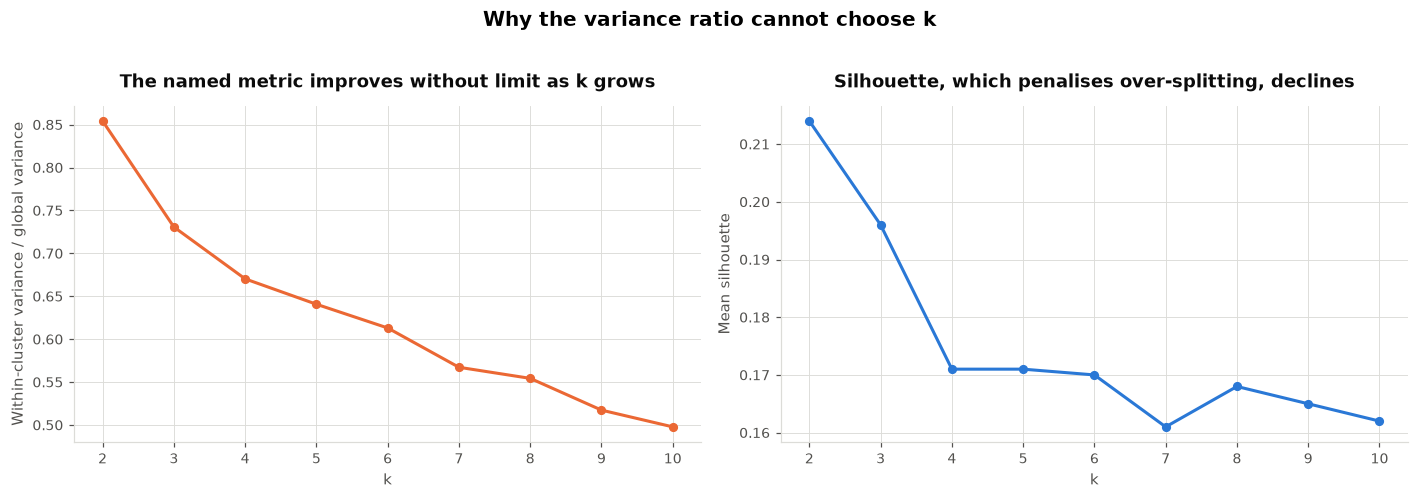

In [23]:
labellings = fit_all(scaled_matrix)
display(evaluate_partitions(scaled_matrix, labellings))

controls = {
    "K-Means (k=2)": kmeans_two,
    "K-Means (k=8, deliberately over-split)": KMeans(n_clusters=8, n_init=20, random_state=42).fit_predict(scaled_matrix),
    "Random labels (k=3)": np.random.default_rng(0).integers(0, 3, len(scaled_matrix)),
}
display(evaluate_partitions(scaled_matrix, controls))

ratio_by_k = pd.Series(
    {k: variance_ratio(scaled_matrix, KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(scaled_matrix))
     for k in range(2, 11)}
)
display(plot_metric_disagreement(kmeans_sweep, ratio_by_k))

**Results.**

| Partition | Variance ratio | Silhouette | Calinski-Harabasz | Davies-Bouldin |
|---|---|---|---|---|
| K-Means (k=3) | 0.731 | 0.196 | 350.3 | 1.722 |
| DBSCAN | 0.798 | 0.207 | 349.5 | 1.896 |
| Ward (k=3) | 0.745 | 0.158 | 291.7 | 1.912 |
| K-Means (k=2) | 0.854 | 0.214 | 363.0 | 1.855 |
| **K-Means (k=8)** | **0.554** | 0.168 | 227.4 | 1.649 |
| Random labels (k=3) | 0.998 | −0.006 | — | — |

**Interpretation — the metric is not suitable, and the table shows why.**

It does one thing correctly: random labels score **0.998**, essentially the
global variance, so the metric does detect that a meaningless partition is
meaningless. That is its floor, and it works.

But it **cannot compare partitions with different numbers of clusters**, which is
the main thing one wants a clustering metric to do. The ratio falls monotonically
as $k$ rises — 0.854 at $k=2$, 0.731 at $k=3$, 0.554 at $k=8$ — while silhouette
*declines* over the same range from 0.214 to 0.168. Taken at face value the
metric prefers $k=8$ to $k=2$, and it would prefer $k=100$ to $k=8$. In the limit
where every point is its own cluster the within-cluster variance is zero and the
ratio is perfect.

The reason is structural: **the metric is almost exactly what K-Means minimises.**
Total variance decomposes as within-cluster plus between-cluster variance, so
minimising the first is maximising the second, which is the K-Means objective.
Using it to evaluate clustering is therefore circular for K-Means, and it
structurally disadvantages DBSCAN, whose highest silhouette (0.207) comes with
the *worst* variance ratio (0.798) because DBSCAN is not trying to minimise that
quantity at all. It also has no natural definition for DBSCAN's noise label,
which must be excluded by hand.

**The alternative proposed is the silhouette coefficient.** For point $i$ with
mean distance $a(i)$ to its own cluster and $b(i)$ to the nearest other cluster,

$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}\in[-1,1].$$

It compares cohesion against separation, so splitting a homogeneous group in two
lowers it rather than raising it — it penalises over-splitting where the variance
ratio rewards it. It is defined per point, is comparable across different $k$ and
across methods with different objectives, and needs no assumption that clusters
are variance-minimising.

Its limitation must be stated too, and section 4.3 demonstrated it: silhouette
can be gamed by degenerate partitions, since the single-linkage split scored
0.337 with two singleton clusters. **No single internal metric is sufficient.**
This chapter therefore reports silhouette as the primary criterion, alongside
Calinski-Harabasz and Davies-Bouldin, cluster sizes, and the agreement between
methods — because a partition that only one algorithm can find is weak evidence
that it exists.

,K-Means (k=3),"DBSCAN (eps=1.8, min_samples=16)",Ward hierarchical (k=3)
K-Means (k=3),1.000,0.655,0.650
"DBSCAN (eps=1.8, min_samples=16)",0.655,1.000,0.481
Ward hierarchical (k=3),0.650,0.481,1.000


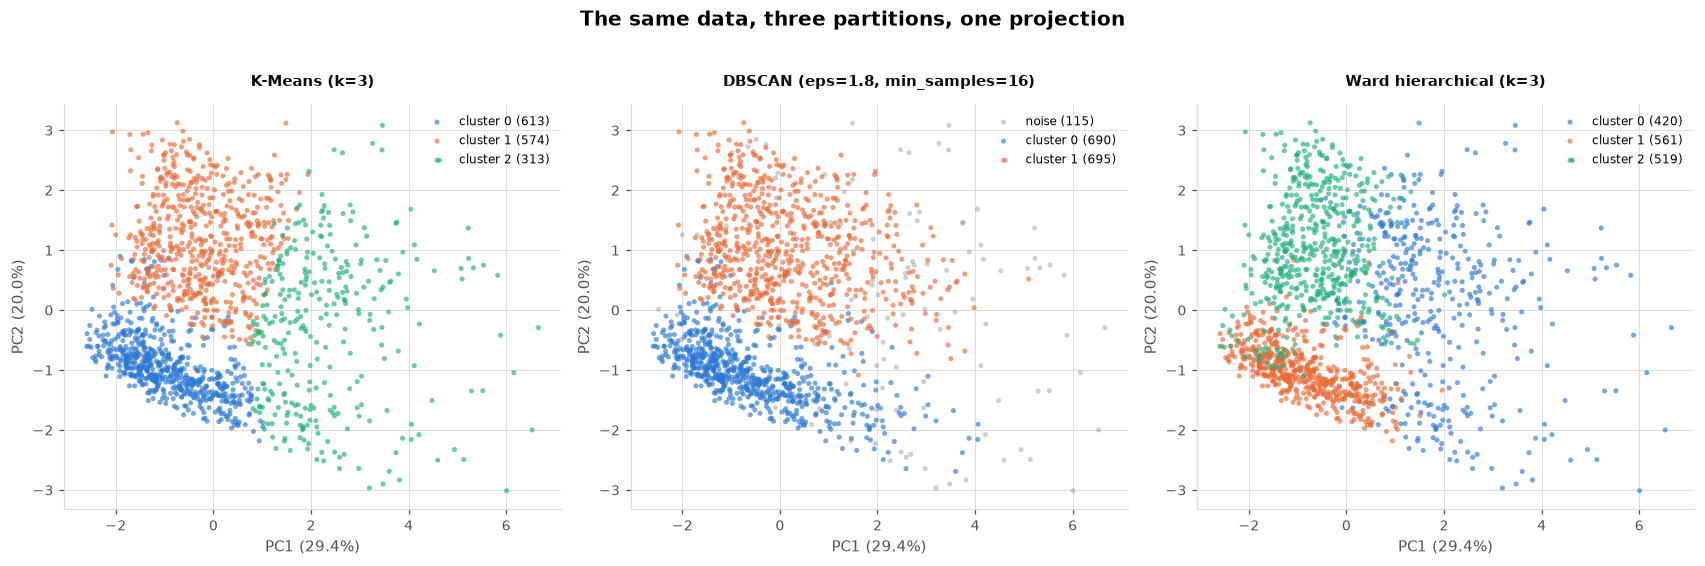

,Games,copiesSold,price,revenue,avgPlaytime,reviewScore,daysOnSale,publisherReleaseCount,selfPublished,Indie share,Median revenue
cluster,,,,,,,,,,,
0,613,-0.35,-0.37,-0.47,-0.21,-0.02,0.05,-0.58,1.02,0.995,62138.0
1,574,-0.38,0.00,-0.33,-0.24,-0.00,-0.07,0.57,-0.98,0.840,85000.0
2,313,1.39,0.71,1.54,0.85,0.04,0.04,0.08,-0.20,0.671,1756839.0


In [24]:
display(agreement_matrix(labellings))
display(plot_clusters_on_pca(scores, labellings, variance))
display(profile_clusters(scaled_matrix, labellings[f"K-Means (k={KMEANS_K})"], games))

### 4.5 Clusters on the PCA Projection, and Their Real-World Meaning

**Results.** Drawn on the same two components, the three partitions cut the same
undivided cloud in three different directions. No method's boundaries fall in a
gap, because there are no gaps. Agreement between methods is moderate at best:
ARI 0.650 between K-Means and Ward, 0.655 between K-Means and DBSCAN, and 0.481
between Ward and DBSCAN.

The K-Means profile shows what its clusters mean in the original variables.
Cluster 2 has the highest revenue, copies, price and playtime; cluster 0 the
lowest; cluster 1 sits between them and is distinguished mainly by publishing
structure.

**Interpretation — do the clusters have a meaningful real-world reading?**
**Partially, and less than they appear to.**

They *can* be described in domain terms: one group of small, cheap,
self-published titles with modest revenue; one group of larger, costlier titles
from established publishers; and an intermediate group. That description is
accurate — the profiles support it — and it is the kind of statement a
non-technical reader would find intuitive.

But it does not follow that these are *distinct kinds of game*. The same
description would be produced by cutting a single continuous gradient into three
parts at arbitrary points, and every piece of evidence in this chapter says that
is what is happening: no elbow, silhouette below 0.25 everywhere, no density gap,
a cophenetic correlation of 0.487, moderate inter-method agreement, and no
visible separation in the projection. The annotation in section 3.3 pointed the
same way — studio scale shifts a game along PC1 but does not place it in a
distinct region.

**The honest conclusion is that these clusters are useful as descriptive strata
and not as discovered categories.** Calling cluster 2 "the AAA segment" would be
defensible as shorthand and misleading as a claim about the data. The assignment
explicitly allows for this outcome, and it is what the evidence supports.

Cophenetic correlation of the feature dendrogram: 0.949
  (for comparison, the best sample dendrogram achieved 0.679)


,Composition
Groups,
2,"copiesSold, price, revenue, avgPlaytime, publisherReleaseCount, selfPublished | reviewScore, day..."
3,"copiesSold, price, revenue, avgPlaytime, publisherReleaseCount, selfPublished | reviewScore | da..."
4,"publisherReleaseCount, selfPublished | copiesSold, price, revenue, avgPlaytime | reviewScore | d..."


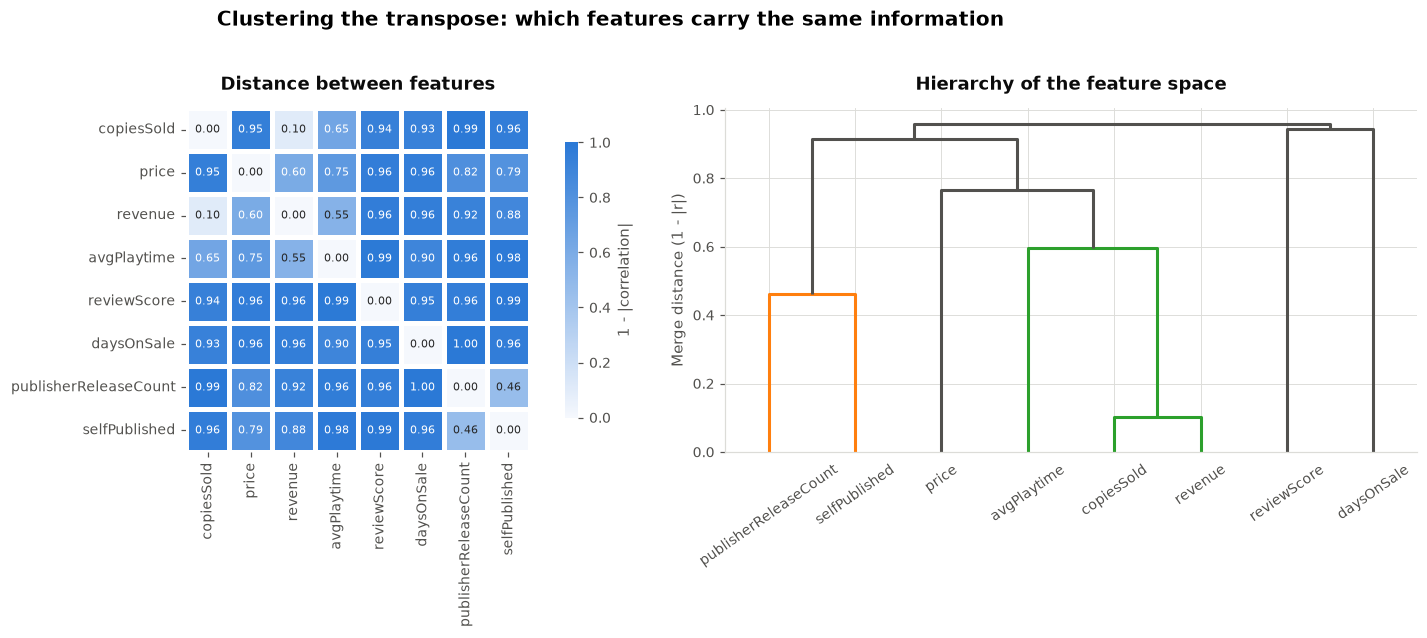

,Closest other feature,Distance to it,Mean distance to all others
reviewScore,copiesSold,0.94,0.962
daysOnSale,avgPlaytime,0.90,0.950
publisherReleaseCount,selfPublished,0.46,0.873
selfPublished,publisherReleaseCount,0.46,0.861
price,revenue,0.60,0.832
avgPlaytime,revenue,0.55,0.825
copiesSold,revenue,0.10,0.789
revenue,copiesSold,0.10,0.711


In [25]:
feature_distance = feature_distance_matrix(scaled_matrix)
feature_groups, feature_tree, cophenetic_r = cluster_features(feature_distance)

print(f"Cophenetic correlation of the feature dendrogram: {cophenetic_r:.3f}")
print("  (for comparison, the best sample dendrogram achieved 0.679)")
display(feature_groups)
display(plot_feature_space(feature_distance, feature_tree))
display(feature_isolation(feature_distance))

### 4.6 Clustering the Feature Space

**Method.** The assignment requires clustering the transpose of the data matrix —
grouping the eight *features* rather than the 1,500 games. This needs a notion of
distance between columns, and correlation distance $d(i,j)=1-|r_{ij}|$ is the
natural choice: two features are close when they carry the same information,
regardless of the sign of the relationship. Average linkage is used, since Ward's
variance criterion has no meaning on a correlation distance.

**Results.** The feature dendrogram has a cophenetic correlation of **0.949**,
against 0.487 for the best sample clustering by Ward. Cutting it into four groups
gives:

| Group | Features |
|---|---|
| Commercial scale | `copiesSold`, `revenue`, `price`, `avgPlaytime` |
| Publishing structure | `publisherReleaseCount`, `selfPublished` |
| Isolated | `reviewScore` |
| Isolated | `daysOnSale` |

**Interpretation — the five questions the assignment asks.**

**What information does clustering the features give?** A map of which variables
are substitutes for one another. `copiesSold` and `revenue` merge at a distance
of **0.10** — they are 90% redundant, and either could stand for the other in
almost any analysis. That single fact is more actionable for feature selection
than anything the sample clustering produced.

**Did it reveal related or redundant features?** Yes, two groups. The commercial
block is genuinely redundant at its core: the `copiesSold`–`revenue` pair is the
accounting identity established in chapter 1, with `price` and `avgPlaytime`
attaching more loosely at distances of 0.60 and 0.55. The publishing pair merges
at 0.46, reflecting that prolific publishers rarely publish their own games.

**Were any features isolated?** Two, clearly. **`reviewScore` has a mean distance
of 0.962 to all other features and `daysOnSale` 0.950** — both close to the
maximum of 1.0, meaning they share almost no information with anything else in
the matrix. `reviewScore` is the more striking: critical reception is essentially
orthogonal to every commercial and structural variable recorded here.

**Did it reveal anything the sample clustering did not?** Yes, and this is the
most useful contrast in the chapter. **The sample space has no reliable
hierarchy — cophenetic 0.487 — while the feature space has a very clean one at
0.949.** The 1,500 games do not fall into groups, but the eight variables
demonstrably do. Structure exists in this dataset; it lives in the relationships
between the columns, not in the arrangement of the rows.

It also independently reproduces the PCA result by a different route: the
commercial block corresponds to PC1, the publishing pair to PC2, and the two
isolated features to the PC3 subspace. Two methods with different objectives
recovering the same organisation is stronger evidence than either alone.

**Where is feature clustering useful?** Wherever features are numerous and
partly redundant: selecting one representative per group to reduce
dimensionality without a projection, which preserves interpretability in a way
PCA does not; detecting sensor duplication in IoT and industrial monitoring;
grouping co-expressed genes; and identifying multicollinearity before fitting a
regression. It is most valuable when $p$ is large enough that the correlation
matrix cannot simply be read.

**Conclusion for this section.** Clustering the feature space succeeded where
clustering the samples did not. It found a clean, stable hierarchy, quantified
the redundancy between `copiesSold` and `revenue`, and identified `reviewScore`
and `daysOnSale` as carrying independent information.

### 4.7 Discussion

**Why do different algorithms produce different clusters?** Because each
optimises a different objective, and when no strong structure exists the
objective is what determines the answer. K-Means minimises within-cluster
variance and therefore produces compact, roughly equal-sized groups; it cut the
commercial-scale axis. DBSCAN seeks density-connected regions and found the
binary gap in `selfPublished`. Ward minimises variance increase at each merge and
produced a third partition. The ARI values of 0.48 to 0.66 between them quantify
the disagreement, and the near-zero ARI of **0.087** between DBSCAN and K-Means
at $k=2$ shows how complete it can be. **On data with genuine separation these
methods would largely agree; the disagreement is the evidence that separation is
absent.**

**Sensitivity to hyperparameters.** DBSCAN is the extreme case: `eps` moving from
2.0 to 2.2 — a change of 10% — takes the result from two clusters covering 95% of
the data to one cluster covering 97%. K-Means is sensitive to $k$, which no
internal criterion here selects convincingly. Ward is sensitive to the cut height,
and the linkage comparison showed the rule itself matters more than the cut:
single and Ward linkage on identical data produced partitions of [1498, 1, 1] and
[420, 561, 519]. Separately from these tuning parameters, section 4.2 showed the
result also depends on the **feature-space representation** — including one
binary column changed what DBSCAN found entirely.

**Cluster geometry.** The methods assume different shapes: K-Means spherical and
isotropic, Ward compact and variance-minimising, DBSCAN arbitrary but of uniform
density. The observed geometry is a single elongated cloud, denser at low PC1 and
thinning towards high PC1 — the shape of a heavy-tailed distribution after a log
transform, not of separated groups. None of the three assumed shapes matches it,
which is why none produced a convincing partition.

**Density-based versus centroid-based.** The contrast is sharp here. The
centroid-based methods partitioned the continuum into slices; the density-based
method refused to, collapsing everything into one cluster as soon as `eps`
exceeded 2.1. DBSCAN's answer is arguably the more informative: it is capable of
reporting "one cluster and some noise", and that is close to what it reported.
K-Means has no way to express that conclusion, because it must return exactly
$k$ non-empty clusters whatever the data looks like.

**When can clustering fail?** This dataset illustrates three modes. It fails when
**no cluster structure exists** and the data is a single continuous population —
the situation here, where the algorithms still return partitions that look
plausible. It fails when **the representation dominates the geometry**, as the
binary feature did for DBSCAN. And it fails when **the evaluation metric is
aligned with one method's objective**, as the variance ratio is with K-Means,
so the comparison is decided before it begins.

**Conclusion.** The evidence points consistently in one direction. Silhouette
never exceeds 0.214 across any method or parameter setting; inertia shows no
elbow; DBSCAN finds no density gap and collapses to a single cluster at a
moderate radius; the sample dendrogram has a cophenetic correlation of 0.487; the
methods agree with each other only moderately; and the PCA projections show one
undivided cloud. **This dataset does not appear to contain distinct clusters of
games.** The partitions produced here are defensible as descriptive strata along
a commercial-scale gradient, and should not be presented as discovered
categories. The structure that does exist in this dataset is between its
features, not between its rows — and section 4.6 found it cleanly.

## 5. Multi-Dimensional Anomaly Detection

**Method.** Three methods are applied to the same eight-dimensional standardised
matrix: a classical Z-score approach, Isolation Forest, and the Local Outlier
Factor. Each is set to flag **5% of the games — 75 of 1,500** — so that chapter 6
compares what the methods *choose* rather than how much they choose.

Two constraints established earlier carry into this chapter. All three run on the
full matrix rather than on a projection, because section 3.4 showed the 2D
projection preserves only 85% of local neighbourhood structure and two of these
methods depend entirely on local neighbourhoods. And chapter 1 established that
`revenue` and `copiesSold` are **estimates rather than measurements**, so a
flagged point may be unusual because the vendor's model behaved unusually, not
because the game did. That possibility cannot be resolved from this data and is
carried into chapter 6.

**Configuration.** Every setting used in this chapter is listed below in one
place, together with the scikit-learn class that consumes it, so the exact
estimators behind each result can be read off the notebook without opening a
module. The reasoning for each value is given in the section that uses it.

In [26]:
from unsupervised.anomaly import describe_hyperparameters

with pd.option_context("display.max_colwidth", 92):
    display(describe_hyperparameters())

,scikit-learn class,Configuration,Why this value
Step,,,
Preprocessing: imputation,SimpleImputer,strategy='median',Fills the 100 placeholder-derived missing values; median because section 2.2 showed the ...
Preprocessing: scaling,StandardScaler,"default (zero mean, unit variance)",Required by every distance-based method here; section 6.3 shows LOF loses 80% of its fla...
"Z-score, feature-wise",numpy / pandas (no estimator),threshold |z| > 3,Conventional 3-sigma cut; section 5.1 shows the Gaussian basis for it does not hold for ...
"Z-score, global",numpy.linalg.pinv (Mahalanobis),top 5% by squared distance,Covariance-aware alternative to the feature-wise rule; cut at the same share as the othe...
Isolation Forest,IsolationForest,"n_estimators=300, contamination=0.05, random_state=42, n_jobs=-1","300 trees for a stable path-length average; contamination is a cut on the ranking, not a..."
Local Outlier Factor,LocalOutlierFactor,"n_neighbors=20, contamination=0.05",k=20 sits inside the usual 10-50 range; section 5.3 measures how much the flagged set mo...


,Shapiro-Wilk W,p-value,Normal at 1%,Max |z| observed,Games with |z| > 3
Feature,,,,,
copiesSold,0.944,5.5e-19,no,4.73,17
price,0.873,9.7e-28,no,6.52,34
revenue,0.905,1.7e-24,no,4.94,20
avgPlaytime,0.992,3.3e-05,no,3.72,7
reviewScore,0.892,6.7e-26,no,5.26,19
daysOnSale,0.960,5.6e-16,no,1.83,0
publisherReleaseCount,0.735,4.0e-37,no,2.72,0
selfPublished,0.637,1.4e-41,no,1.02,0


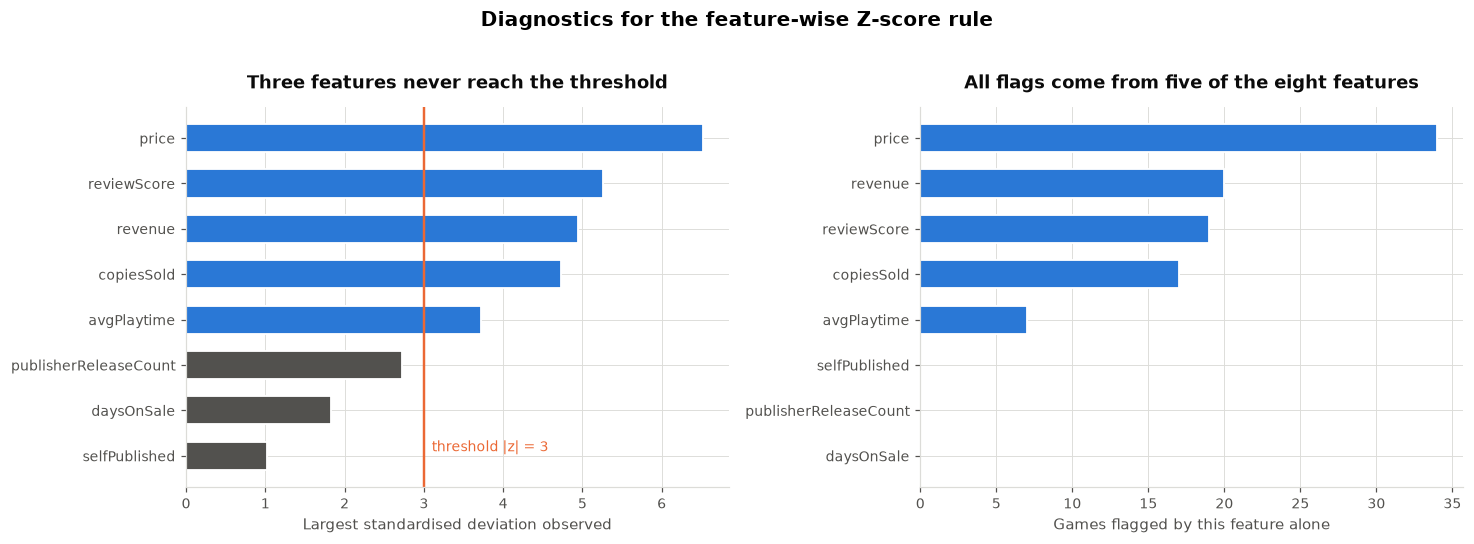

In [27]:
from unsupervised.anomaly import (
    CONTAMINATION,
    LOF_NEIGHBOURS,
    ZSCORE_THRESHOLD,
    collect_flags,
    compare_zscore_views,
    isolation_forest_scores,
    isolation_forest_seed_stability,
    isolation_forest_sweep,
    lof_scores,
    lof_sweep,
    mahalanobis_distance,
    normality_diagnostics,
    zscore_featurewise,
    zscore_threshold_sweep,
)
from unsupervised.plots import (
    plot_anomalies_on_pca,
    plot_lof_sensitivity,
    plot_score_distribution,
    plot_zscore_diagnostics,
)

normality = normality_diagnostics(scaled_matrix)
display(normality)
display(plot_zscore_diagnostics(normality, ZSCORE_THRESHOLD))

### 5.1 The Z-Score Method

**Mathematical intuition.** The classical approach standardises each feature and
flags values far from the mean:

$$z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j},\qquad \text{flag if } |z_{ij}|>3 .$$

The threshold of 3 is not arbitrary: under a normal distribution, 99.7% of mass
lies within three standard deviations, so $|z|>3$ marks the rarest 0.3%. **That
interpretation is the whole justification for the rule, and it holds only if the
feature is normally distributed.**

**The Gaussian assumption does not hold here.** Shapiro-Wilk rejects normality for
**all eight features**, with p-values from $5.5\times10^{-19}$ to
$1.4\times10^{-41}$ — and this is *after* the log transform of section 2.3, which
already reduced revenue's skewness from 22.9 to 1.19. The assumption fails not
marginally but comprehensively.

**Three features cannot flag anything at all.** The largest standardised deviation
observed is 1.02 for `selfPublished`, 1.83 for `daysOnSale` and 2.72 for
`publisherReleaseCount` — all below the threshold. For a balanced binary feature
this is arithmetic rather than accident: with $p\approx0.5$ the standard deviation
is about 0.5 and the furthest possible value is about one standard deviation from
the mean, so **no binary feature can ever produce a Z-score anomaly.** The
uniform-ish `daysOnSale` has the same problem for the same underlying reason: a
distribution with no tail cannot produce a tail event.

The consequence is that **the rule sees only five of the eight features.** Every
flag it produces comes from `price` (34), `revenue` (20), `reviewScore` (19),
`copiesSold` (17) or `avgPlaytime` (7). A game that is unusual in its publishing
structure — the dimension PC2 identified as carrying 20% of the variance — is
invisible to this method by construction.

In [28]:
display(zscore_threshold_sweep(scaled_matrix))
display(compare_zscore_views(scaled_matrix))

,Games flagged,Expected if truly Gaussian
Threshold,,
2.5,171,142.7
3.0,80,32.1
3.5,39,5.6
4.0,23,0.8


,Value
Quantity,
"Feature-wise, any |z| > 3",80.00
"Global, Mahalanobis top 5%",75.00
Flagged by both,51.00
Flagged by only one,53.00
Jaccard agreement,0.49
Chi-squared 99% critical value (df=8),20.09
Games beyond that critical value,74.00


**Why this approach struggles in higher dimensions.** Two distinct problems, both
visible in the tables above.

**Multiple comparisons.** Applying a per-feature test to $p$ features multiplies
the chance that at least one exceeds the cut. If the data really were Gaussian,
the probability that a row trips $|z|>3$ on at least one of eight independent
features is $1-(1-0.0027)^8 = 0.021$ — about **32 of 1,500 games flagged by
chance alone**. The rule actually flags 80. The excess is real, but it means
roughly 40% of the flags at this threshold are what a perfectly ordinary Gaussian
dataset would produce. The effect worsens with dimension: at $p=50$ the expected
chance rate would exceed 12%.

The threshold sweep shows the tails departing from Gaussian as the cut rises:
80 observed against 32.1 expected at $|z|>3$, 39 against 5.6 at 3.5, and 23
against 0.8 at 4.0. The further out one looks, the less the Gaussian model
explains — which is the signature of heavy tails.

**Feature-wise testing ignores the correlations.** The rule examines one feature
at a time, so it cannot detect a game whose individual values are all ordinary but
whose *combination* is not. Section 3.2 established that `copiesSold` and
`revenue` correlate at 0.90; a title with typical copies and typical revenue but
in the wrong ratio violates the dataset's strongest relationship, and the
feature-wise rule will not notice.

**The global alternative.** The Mahalanobis distance measures distance from the
centre in a space stretched by the inverse covariance,

$$d^2(x)=(x-\mu)^{\top}\Sigma^{-1}(x-\mu),$$

which is distributed as $\chi^2_p$ under multivariate normality. It accounts for
the correlations the feature-wise rule ignores, and it produces a single ranking
rather than eight separate tests.

**The two disagree on half their flags.** The feature-wise rule flags 80 games and
the global rule 75, but their **Jaccard agreement is only 0.49**. Roughly half the
games each identifies, the other does not. "Anomalous by Z-score" is therefore not
one definition but two, and the choice between them changes the answer as much as
changing the method would. The global version is used for the comparison in
chapter 6, because it accounts for the correlation structure and yields a ranking
that can be cut at the same 5% as the other two methods.

,Games flagged,Score cut-off,Seconds
Contamination,,,
0.01,15,0.620,0.216
0.02,30,0.601,0.194
0.05,75,0.574,0.193
0.10,150,0.539,0.205
0.15,225,0.519,0.199


Lower-contamination flags are nested inside higher-contamination flags: True


Anomaly score range: min=0.393  median=0.464  max=0.673


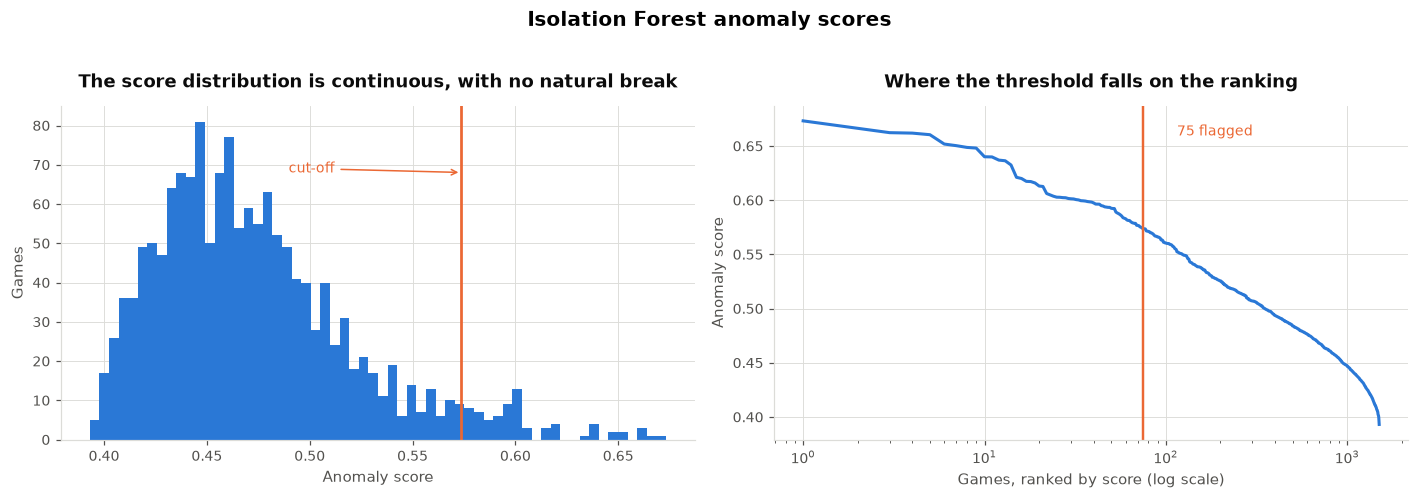

,Jaccard with seed 42
Seed,
1,0.786
2,0.852
3,0.807
4,0.829


In [29]:
sweep = isolation_forest_sweep(scaled_matrix)
display(sweep)
print(f"Lower-contamination flags are nested inside higher-contamination flags: {sweep.attrs['nested']}")

isolation_score, isolation_flags = isolation_forest_scores(scaled_matrix)
print(f"Anomaly score range: min={isolation_score.min():.3f}  "
      f"median={np.median(isolation_score):.3f}  max={isolation_score.max():.3f}")
display(plot_score_distribution(isolation_score, isolation_flags.to_numpy(),
                                "Isolation Forest anomaly scores", "Anomaly score"))
display(isolation_forest_seed_stability(scaled_matrix))

### 5.2 Isolation Forest

**The isolation mechanism.** Isolation Forest inverts the usual approach. Rather
than modelling what normal looks like and measuring departures from it, it asks
how hard each point is to *separate* from the rest. It builds many random binary
trees: at each node it picks a feature at random and a split value at random
between that feature's minimum and maximum, and it recurses until every point sits
alone in a leaf.

**The role of random partitioning.** The insight is that **anomalies are isolated
in fewer splits.** A point in a dense region needs many cuts before the region
around it is narrowed to that point alone, because every cut still leaves
neighbours on the same side. A point far from the rest is separated by a few cuts,
because a random split anywhere in the large empty gap around it will cut it off.
Averaging the path length over many random trees turns that observation into a
stable score, and randomness is what makes it cheap: no distances are computed at
all.

**How the score is calculated.** For a point $x$ with average path length $E[h(x)]$
across the forest, the score is

$$s(x,n)=2^{-\frac{E[h(x)]}{c(n)}},\qquad c(n)=2H(n-1)-\frac{2(n-1)}{n},$$

where $c(n)$ is the average path length of an unsuccessful search in a random
binary tree, used to normalise for sample size. The score lies in $(0,1)$: values
near 1 mean the point was isolated much faster than average and is likely
anomalous; values near 0.5 mean it took a typical number of splits; values well
below 0.5 mean it sits deep inside a dense region.

**Observed scores range from 0.393 to 0.673 with a median of 0.464.** Nothing
approaches 1. The highest-scoring game in this dataset was isolated meaningfully
faster than average but not dramatically so — consistent with everything chapters
3 and 4 found about the absence of separated structure.

**The contamination parameter.** Contamination does *not* change how the forest
scores points; it only decides where to cut the resulting ranking. The sweep makes
this explicit: the flag counts are exactly 1%, 2%, 5%, 10% and 15% of the data,
and **the flags at each level are strictly nested inside the next** — every game
flagged at 1% is also flagged at 15%. The score distribution is smooth and
continuous with no natural break, so **no value of contamination is discoverable
from the data.** It is an assumption about how many anomalies one believes exist,
supplied by the analyst, and it should be reported as such rather than defended as
a finding. The 5% used here is a convention chosen to match the other two methods,
not an estimate.

**Advantages and limitations, especially in high dimensions.** The method needs no
distance computations, no density estimates and no distributional assumptions; it
runs in roughly linear time and handled this dataset in about 0.2 seconds. Its
main high-dimensional advantage is that it avoids the distance concentration
problem that afflicts LOF, discussed in chapter 7. Its main high-dimensional
*limitation* is the mirror image: because each split uses a single feature chosen
at random, irrelevant features dilute the signal — with many noise dimensions,
most splits are wasted, and the method degrades. It is also **not deterministic**:
across five random seeds the flagged set agrees with the reference only at Jaccard
**0.786 to 0.852**, meaning roughly one flagged game in six changes when only the
seed changes. Any single run overstates the certainty of its own output.

,Games flagged,Max LOF score,Median LOF score,Seconds,Jaccard with k=20
n_neighbors,,,,,
5,75,1.91,1.047,0.006,0.429
10,75,1.78,1.049,0.008,0.613
20,75,1.75,1.054,0.011,1.000
35,75,1.74,1.055,0.014,0.705
50,75,1.76,1.054,0.017,0.630
100,75,1.80,1.046,0.025,0.471


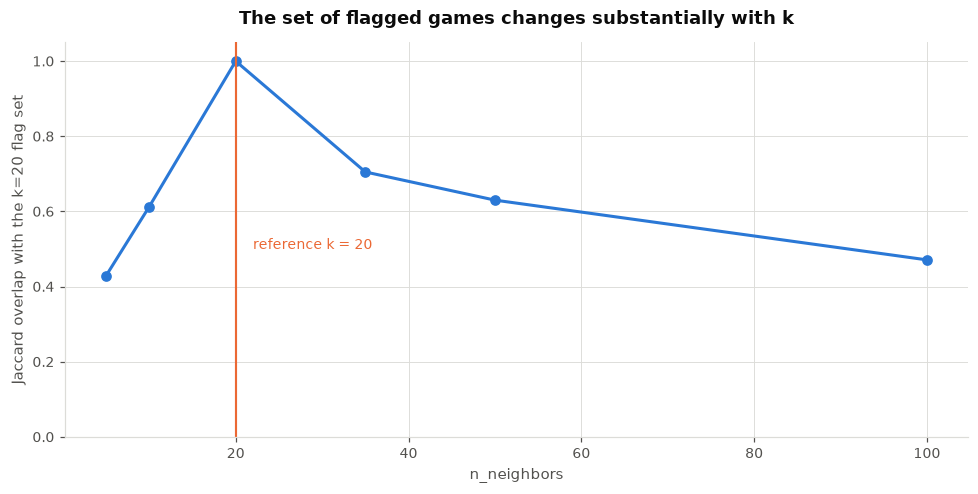

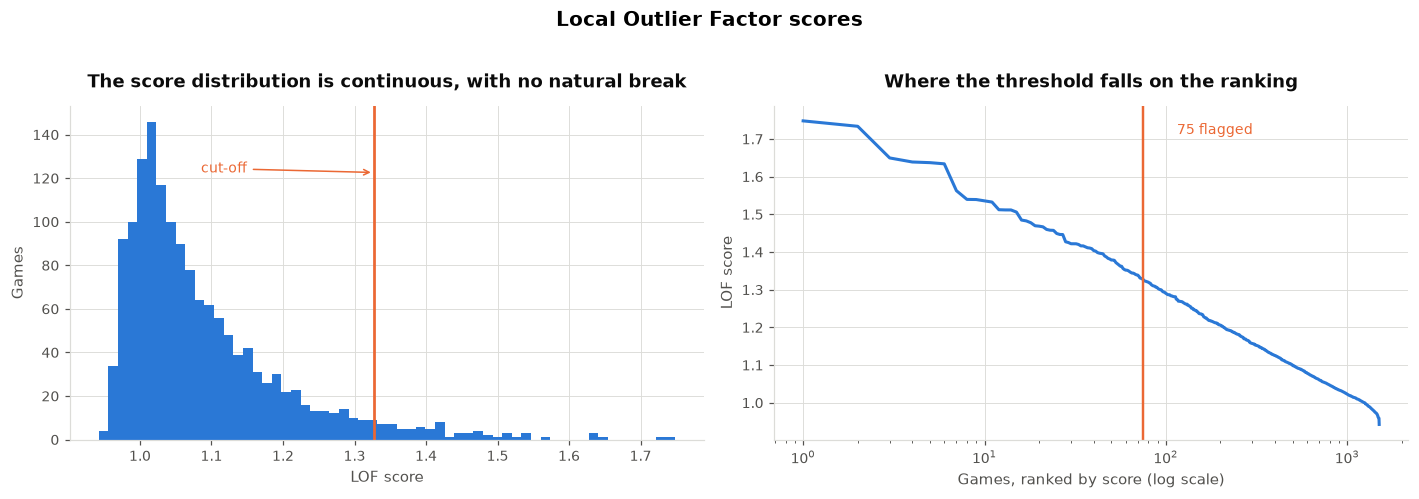

In [30]:
lof_table, _ = lof_sweep(scaled_matrix)
display(lof_table)
display(plot_lof_sensitivity(lof_table, LOF_NEIGHBOURS))

lof_score, lof_flags = lof_scores(scaled_matrix)
display(plot_score_distribution(lof_score, lof_flags.to_numpy(),
                                "Local Outlier Factor scores", "LOF score"))

### 5.3 Local Outlier Factor

**Mathematical intuition — local density.** LOF asks a different question from the
first two methods: not "is this point far from the centre" but **"is this point in
a sparser neighbourhood than its own neighbours are?"**

For a point $p$, the *reachability distance* to a neighbour $o$ is
$\max\{\text{k-dist}(o),\ d(p,o)\}$, which smooths the effect of very close pairs.
The *local reachability density* is the inverse of the mean reachability distance
to $p$'s $k$ nearest neighbours. The LOF score is then the ratio of the neighbours'
densities to the point's own:

$$\mathrm{LOF}_k(p)=\frac{1}{|N_k(p)|}\sum_{o\in N_k(p)}\frac{\mathrm{lrd}_k(o)}{\mathrm{lrd}_k(p)} .$$

A score near 1 means the point is about as densely surrounded as its neighbours
are. A score well above 1 means its neighbours live in denser regions than it does
— it sits in a hole.

**Why this matters: global versus local anomalies.** Because the score is a
*ratio*, it is scale-free with respect to density. A point in a sparse region
whose neighbours are equally sparse scores near 1 and is not flagged, even if it is
far from the global centre. Conversely a point in a moderately dense region can be
flagged if the points immediately around it are much denser. **LOF finds locally
isolated points; Mahalanobis and Isolation Forest find globally extreme ones.**
These are genuinely different notions of anomaly, not two approximations of one.

**Observed scores** run from about 1.0 to **1.75** at $k=20$, with a median of
1.054. As with the forest, the distribution is smooth: most games sit at the "as
dense as my neighbours" value and the tail thins gradually. There is no natural
cut.

**Sensitivity to $k$ — this is the method's main weakness and it is substantial
here.** $k$ defines what "local" means, and the flagged set changes considerably
with it. Against the $k=20$ reference the Jaccard overlap is:

| k | 5 | 10 | 20 | 35 | 50 | 100 |
|---|---|---|---|---|---|---|
| Overlap with k=20 | **0.429** | 0.613 | 1.000 | 0.705 | 0.630 | **0.471** |

At $k=5$ only 43% of the flagged games are shared with $k=20$; at $k=100$, 47%.
**More than half the flagged set can be replaced by changing a parameter that no
criterion in the data selects.** Small $k$ makes the method sensitive to individual
sampling noise — a point in a small gap looks isolated. Large $k$ makes the
neighbourhood so broad that "local" approaches "global" and LOF converges towards
the behaviour of the other two methods. The value of 20 used here sits in the
usual recommended range of 10–50 and is a convention, not a discovery.

**Neighbourhood effects.** Because the comparison is with a point's own
neighbours, LOF adapts automatically to regions of differing density — its main
advantage over a single global threshold, and the reason it can flag a game
sitting in a small hole inside an otherwise dense region. The cost is that the
score depends on a local sample of $k$ points, so it is noisier than a global
statistic, particularly at small $k$. It is also the most expensive of the three
per unit of data at large $n$, since it requires a nearest-neighbour search,
although at $n=1{,}500$ it was the fastest of the three in absolute terms.

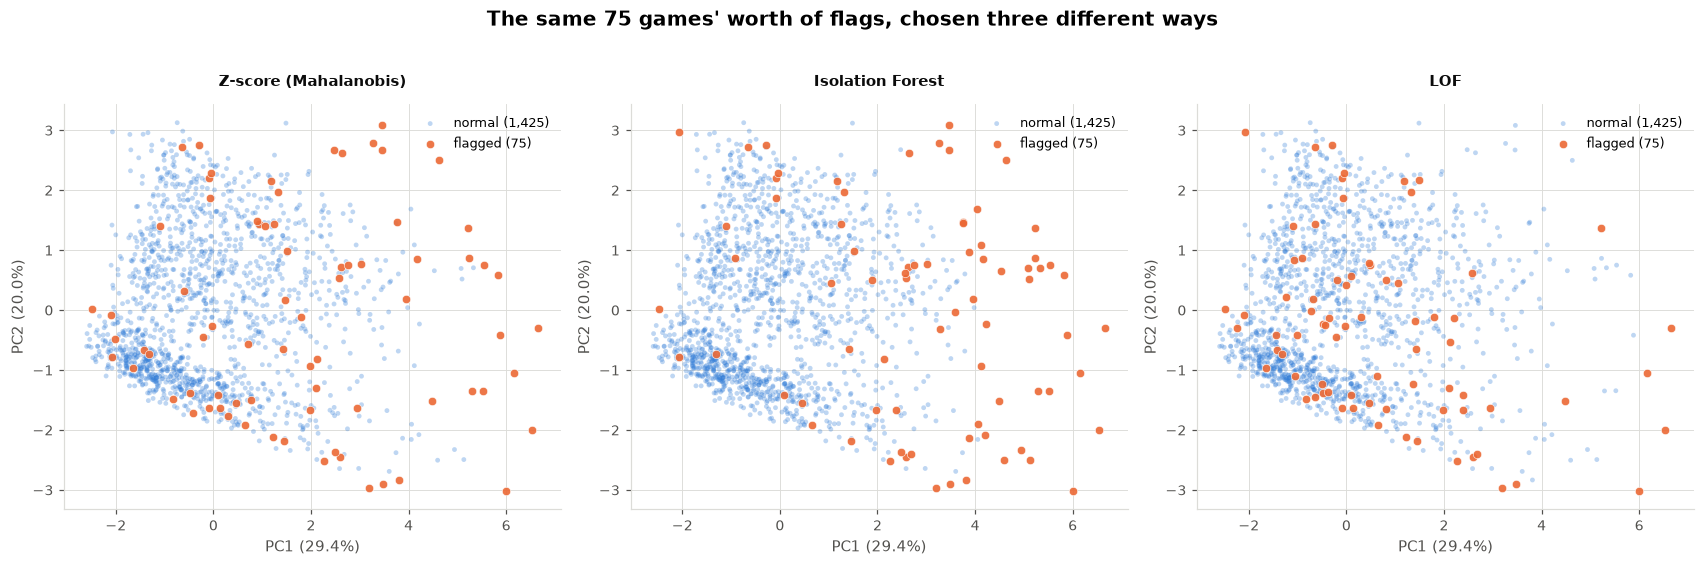

,Games
Outcome,
Flagged by all three,26
Flagged by exactly two,43
Flagged by exactly one,61
Flagged by at least one,130


Flagged by all three methods (highest Mahalanobis distance):


,name,revenue,copiesSold,price,avgPlaytime,reviewScore,daysOnSale
1218,Perfect World M,8.257660e+05,3768,0.00,46.929039,33.0,200
0,WWE 2K24,8.055097e+06,165301,99.99,42.365140,71.0,186
567,吞食天地2：誕生Reborn,2.562504e+06,28202,0.00,239.439797,42.0,206
534,失乐星图Nornium,6.084600e+04,67552,0.00,2.178058,15.0,31
1455,The First Descendant,1.022448e+08,4043850,0.00,49.870230,55.0,71


In [31]:
anomaly_flags = collect_flags(scaled_matrix)
display(plot_anomalies_on_pca(scores[:, :2], anomaly_flags, variance))

flag_counts = anomaly_flags.sum(axis=1)
summary = pd.DataFrame(
    [
        ("Flagged by all three", int((flag_counts == 3).sum())),
        ("Flagged by exactly two", int((flag_counts == 2).sum())),
        ("Flagged by exactly one", int((flag_counts == 1).sum())),
        ("Flagged by at least one", int((flag_counts >= 1).sum())),
    ],
    columns=["Outcome", "Games"],
).set_index("Outcome")
display(summary)

interesting = games.assign(
    methods=flag_counts.to_numpy(),
    mahalanobis=mahalanobis_distance(scaled_matrix),
)
columns = ["name", "revenue", "copiesSold", "price", "avgPlaytime", "reviewScore", "daysOnSale"]
print("Flagged by all three methods (highest Mahalanobis distance):")
display(interesting[flag_counts.to_numpy() == 3].nlargest(5, "mahalanobis")[columns])

**Visualising the flags — and a first look at the disagreement.** Plotted on the
same two components, the three methods mark visibly different points. Isolation
Forest concentrates its flags at high PC1, the commercial-scale extreme.
Mahalanobis spreads them around the periphery in all directions. LOF scatters
them, including several well inside the cloud where no global method would look.

Of the 75 games each method flags, **only 26 are flagged by all three, while 61
are flagged by exactly one method and 130 games are flagged by at least one.**
Chapter 6 examines this disagreement in detail; for now it establishes that the
three methods are not three approximations of a single underlying truth.

The games all three agree on are those extreme in several features at once —
free-to-play titles with very high playtime such as *Firestone: Online Idle RPG*
at 296 hours, *The First Descendant* earning $102M at a listed price of zero, and
*WWE 2K24* at the maximum observed price of $99.99. These are the points that are
globally distant, structurally isolable and locally sparse simultaneously.

**A caution before chapter 6.** Every one of these games is a *statistical*
anomaly by construction — that is what the methods compute. Whether any is a data
error, a legitimate rare observation, or an artefact of the vendor's revenue
estimator is a separate question that the flags themselves cannot answer. Section
2.4 already showed that the 296-hour playtimes belong to a coherent genre of idle
games and are entirely legitimate. Chapter 6 takes up that distinction directly.

## 6. Comparison of Anomaly Detection Methods

**Method.** Each property the assignment asks about is settled by an experiment
rather than argued from the methods' definitions. Scaling sensitivity is measured
by re-running on differently preprocessed matrices; dimensionality sensitivity by
appending pure-noise columns; robustness by perturbing every value; and
scalability by timing on progressively larger datasets. All three methods flag
the same 5%, so every comparison is of *which* games, never how many.

,Z-score (Mahalanobis),Isolation Forest,LOF
Z-score (Mahalanobis),1.000,0.500,0.351
Isolation Forest,0.500,1.000,0.271
LOF,0.351,0.271,1.000


,Games
Outcome,
Flagged by all three,26
Flagged by exactly two,43
Flagged by exactly one,61
Flagged by at least one,130
Flagged by none,1370


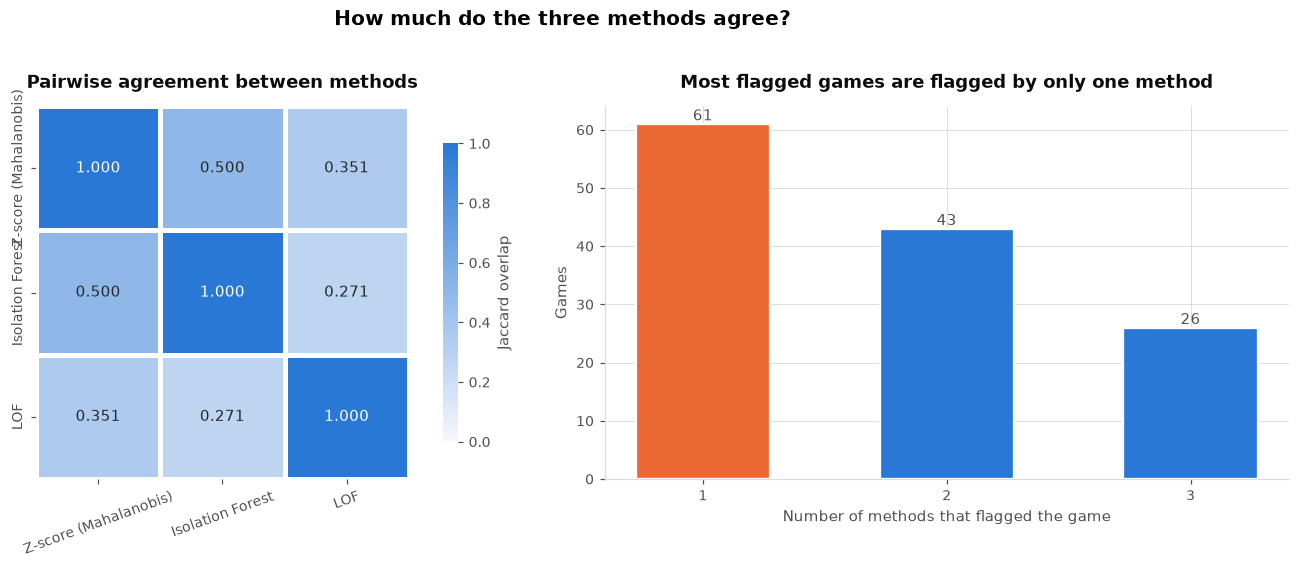

In [32]:
from unsupervised.comparison import (
    METHOD_NAMES,
    agreement_table,
    consensus_summary,
    dimensionality_sensitivity,
    flag_all,
    method_specific_examples,
    noise_robustness,
    runtime_scaling,
    scaling_sensitivity,
)
from unsupervised.plots import plot_method_agreement, plot_runtime, plot_sensitivity_curves

method_flags = flag_all(scaled_matrix)
agreement = agreement_table(method_flags)
consensus, methods_per_game = consensus_summary(method_flags)

display(agreement)
display(consensus)
display(plot_method_agreement(agreement, methods_per_game))

### 6.1 Which Anomalies Are Found by More Than One Method?

**Results.** Each method flags exactly 75 games. Their pairwise agreement:

| | Z-score (Mahalanobis) | Isolation Forest | LOF |
|---|---|---|---|
| **Z-score** | 1.000 | 0.500 | 0.351 |
| **Isolation Forest** | 0.500 | 1.000 | **0.271** |
| **LOF** | 0.351 | 0.271 | 1.000 |

| Outcome | Games |
|---|---|
| Flagged by all three | **26** |
| Flagged by exactly two | 43 |
| Flagged by exactly one | **61** |
| Flagged by at least one | 130 |

**Interpretation.** The level of agreement is **low, and lower than it first
appears.** Of the 130 games flagged by any method, fewer than one in five is
flagged by all three, and nearly half are flagged by a single method. The closest
pair — Mahalanobis and Isolation Forest — share only half their flags, and the
most distant pair, Isolation Forest and LOF, share barely a quarter.

Two conclusions follow, and the second matters more.

The first is that **"the anomalies in this dataset" is not a well-defined set.**
Running one method and reporting its 75 games would give an answer; running a
different method would give a substantially different answer with equal
justification. Which 75 games are anomalous depends on a choice the analyst makes
before seeing any output.

The second is that the disagreement is **not noise but structure**. If the three
methods were noisy estimators of one underlying truth, their overlaps would be
similar to each other. Instead the overlaps are ordered — 0.50, 0.35, 0.27 — and
that ordering matches how similar the methods' definitions of "anomalous" are.
Mahalanobis and Isolation Forest both measure global extremity and agree most;
LOF measures local isolation and agrees least with both. **The methods are
answering different questions and getting different, defensible answers.**

The 26 games all three agree on are those that are simultaneously far from the
centre, easy to isolate and locally sparse — games extreme in several features at
once, such as free-to-play titles with several hundred hours of average playtime.

In [33]:
example_columns = ["name", "revenue", "copiesSold", "price", "avgPlaytime", "reviewScore", "daysOnSale"]
for method, table in method_specific_examples(games, method_flags, example_columns).items():
    print(f"--- flagged ONLY by {method} ---")
    display(table)

--- flagged ONLY by Z-score (Mahalanobis) ---


,name,revenue,copiesSold,price,avgPlaytime,reviewScore,daysOnSale
76,Idle Hero TD - Tower Defense,235863.0,13061,0.00,189.057011,79.0,129
92,HAWKED,221326.0,162606,0.00,11.438980,55.0,207
584,Atelier Resleriana: Forgotten Alchemy and the Polar Night Liberator,2197863.0,137669,0.00,37.108543,53.0,229
626,Space industrial empire,56264.0,12991,5.99,185.925274,83.0,108


--- flagged ONLY by Isolation Forest ---


,name,revenue,copiesSold,price,avgPlaytime,reviewScore,daysOnSale
1,EARTH DEFENSE FORCE 6,7882151.0,159806,59.99,29.651061,57.0,46
4,Shin Megami Tensei V: Vengeance,7629252.0,141306,59.99,34.258496,96.0,88
10,KINGDOM HEARTS -HD 1.5+2.5 ReMIX-,6828446.0,212325,49.99,30.274948,NaN,88
38,Apollo Justice: Ace Attorney Trilogy,3465018.0,89327,49.99,40.024307,93.0,229


--- flagged ONLY by LOF ---


,name,revenue,copiesSold,price,avgPlaytime,reviewScore,daysOnSale
42,Buckshot Roulette,3369649.0,1486957,2.99,2.995873,95.0,158
102,Sex Formula,217025.0,6030,39.99,1.385212,77.0,4
106,Stargate: Timekeepers,214688.0,7991,29.99,5.441418,58.0,230
195,Spy Alliance,153860.0,93601,1.99,0.940429,70.0,32


### 6.2 Which Anomalies Are Method-Specific, and Why?

**Results and interpretation.** The games each method finds alone are
characteristic of what it measures, and the pattern is consistent.

**Isolation Forest alone** flags titles such as *EARTH DEFENSE FORCE 6*, *Shin
Megami Tensei V: Vengeance* and *Apollo Justice: Ace Attorney Trilogy* — priced at
$49.99–$59.99, from publishers with several titles in the dataset. No single
value is extreme, but the *combination* of a high price with a prolific publisher
and moderate sales occupies a thinly populated region of the feature space, and
random axis-parallel splits isolate such a region quickly. This is the method's
distinctive strength: it detects unusual **combinations** without being told which
features to combine.

**LOF alone** flags games such as *Buckshot Roulette* — 1.49 million copies at
$2.99 — and *Sex Formula*, released four days before the snapshot. Neither is
globally extreme; a $2.99 price and a large copy count are individually
unremarkable. What makes them stand out is that their **immediate neighbourhood is
sparse relative to their neighbours' neighbourhoods.** *Buckshot Roulette* is a
viral cheap indie hit, and there are few other games like it, so it sits in a hole
inside an otherwise dense region. Only a local method can see that.

**Mahalanobis alone** flags games such as *Idle Hero TD* (189 hours of playtime at
a price of zero) and *Only Up!* (a review score of 24). These are extreme along a
single correlated direction, which the covariance-aware distance amplifies but
which does not create an isolable region or a local density hole.

**Why the methods differ, stated generally.** Each defines "anomalous" by a
different geometry. Mahalanobis measures distance from a single global centre in a
space warped by the covariance, so it finds points far from the middle. Isolation
Forest measures how few random axis-parallel cuts are needed to separate a point,
so it finds points in sparse *regions*. LOF measures the ratio of a point's local
density to its neighbours', so it finds points in local holes regardless of where
they sit globally. **A game can satisfy any one of these without satisfying the
others**, and 61 of the 130 flagged games do exactly that.

In [34]:
display(scaling_sensitivity(games, scaled_matrix))

,"Unscaled (log applied, no standardisation)","Raw scale (standardised, no log)"
Method,,
Z-score (Mahalanobis),1.00,0.442
Isolation Forest,1.00,0.613
LOF,0.19,0.261


### 6.3 Sensitivity to Feature Scaling

**Results.** Two different questions are separated here. Standardisation is a
*linear* rescaling of each column; the log transform of section 2.3 is a
*non-linear* change of distribution shape. Jaccard agreement against the analysis
matrix:

| Method | Unscaled (log applied, no standardisation) | Raw scale (standardised, no log) |
|---|---|---|
| Z-score (Mahalanobis) | **1.000** | 0.442 |
| Isolation Forest | **1.000** | 0.613 |
| LOF | **0.190** | 0.261 |

**Interpretation.** The result is unusually clean.

**Mahalanobis and Isolation Forest are completely invariant to standardisation.**
Both return exactly the same 75 games with or without it, and the reasons are
structural. Mahalanobis divides by the covariance matrix, so any linear rescaling
of the columns is algebraically cancelled. Isolation Forest splits one feature at a
time at a random point within that feature's own range, so rescaling a column
rescales its split points identically and the tree structure is unchanged.

**LOF is destroyed by the absence of standardisation** — a Jaccard of **0.190**,
meaning more than 80% of its flags change. LOF depends on Euclidean distances, and
on the unstandardised matrix `price` has a range of about 100 while
`selfPublished` has a range of 1. Distance becomes almost entirely a statement
about price, and the other seven features effectively disappear. **For LOF,
standardisation is not a refinement but a precondition.**

**All three are sensitive to the non-linear transform**, and this is the more
subtle point. Even with standardisation applied in both cases, moving between the
raw and log scales changes Mahalanobis's flags by more than half (0.442) and
Isolation Forest's by nearly 40% (0.613). Standardisation equalises *spread*; it
does not change *shape*, and these methods respond to shape. **Being
scale-invariant is not the same as being preprocessing-invariant**, and reporting
only the first would give a false sense of robustness.

,Total dimensions,Z-score (Mahalanobis),Isolation Forest,LOF
Noise dimensions added,,,,
0,8,1.000,1.000,1.000
4,12,0.744,0.630,0.351
12,20,0.531,0.364,0.145
42,50,0.402,0.250,0.119
92,100,0.230,0.154,0.095


,Z-score (Mahalanobis),Isolation Forest,LOF
Noise SD (standard deviations),,,
0.00,1.000,1.000,1.000
0.10,0.875,0.724,0.685
0.25,0.685,0.724,0.724
0.50,0.546,0.546,0.339


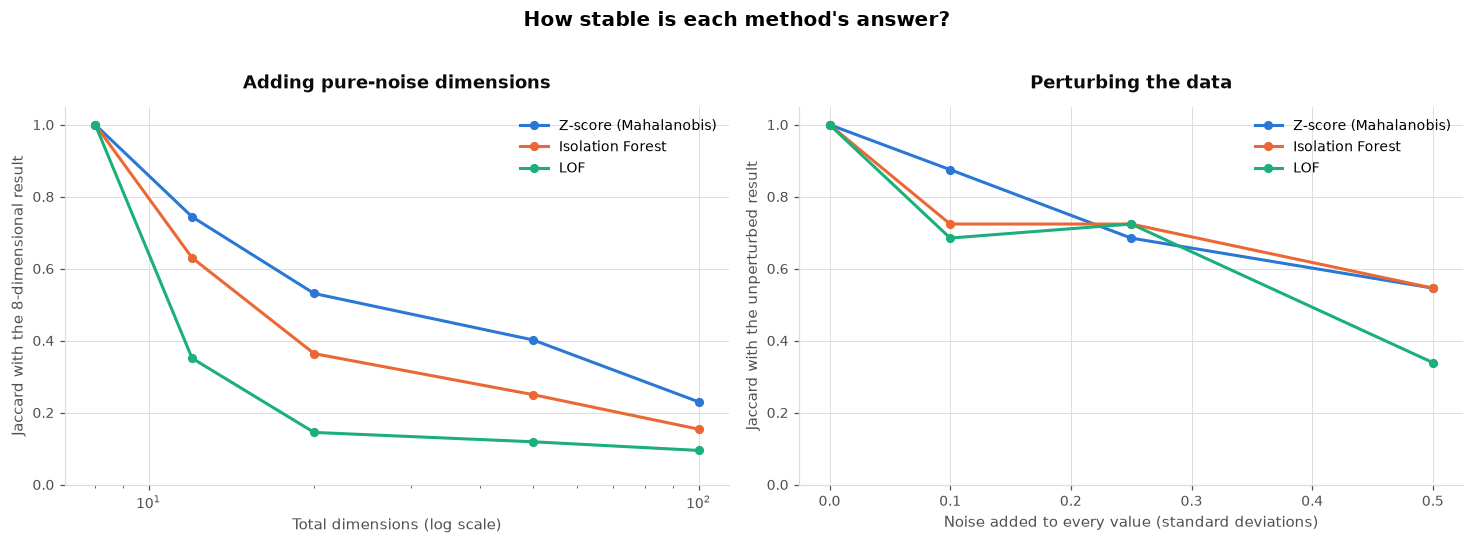

In [35]:
dimensionality = dimensionality_sensitivity(scaled_matrix)
noise = noise_robustness(scaled_matrix)
display(dimensionality)
display(noise)
display(plot_sensitivity_curves(dimensionality, noise))

### 6.4 Sensitivity to Dimensionality and Robustness to Noise

**Results.** Appending columns of pure Gaussian noise — which contain no
information — and measuring how much of the original flag set survives:

| Total dimensions | Mahalanobis | Isolation Forest | LOF |
|---|---|---|---|
| 8 (original) | 1.000 | 1.000 | 1.000 |
| 12 | 0.744 | 0.630 | **0.351** |
| 20 | 0.531 | 0.364 | 0.145 |
| 50 | 0.402 | 0.250 | 0.119 |
| 100 | **0.230** | **0.154** | **0.095** |

Perturbing every value by Gaussian noise instead:

| Noise SD | Mahalanobis | Isolation Forest | LOF |
|---|---|---|---|
| 0.10 | **0.875** | 0.724 | 0.685 |
| 0.25 | 0.685 | 0.724 | 0.724 |
| 0.50 | 0.546 | 0.546 | **0.339** |

**Interpretation — dimensionality.** All three degrade, and the ordering is
consistent: **LOF collapses fastest, Isolation Forest next, Mahalanobis is most
resilient.** Adding just four noise dimensions — a 50% increase — already costs
LOF two-thirds of its flags. At 100 dimensions, of which 92 are noise, none of the
methods retains even a quarter of its original answer.

The mechanism differs by method. LOF suffers from distance concentration: as
dimension grows, the ratio between the nearest and furthest neighbour distances
approaches 1, so "local density" stops discriminating. Isolation Forest suffers
because each split picks one feature at random, so with 92 of 100 features
carrying no signal, roughly 92% of splits are wasted. Mahalanobis holds up best
because it estimates and inverts the full covariance, which lets it down-weight
directions with no structure — but this advantage is fragile: at high dimension the
covariance estimate itself becomes unstable, and it would fail once $p$ approaches
$n$.

**Interpretation — noise.** Here the pattern is weaker, and the table does not
support as strong a claim. **LOF is clearly the least robust at the largest
perturbation**, retaining a third of its flags where the other two retain half,
and that is consistent with what it measures: a density estimate built from 20
neighbours is directly affected by whether those particular neighbours moved,
while a global statistic averages the perturbation away.

But the ordering is **not** consistent across noise levels. At a noise SD of 0.25
the three methods fall within 0.04 of one another and Mahalanobis is nominally
the worst of them. These figures come from a single realisation of the added
noise, so differences of that size are within what re-drawing the noise would
produce and should not be over-read. The defensible conclusion is therefore
narrower than for dimensionality: only LOF's greater fragility at large
perturbations is clearly established, and the three methods are otherwise
comparable.

,Z-score (Mahalanobis),Isolation Forest,LOF
Rows,,,
1500,0.0004,0.1758,0.0110
6000,0.0007,0.2409,0.0749
24000,0.0024,0.4574,0.3267
96000,0.0098,0.9882,0.4923


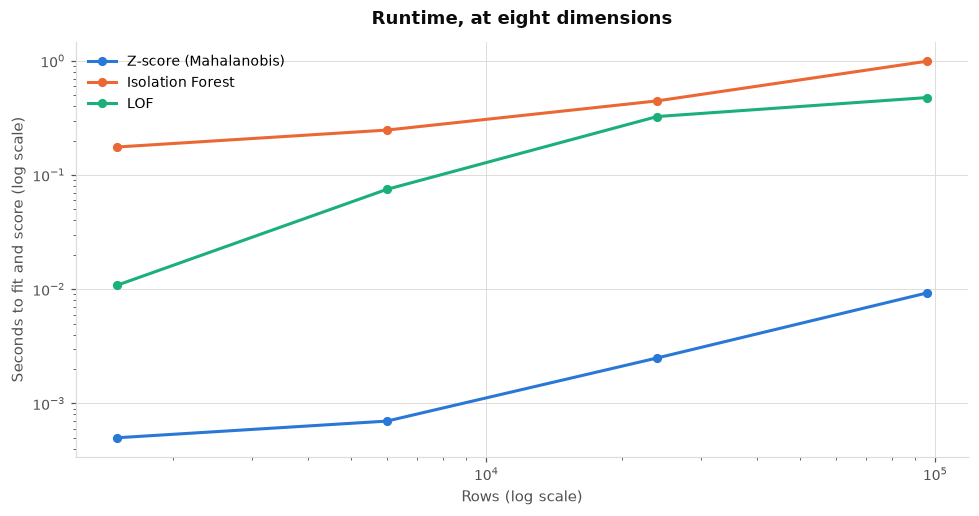

In [36]:
display(runtime_scaling(scaled_matrix))
display(plot_runtime(runtime_scaling(scaled_matrix)))

### 6.5 Runtime and Scalability

**Results.** Seconds to fit and score, at eight dimensions:

| Rows | Mahalanobis | Isolation Forest | LOF |
|---|---|---|---|
| 1,500 | 0.000 | 0.174 | 0.010 |
| 24,000 | 0.002 | 0.457 | 0.312 |
| 96,000 | **0.009** | 0.955 | 0.462 |

**Interpretation.** **Mahalanobis is by far the cheapest** and scales essentially
linearly in the number of rows: its cost is dominated by inverting an
$8\times8$ covariance matrix, which does not depend on $n$ at all. It is two
orders of magnitude faster than the other two throughout.

**Isolation Forest** carries a fixed overhead — building 300 trees costs 0.17
seconds even on 1,500 rows — but grows slowly thereafter, roughly $O(n\log n)$,
and it parallelises across trees.

**LOF** is the fastest of the two learning methods here, but that is a property of
this problem rather than of the method. At eight dimensions a spatial index makes
neighbour search efficient; such indexes degrade towards brute force as dimension
grows, at which point LOF's cost approaches $O(n^2)$. **The ranking observed here
would reverse on a high-dimensional dataset**, and the runtime table should not be
read as a general result.

### 6.6 Interpretability

**Interpretation.** The three methods differ substantially in how easily a flag
can be explained, which matters more in practice than most performance
differences.

**The Z-score approach is the most interpretable.** A feature-wise flag comes with
its own explanation — "this game's price is 6.5 standard deviations above the
mean" — that a non-technical reader can check against the data. The Mahalanobis
version is a step less transparent, since the distance mixes all eight features
through the inverse covariance, but the contribution of each feature can still be
decomposed.

**Isolation Forest is the least interpretable.** Its score is an average path
length over 300 random trees. There is no compact answer to "why was this game
flagged" beyond "random cuts separated it faster than average", and the score's
range in this dataset — 0.393 to 0.673 — has no natural units.

**LOF sits between the two.** Its score has a genuinely meaningful scale: 1.0 means
"as densely surrounded as my neighbours", and 1.75 means "my neighbours live in
regions about 75% denser than mine". That is explainable. But identifying *which*
neighbours drive the score requires further work.

There is a trade-off worth naming: the method that best detects unusual
combinations, Isolation Forest, is also the one least able to say what the unusual
combination was.

### 6.7 False Positives and False Negatives, in Plain Terms

**The central difficulty.** There is **no ground truth**. The dataset carries no
anomaly label — that was one of the selection criteria — so no false positive or
false negative can be counted. What follows is therefore an account of what the
two errors would *mean* and cost, not a measurement of how often they occur.

**Explained without technical vocabulary.** Imagine a shortlist of unusual games,
compiled automatically for a human analyst to review.

- A **false positive** is an ordinary game that lands on the shortlist. Someone
  spends time examining a game that turns out to be perfectly normal. The cost is
  wasted attention — and if the list is mostly false positives, people stop
  reading it. This is the well-known problem of the alarm that cries wolf: a
  detector that flags too much is ignored, and then it detects nothing at all.
- A **false negative** is a genuinely unusual game that never reaches the list.
  Nobody looks at it, and whatever made it unusual — a data-entry error, a pricing
  mistake, a fraudulent sales figure — goes uncorrected. The cost is invisible,
  which is what makes it dangerous: an undetected miss leaves no trace, so a
  detector can appear to be working perfectly while missing most of what matters.

In this dataset the consequences are mild, because the subject is a catalogue of
video games. The same trade-off in medical screening or fraud detection carries
consequences of a completely different order, which chapter 8 takes up.

**Three kinds of flagged observation, which the methods cannot tell apart.** The
assignment asks not to claim an anomaly is "truly anomalous" without evidence. The
75 games each method flags are **statistical anomalies by construction** — that is
precisely what was computed. Whether any is meaningfully unusual is a separate
question, and this dataset contains clear examples of three different answers.

**A probable data error.** *The Elder Scrolls Online: Gold Road* was recorded with
an average playtime of exactly zero despite 27,601 owners and $960,791 in revenue.
An MMO expansion cannot have zero average playtime. Section 2.4 identified this as
a placeholder, and it was converted to a missing value before any method ran —
which is why, notably, **none of the three methods flagged it.** The clearest
error in the dataset is invisible to all of them, because it was disguised as a
valid number and had to be found by inspection rather than by an algorithm.

**A legitimate rare observation.** *Firestone: Online Idle RPG* records 296 hours
of average playtime at a price of zero, and all three methods flag it. It is not
an error. Idle and incremental games are designed to run continuously for months,
and section 2.4 found that three of the four longest playtimes belong to this
genre. It is a **legitimate member of a small subpopulation** that the feature set
describes poorly, because nothing in the eight features records genre. The methods
are right that it is unusual and wrong to imply it is suspect.

**A genuine statistical extreme.** *The First Descendant* earns $102 million at a
listed price of zero. This is real, explicable — free-to-play games monetise
through in-game purchases — and genuinely at the edge of the distribution.

**And a fourth possibility this dataset cannot rule out.** Chapter 1 established
that `revenue` and `copiesSold` are **estimates produced by an undisclosed
third-party model**, not measurements. A game may therefore be flagged because the
estimator behaved unusually for it — an unusual review-count-to-sales ratio, say —
rather than because the game itself is unusual. **Nothing in this analysis can
separate an anomalous game from an anomalously-estimated game.** Resolving it would
require the vendor's methodology or an independent source of sales figures, and
until then every monetary flag carries that ambiguity.

**Conclusion.** The three methods agree on 26 of the 130 games they collectively
flag, and their disagreement is systematic rather than random: each measures a
different geometric notion of "unusual" and each is right on its own terms.
Mahalanobis is the cheapest, the most robust to noise and dimensionality, and
scale-invariant; Isolation Forest finds unusual combinations but is the hardest to
explain and depends on its random seed; LOF finds locally isolated points that
neither global method can see, but requires standardisation, is the most sensitive
to its own parameter, and degrades fastest as dimensions are added. **For this
dataset the Mahalanobis ranking is the most defensible primary result** — it is
the most stable under every perturbation tested — with LOF as a complement for the
locally isolated cases it alone detects. None of the three, however, distinguishes
a genuinely unusual game from an unusually estimated one.

## 7. Critical Analysis and Reflection

**Method.** This chapter addresses the six topics the assignment lists. Four are
answered from results already established in chapters 2 to 6; two — distance
concentration and projection distortion — are supported by small experiments run
here, because the assignment asks *why* these problems occur and a measurement
makes the answer concrete rather than asserted.

,Mean pairwise distance,Relative contrast (max-min)/min,Mean nearest / farthest
Dimension,,,
2,1.78,1931.68,0.015
5,3.01,46.97,0.118
8,3.88,11.74,0.204
20,6.24,3.92,0.396
50,9.96,1.50,0.571
100,14.16,0.99,0.673
500,31.61,0.34,0.836


This dataset (8 dimensions, n=1,500): mean nearest/farthest ratio = 0.096


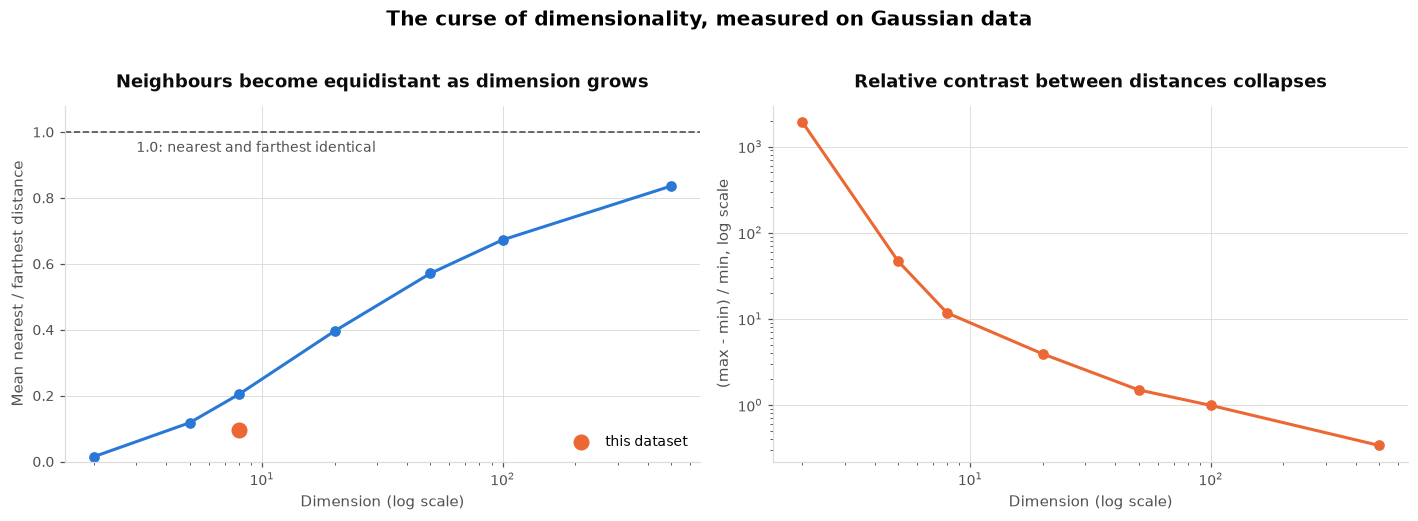

In [37]:
from unsupervised.reflection import (
    distance_concentration,
    observed_contrast,
    projection_distortion,
)
from unsupervised.plots import plot_distance_concentration, plot_projection_distortion

concentration = distance_concentration()
measured = observed_contrast(scaled_matrix)
display(concentration)
print(f"This dataset (8 dimensions, n={len(scaled_matrix):,}): "
      f"mean nearest/farthest ratio = {measured:.3f}")
display(plot_distance_concentration(concentration, measured, scaled_matrix.shape[1]))

### 7.1 Why Anomaly Detection Is Fundamentally Ill-Defined

Chapters 5 and 6 provide the evidence for this in an unusually direct form.

**There is no definition of "anomaly" that the methods share.** Mahalanobis
defines it as distance from a global centre, Isolation Forest as ease of
separation by random cuts, LOF as low density relative to one's neighbours. These
are not three approximations of one concept; they are three different concepts.
Applied to the same data with the same budget of 75 flags, they agreed on **26
games and disagreed on 61**, and section 6.2 showed the disagreements were
principled — each method was right about its own question.

**There is no ground truth to adjudicate between them.** The dataset carries no
anomaly label, which was one of the assignment's selection criteria. Nothing can
be validated. In supervised learning a disagreement between models is settled by
measuring both against held-out labels; here there is nothing to measure against,
so a disagreement simply stands.

**The number of anomalies is an input, not an output.** Section 5.2 established
that Isolation Forest's contamination parameter does not change the ranking at
all — the flags at 1% are strictly nested inside those at 15%, and the score
distribution has no natural break. The analyst decides how many anomalies exist
and the method returns that many. The same is true of the Z-score threshold and of
LOF's contamination. **No method in this chapter discovered how many anomalies the
data contains, because none of them can.**

**And the answer depends on choices made before any method runs.** Section 6.3
showed that moving between the raw and logarithmic scales — with standardisation
applied in both cases — changed Mahalanobis's flags by more than half. The
preprocessing decision taken in section 2.3, on distributional grounds having
nothing to do with anomalies, determined much of the answer.

Taken together: the question "which games are anomalous?" has no unique answer for
this dataset, and the appearance of one comes entirely from fixing a method, a
parameter and a preprocessing pipeline, each of which could reasonably have been
fixed differently.

### 7.2 The Curse of Dimensionality

**Results.** Generating independent Gaussian points and increasing only the
dimension:

| Dimension | Mean nearest / farthest | Relative contrast (max−min)/min |
|---|---|---|
| 2 | 0.015 | 1931.68 |
| 8 | 0.204 | 11.74 |
| 20 | 0.396 | 3.92 |
| 100 | 0.673 | 0.99 |
| 500 | **0.836** | **0.34** |

**Interpretation.** In two dimensions a point's nearest neighbour is about 1.5% as
far away as its farthest — near and far are unambiguous. By 500 dimensions the
nearest neighbour is **84% as far away as the farthest**. Every point has become
approximately equidistant from every other, and the relative contrast between the
largest and smallest distance in the whole dataset collapses from roughly 1,900 to
0.34.

**The effect on anomaly detection is direct.** Every method in chapter 5 rests on
some notion of "far" or "sparse". If all points are nearly equidistant, then:

- **Mahalanobis** distances become nearly equal for all points, so the ranking it
  produces is determined by small differences that are increasingly dominated by
  estimation error in the covariance matrix — which itself needs $O(p^2)$
  parameters estimated from $n$ rows.
- **LOF** compares local densities, but when all neighbour distances converge,
  every local density is nearly the same and every ratio approaches 1.
- **Isolation Forest** is affected differently and less severely: it does not
  compute distances at all. Its problem is dilution — with $p$ features, each
  random split uses one of them, so as the share of uninformative features grows,
  most splits carry no signal.

Section 6.4 measured exactly these predictions on this dataset. Adding pure-noise
dimensions cost LOF two-thirds of its flags by 12 dimensions, and by 100
dimensions all three methods retained less than a quarter of their original
answer — with LOF worst at 0.095, Isolation Forest at 0.154 and Mahalanobis, which
can down-weight uninformative directions through the covariance, best at 0.230.

**This dataset is not badly affected.** At eight dimensions the measured
nearest-to-farthest ratio is **0.096**, better even than the Gaussian reference at
the same dimension (0.204), because real data has structure and is not uniformly
spread. The curse is a reason to be cautious about generalising these results to
wider datasets, not a defect of the analysis performed here.

### 7.3 Why Distance Becomes Less Meaningful in High Dimensions

The mechanism behind section 7.2 is worth stating explicitly, because it explains
*why* rather than merely *that*.

For $p$ independent features, the squared distance between two random points is a
sum of $p$ independent contributions. By the law of large numbers that sum
concentrates around its expectation: the mean distance grows like $\sqrt{p}$
while its standard deviation stays roughly constant, so the **relative** spread of
distances shrinks like $1/\sqrt{p}$. Every pairwise distance converges towards the
same value.

Two consequences follow, and both matter for this notebook.

**"Nearest neighbour" stops being a meaningful designation.** If the nearest
neighbour is 84% as far as the farthest, then which point is nearest is decided by
a small fraction of the total distance and is easily changed by noise. Section
6.4 showed this concretely: perturbing every value by half a standard deviation
cost LOF two-thirds of its flags, because the identity of a point's 20 nearest
neighbours changed.

**Irrelevant features actively destroy the signal rather than merely diluting
it.** Each uninformative dimension adds its own contribution to every pairwise
distance. Adding enough of them makes the distance essentially a measurement of
the noise dimensions, and the informative ones become a vanishing share of the
total. This is why section 6.4's experiment used *pure noise* columns: they carry
no information at all, yet they changed the answer completely.

The practical implication is the one chapter 1 acted on in advance. Excluding
`releaseMonth`, which correlated −0.99 with `daysOnSale`, and the three ratio
features was not only about avoiding manufactured redundancy — it also kept the
dimensionality low enough for distance to remain meaningful. **In a
distance-based analysis, adding a feature is never free.**

### 7.4 Noise Versus a Genuine Anomaly

**The distinction.** *Noise* is variation introduced by the measurement process:
it carries no information about the object measured, and repeating the measurement
would give a different value. A *genuine anomaly* is a real property of the
object: repeating the measurement would give the same unusual value. The two can
look identical in a single observation, which is why they cannot generally be
separated without either repeated measurements or external knowledge.

**This dataset offers no way to separate them empirically.** Each game appears
once, so no value can be checked against a second observation. Worse, chapter 1
established that `revenue` and `copiesSold` come from an undisclosed estimation
model, which introduces a source of variation that is neither measurement noise
nor a property of the game: **model error**. A game may be flagged because the
estimator behaved unusually for it. Nothing here can detect that.

**A legitimate observation that will be detected as anomalous.**

> ***Firestone: Online Idle RPG*** records an **average playtime of 296 hours** —
> more than forty times the dataset median of 6.8 — at a listed price of **zero**,
> while earning **$15.7 million**. All three methods flag it.

It is not an error, and it is not noise. Idle and incremental games are designed
to run continuously in the background for months, and free-to-play titles earn
through in-game purchases rather than a sale price. Section 2.4 found that **three
of the four longest playtimes in the dataset belong to this same genre**, which is
the decisive evidence: an isolated 296-hour reading would be suspect, but a
coherent group of them is a subpopulation.

The reason it is flagged is a limitation of the **feature set**, not of the game.
The eight features record no genre, no monetisation model and no information about
whether a title is designed for sustained engagement. Within the space the methods
can see, an idle game looks like a normal game with an impossible playtime. **The
anomaly is in the representation, not in the world.**

This generalises. An observation is flagged as anomalous when it is unusual *given
the features recorded*. Whether it is unusual in reality depends on whether the
features capture what makes it what it is — and no unsupervised method can
determine that, because it has access only to the features.

### 7.5 The Risks of Assuming a Gaussian Distribution

**The assumption fails here, comprehensively.** Section 5.1 found that
Shapiro-Wilk rejects normality for **all eight features**, with p-values as small
as $1.4\times10^{-41}$, and this is *after* the log transform that reduced
revenue's skewness from 22.9 to 1.19. On the raw scale the situation was far
worse.

**What gets falsely flagged.** The $|z|>3$ rule claims to isolate the rarest 0.3%,
a figure that comes from the normal distribution and from nowhere else. When the
true distribution has heavier tails, ordinary observations sit beyond three
standard deviations and are flagged. Section 5.1 quantified the related
multiple-comparisons effect: testing eight features per game means that **32 of
1,500 games would trip the rule by chance even if the data were perfectly
Gaussian**, against 80 actually flagged. A substantial share of the flags are
consequences of the procedure rather than properties of the games.

**What gets missed, which is the less obvious risk.** Three features in this
dataset **cannot produce a Z-score flag at all**: `selfPublished` reaches a maximum
absolute z of 1.02, `daysOnSale` 1.83, and `publisherReleaseCount` 2.72. A binary
feature never can, because its furthest possible value lies about one standard
deviation from its mean. A game that is unusual in its publishing structure — the
direction PC2 identified as carrying 20% of the variance — is **invisible to this
method by construction**, and no adjustment of the threshold recovers it.

More subtly, the Gaussian framing misses anomalies that are unusual only in
*combination*. A game with typical copies sold and typical revenue but in an
atypical ratio violates the strongest relationship in the dataset — a correlation
of 0.90 — and the feature-wise rule cannot see it, because each value is ordinary
on its own. The Mahalanobis version addresses this by accounting for the
covariance, and section 5.1 showed the two versions agree on only half their
flags.

**The deeper risk is unwarranted confidence.** A z-score of 3.5 sounds precise and
carries an implied probability. That probability is only as good as the
distributional assumption behind it, and here the assumption is rejected at
$p<10^{-19}$ for every feature. The number remains computable and stops meaning
what it appears to mean — which is more dangerous than a method that offers no
number at all.

,Game A,Game B,Distance in 2D,Distance in 8D,Percentile of that 8D distance
0,失乐星图Nornium,Stellar Orphans,0.0240,5.90,93.8
1,失乐星图Nornium,Fossilfuel 2,0.0435,6.16,95.3
2,Perfect World M,Realms Of Bondage,0.0541,5.54,91.1
3,YUME 4,Monster Jam™ Showdown,0.0580,5.78,93.0


Median distance between any two games in the full 8 dimensions: 3.68


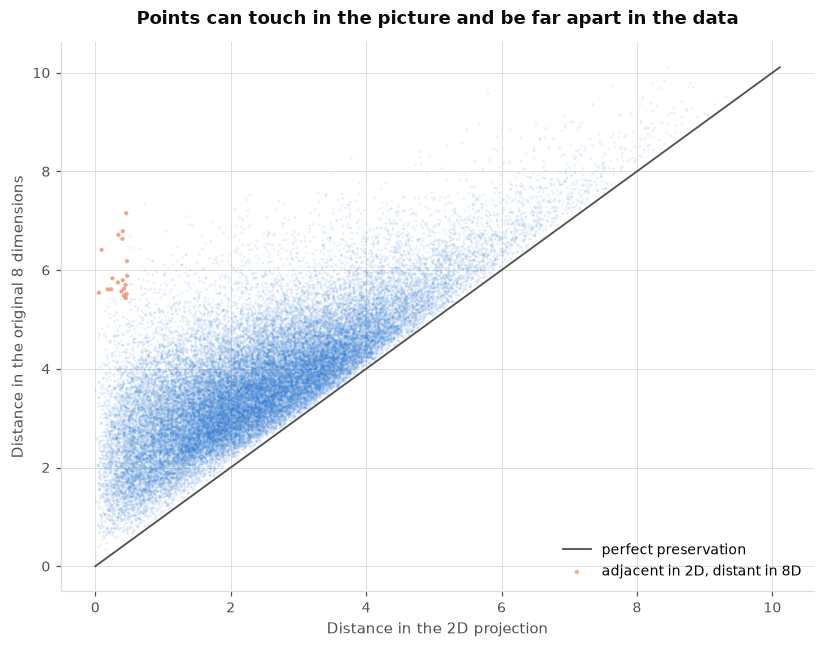

In [38]:
distortion, median_full_distance, projected_distances, full_distances = projection_distortion(
    scaled_matrix, games["name"]
)
display(distortion)
print(f"Median distance between any two games in the full 8 dimensions: {median_full_distance:.2f}")
display(plot_projection_distortion(projected_distances, full_distances))

### 7.6 Why Visualisations After Dimensionality Reduction Can Mislead

**Results.** Searching for the pairs of games that appear closest together in the
2D PCA projection, and checking how far apart they actually are:

| Game A | Game B | Distance in 2D | Distance in 8D | Percentile of that 8D distance |
|---|---|---|---|---|
| 失乐星图Nornium | Stellar Orphans | 0.024 | 5.90 | **93.8** |
| 失乐星图Nornium | Fossilfuel 2 | 0.044 | 6.16 | **95.3** |
| Perfect World M | Realms Of Bondage | 0.054 | 5.54 | 91.1 |
| YUME 4 | Monster Jam™ Showdown | 0.058 | 5.78 | 93.0 |

The median distance between any two games in the full space is **3.68**.

**Interpretation.** These pairs are effectively touching in the picture — a
separation of 0.024 on axes that span roughly nine units — and they are among the
**most distant 6% of all pairs** in the space the analysis actually used. They are
further apart than two games picked at random. A reader inspecting the projection
and concluding that these titles are similar would be wrong, and nothing in the
picture indicates it.

**The mechanism.** PCA preserves the directions of greatest variance, and section
3.1 established that the first two components carry only **49.4%** of it. The
remaining half of the variance is projected away, and two points that differ
almost entirely along the discarded directions collapse onto the same spot.
Section 3.4 measured the aggregate effect: trustworthiness of **0.848**, meaning
roughly one in seven of a point's apparent neighbours in the picture was not a
neighbour in the data.

**Why this matters specifically for anomaly and cluster analysis.** Both depend on
exactly the local relationships the projection distorts.

- A point that appears **inside** a dense cloud may be isolated along a discarded
  dimension. LOF, computed on the full space, will flag it; a reader looking at
  the plot will see a normal point in the middle and conclude the method erred.
- A point that appears **on the edge** of the cloud may simply have an extreme
  value on PC1 while being unremarkable elsewhere.
- The apparent absence of clusters in the section 3.3 projection is weaker
  evidence than it appears **on its own** — separated groups could in principle
  live in the discarded directions.

That last point deserves care, because this notebook relies on it. The conclusion
in chapter 4 that no clusters exist does **not** rest on the projection. It rests
on silhouette scores computed in the full eight dimensions, on DBSCAN finding no
density gap in the full space, and on a cophenetic correlation of 0.487 from
distances in the full space. The projection agrees with those findings; it is not
the reason for them.

**The practical rule this notebook followed.** Every method in chapters 4 and 5
was fitted on the full eight-dimensional matrix, and PCA was used **only to
display** results computed elsewhere. That separation is what keeps the pictures
useful: they communicate a result honestly even where they cannot establish one.

**Conclusion.** The six topics converge on a single caution. Anomaly detection has
no ground truth, no agreed definition, and no data-driven way to fix its own
parameters; distance — the quantity most of its methods depend on — degrades as
dimensionality grows; the Gaussian assumption that gives the simplest method its
interpretation is false for every feature here; a legitimately unusual game is
indistinguishable from an erroneous one without knowledge the data does not
contain; and the pictures used to communicate all of this can place unrelated
points on top of one another. None of this makes the analysis worthless. It means
its outputs are **hypotheses for a human to examine**, not determinations, and
that is how chapter 6 framed the 130 flagged games.

## 8. Ethical Considerations

**Method.** This chapter contains no computation. It addresses the five topics
the assignment lists, and it distinguishes carefully between two kinds of claim.

**What this dataset supports.** The subject here is a catalogue of commercially
released video games. Nobody is surveilled, no individual is profiled, and the
consequences of a wrong answer are commercial at worst. Where a finding from
chapters 5 to 7 illuminates a general problem, it is used and labelled as such.

**What it does not.** Several of the topics below concern medicine, policing and
security, where the stakes are of a completely different order. Those discussions
are **general**, drawing on the mechanisms this notebook demonstrated rather than
on its subject matter. Claiming that a games dataset raises surveillance concerns
would be false, and the distinction is maintained throughout.

The connection that does transfer is **methodological**: the same three
algorithms, with the same properties and the same failure modes, are deployed in
all of these settings. Everything chapter 7 established about ill-definedness,
parameter dependence and representation limits applies wherever they are used.

### 8.1 The Consequences of False Alarms

**What this analysis showed.** Chapter 6 found that of the 130 games flagged by
at least one method, **61 were flagged by exactly one** and only 26 by all three.
An analyst reviewing the union of all three methods would examine 130 games —
8.7% of the catalogue — to reach the 26 that every method agrees on. Under the
strictest reading, roughly four in five of the flags they examine are things the
other methods considered ordinary.

There is no way to reduce this by tuning, because section 5.2 established that
the number of flags is an input rather than an output: contamination sets how
many alarms the system raises, and the analyst chooses it.

**Why too many false alarms make a system ineffective.** The failure is not
arithmetic but human. A detector that flags a large volume of ordinary cases
imposes a review cost on someone, and when most of what they review turns out to
be nothing, they stop reviewing carefully. The alarm is still raised and no longer
read. A system with a high false-alarm rate can therefore be **worse than no
system at all**, because it consumes attention that would otherwise have gone to
unassisted judgement, while creating the impression that the problem is covered.

This is sharpest when the condition being detected is rare. If genuine anomalies
are 1% of cases and a detector flags 5%, then even a perfect detector produces
four false alarms for every true one — a consequence of the base rate, not of
poor tuning. Improving the detector cannot fix it; only changing what happens
after an alarm can.

**The practical implication** is that the threshold is a decision about people's
time and attention, not only about statistics, and it belongs to whoever bears
the cost of reviewing. Section 6.7 made the same point in the language of false
positives and negatives.

### 8.2 Anomaly Detection in Surveillance

**Stated generally**, since this dataset contains no personal data.

**The benefits are real.** The same techniques detect equipment failures before
they cause harm, identify fraudulent transactions, and find safety incidents in
industrial monitoring. Where the object of detection is a machine or a
transaction, the case is largely uncontroversial.

**The risks arise when the object is a person**, and three of them follow
directly from findings in this notebook.

**Unusual is not wrongful.** Every method here defines anomalous as *statistically
uncommon given the recorded features*. Applied to people, that flags whoever
differs from the majority — which may mean an unusual work schedule, an atypical
travel pattern, a disability, or membership of a minority. Section 7.4's central
example makes the mechanism concrete: *Firestone: Online Idle RPG* was flagged by
all three methods, and it was flagged because it belongs to a **legitimate
subpopulation the feature set does not describe**. Transferred to people, that is
the precise mechanism by which surveillance systems disproportionately flag
minorities: not through explicit prejudice, but because the features available
describe the majority well and the minority poorly.

**The definition is chosen, not discovered.** Chapter 7.1 established that the
methods disagreed on 61 of 130 cases and that no ground truth could adjudicate
between them. In a surveillance context this means the operator's choice of
method and parameters determines who is flagged, while the output carries the
authority of having been produced by an algorithm.

**Being flagged has consequences that being ordinary does not.** A statistical
flag is a hypothesis. Once it enters a record it tends to be treated as a finding,
and the person flagged usually has no way to see the features, the parameters or
the threshold that produced it.

The governing question is therefore not whether such systems work, but **what
happens after a flag** — whether it triggers a human review with the power to
dismiss it, whether the affected person is told, and whether they can contest it.

### 8.3 Medical Applications

**Stated generally.**

The two errors are asymmetric and the asymmetry runs the opposite way from most
commercial settings. A **false negative** — a patient whose abnormal result is not
flagged — may mean a disease progresses untreated. A **false positive** may mean
unnecessary further testing, some of which carries its own risk, along with
avoidable anxiety and cost. Missing a case is usually the graver error, which is
why screening programmes are typically tuned towards sensitivity.

**Three cautions from this notebook transfer directly.**

**The Gaussian assumption is dangerous in exactly the population that matters.**
Section 7.5 showed that a $|z|>3$ rule inherits its meaning entirely from
normality, and that when the assumption fails the number remains computable while
ceasing to mean what it appears to. Physiological measurements are frequently
skewed or bounded, and a rule calibrated on a healthy majority will systematically
misjudge the tails — which is where the patients of interest are.

**Rare legitimate variation gets flagged as pathology.** The *Firestone* case is
the analogue: an observation that is unusual because it belongs to a small
subpopulation the features do not distinguish. In a clinical setting a healthy
person with atypical baseline physiology may be repeatedly flagged, and if the
subpopulation correlates with ancestry, age or sex, the burden falls unevenly.

**Medicine has something this analysis does not: eventual ground truth.** A biopsy
or a follow-up can establish whether a flag was correct. That makes clinical
anomaly detection a fundamentally better-posed problem than the one in this
notebook — and it means the reasonable use of an unsupervised flag is to
**prioritise investigation**, never to conclude it.

### 8.4 Cybersecurity

**Stated generally.**

**Missing a genuine attack** can mean data theft, ransomware, or a persistent
intrusion that remains undetected for months. The cost is potentially unbounded
and, crucially, **invisible**: an undetected breach leaves no alarm, so a detector
missing most attacks can appear to be working perfectly.

**Flagging legitimate activity** blocks or delays real users and consumes analyst
time. This cost is smaller per incident but continuous and highly visible.

**Why the trade-off is harder here than the asymmetry suggests.** It is tempting
to conclude that one should always err towards sensitivity, since a missed breach
costs more than a blocked login. Section 8.1 explains why that reasoning fails in
practice: security operations centres are staffed by people with finite attention,
and a detector tuned to catch everything produces a queue nobody can work through.
Alert fatigue is a documented cause of real intrusions being missed **inside**
systems that flagged them correctly. Raising sensitivity past a certain point
reduces the number of attacks actually caught.

**Two findings from this notebook bear on the design.** Section 6.1 found the
three methods agreeing on only 26 of 130 cases while each was defensible on its
own terms — which supports **combining methods and prioritising the consensus**,
since a case flagged by several detectors with different geometries is stronger
evidence than one flagged by any single detector. And section 6.4's dimensionality
result is directly relevant: network telemetry is very high-dimensional, and all
three methods lost most of their signal once uninformative dimensions dominated.
**Feature selection matters more than method selection** in that setting.

An adversarial consideration has no analogue in this dataset but should be noted:
a security attacker chooses their behaviour knowing a detector exists, and can
stay inside the normal region deliberately. Games do not adapt to avoid being
flagged.

### 8.5 Privacy, Bias, Fairness, and the Consequences of Labelling

**Privacy.** Anomaly detection requires collecting the behaviour it examines, and
detecting rare events requires observing enough of the population that rarity can
be judged. The method therefore creates an incentive towards broad collection and
long retention, which is in direct tension with data minimisation. There is a
second and subtler exposure: **being flagged is itself information about a
person**, produced by the system rather than volunteered, and often not disclosed
to them.

**Bias.** This is where the notebook's findings transfer most directly, and the
mechanism does not require anyone to intend it.

Every method here flags what is uncommon *given the recorded features*. If a
group is under-represented in the data, its members are statistically unusual by
construction. If the features describe the majority well and the minority poorly,
the minority is flagged more often — and the *Firestone* case in section 7.4 is
exactly this: an idle game flagged by all three methods because the feature set
records no genre, so a legitimate design became an inexplicable outlier.

Chapter 1 recorded a second, structural source. This dataset is a **survivorship
sample**: the top 1,500 earners, not a sample of Steam. Everything downstream
describes anomalies *within an already-successful population*. A system trained on
a population that excludes the people it will later judge is a recurring pattern
in deployed systems, and the resulting errors fall on those least represented in
the training data.

**Fairness.** Two consequences follow. Statistical rarity is not misconduct, and
treating it as a proxy for wrongdoing means penalising people for being different.
And because chapter 5 showed that thresholds are chosen rather than discovered, a
system's flag rate — and therefore its burden on any group — is a decision an
operator makes and should be accountable for. It is worth checking flag rates
across groups, which is measurable even when correctness is not.

**The consequence of the label "abnormal".** This is the deepest issue and it is
partly linguistic. What these methods compute is a distance, a path length, or a
density ratio. What gets recorded is a binary label. Three things are lost in that
step:

- **Uncertainty.** Section 5.2 showed the Isolation Forest score distribution to
  be smooth with no natural break. The distinction between the 75th and 76th
  ranked game is arbitrary, yet one is labelled and the other is not.
- **The reason.** Section 6.6 found Isolation Forest to be the least interpretable
  of the three; a person flagged by it cannot be told why in terms they could
  contest.
- **The possibility of being wrong about the data itself.** Chapter 1 established
  that this dataset's key variables are **vendor estimates rather than
  measurements**, and section 6.7 concluded that no method here can distinguish an
  anomalous game from an anomalously *estimated* one. Where the analogous
  situation involves a person, they may be labelled abnormal on the basis of a
  number that was never measured and cannot be audited.

**Conclusion.** The methods in this notebook are descriptive tools: they identify
points that are unusual with respect to a chosen representation, under a chosen
definition, at a chosen threshold. Every one of those choices was shown in chapters
5 to 7 to change the answer materially. Applied to a catalogue of games, the
consequence of getting it wrong is a misdirected hour of analysis. Applied to
people, the same machinery produces the same kind of error with consequences that
do not scale down — and the appropriate safeguards follow from the technical
findings rather than being separate from them: **treat a flag as a hypothesis for
human review, disclose that a system is in use, keep the ability to contest a
label, and measure who is being flagged even when correctness cannot be measured.**

## 9. Optional Bonus — Dashboard (+5%)

**This section is the optional bonus and is additive.** It introduces no new
analysis, changes no parameter and revises no conclusion. Every quantity shown
was computed in chapters 3 to 6 and is reused here; the purpose is to bring the
main results onto one screen for a reader who wants the summary without the
derivation.

It is deliberately **static**. An interactive version using widgets would appear
blank to anyone reading the notebook without executing it, so the figures and
tables below render identically whether the notebook is run, exported, or viewed
on a file host.

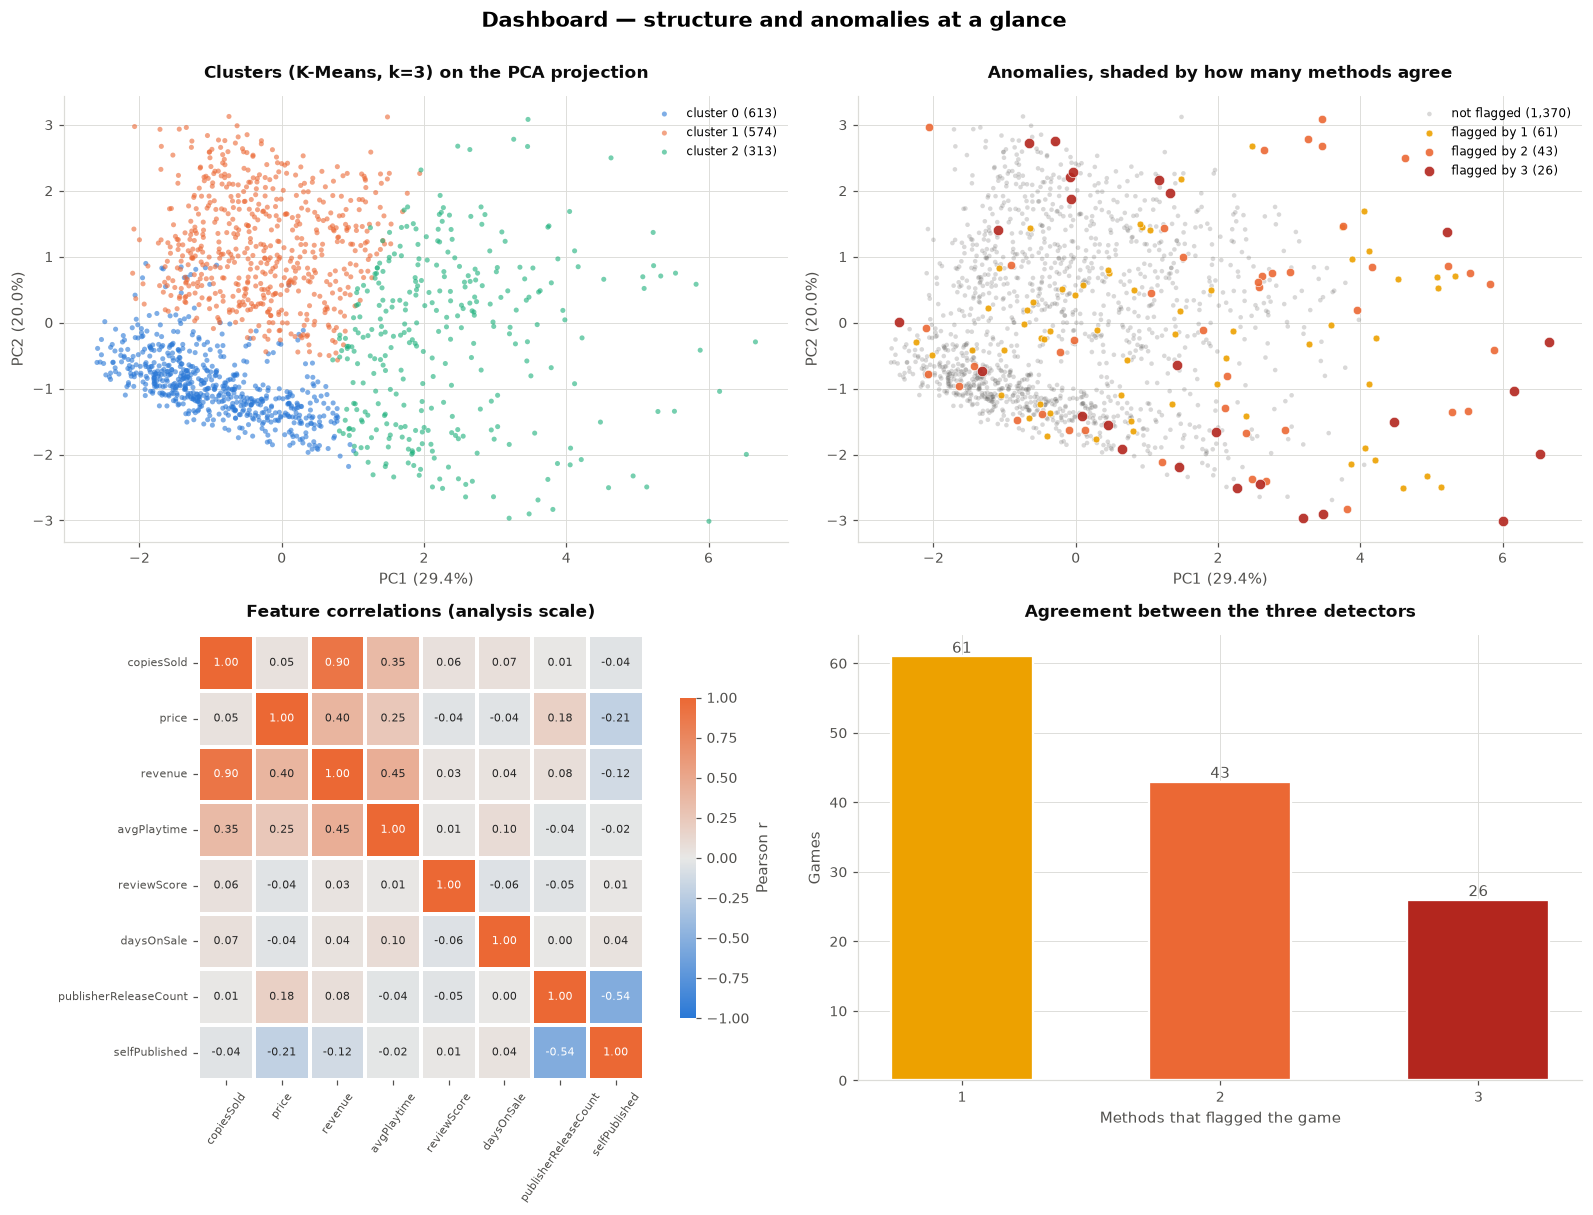

In [39]:
from unsupervised.plots import plot_dashboard_overview, plot_dashboard_pairplot

# Everything below reuses objects already built in chapters 3 to 6.
display(plot_dashboard_overview(
    scores[:, :2],
    labellings[f"K-Means (k={KMEANS_K})"],
    methods_per_game,
    log_matrix.corr(),
    variance,
))

**Panel guide.** Top left: the K-Means partition from section 4.5, shown on the
principal components from section 3.3 — three strata along a continuous gradient
rather than separated groups. Top right: the same projection with each game
shaded by how many of the three detectors flagged it, from section 6.1. Bottom
left: the correlation structure from section 2.3 on the analysis scale. Bottom
right: the agreement counts from section 6.1, where the tallest bar is the games
flagged by only one method.

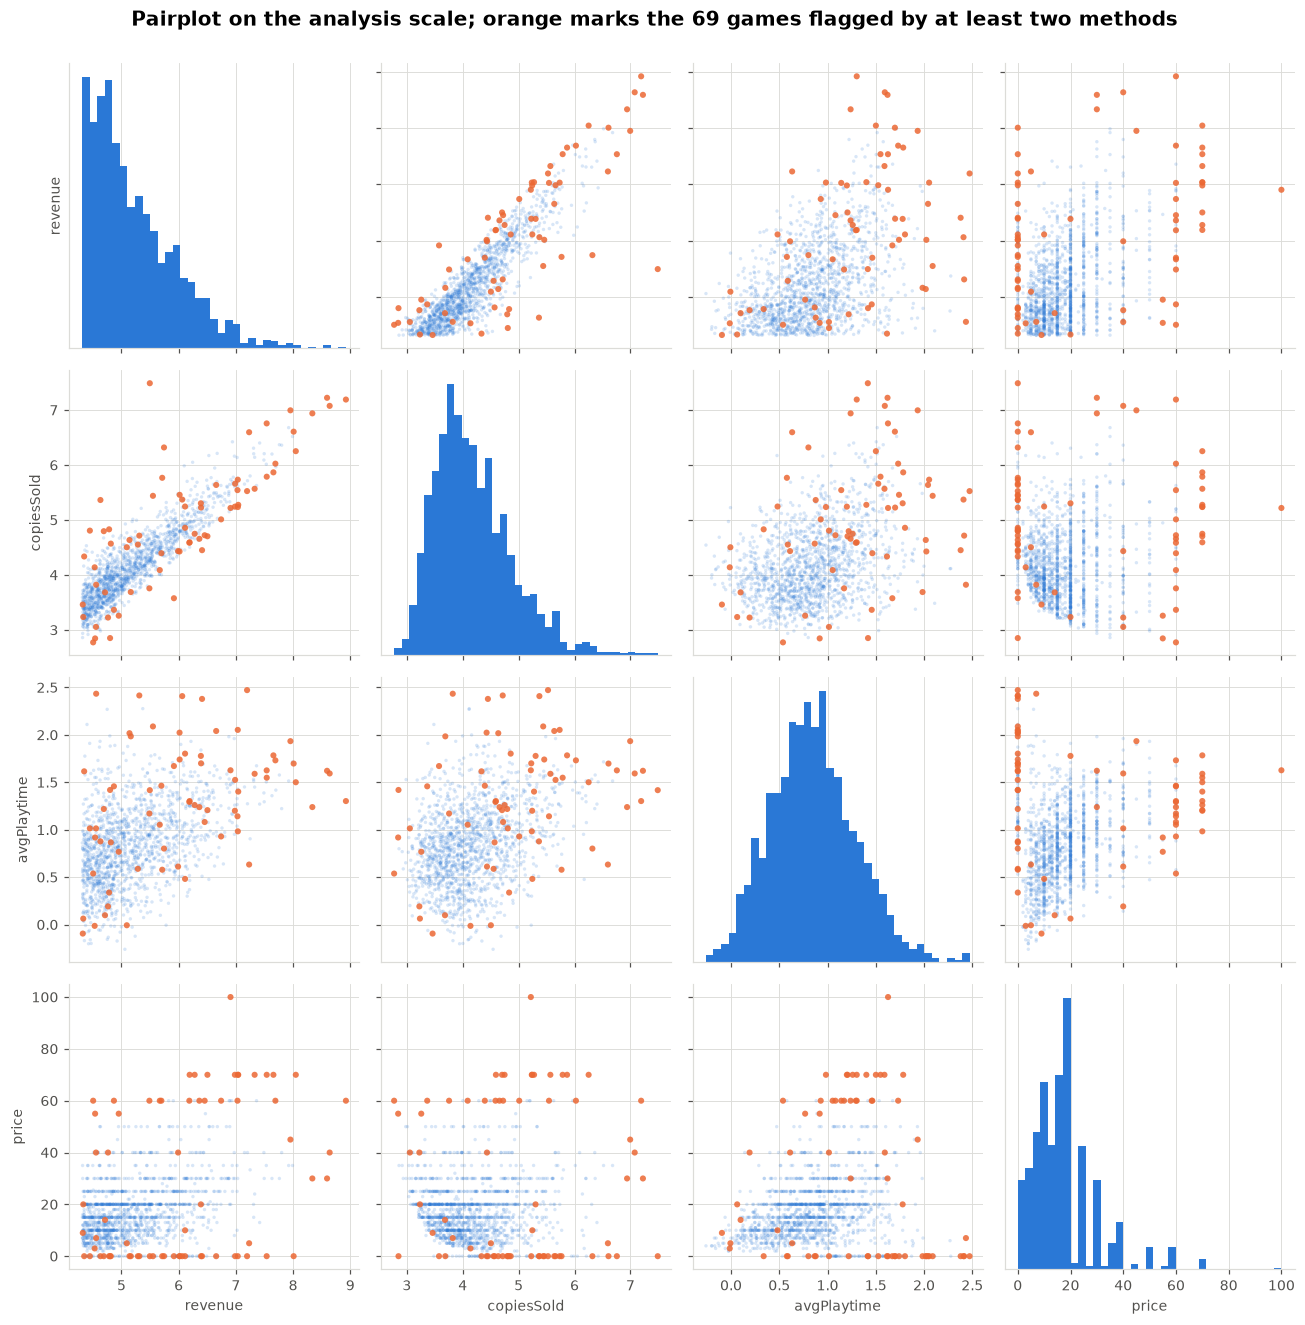

In [40]:
DASHBOARD_FEATURES = ["revenue", "copiesSold", "avgPlaytime", "price"]
display(plot_dashboard_pairplot(log_matrix, DASHBOARD_FEATURES, methods_per_game))

**Pairplot.** The four features with the strongest mutual relationships, on the
analysis scale, with the games flagged by at least two methods marked. The tight
`revenue`–`copiesSold` band is the 0.90 correlation identified in section 2.3;
the vertical striping in `price` is the discreteness noted in section 2.4. The
flagged games sit mainly at the edges of each cloud, though several fall inside
it — those are the locally isolated cases only LOF detects.

In [41]:
method_summary = pd.DataFrame(
    [
        {
            "Method": "Z-score (Mahalanobis)",
            "What it measures": "Distance from the global centre, adjusted for feature correlations",
            "Key parameter": "Threshold / contamination (5%)",
            "Strength": "Cheapest, most robust to noise and dimensionality, scale-invariant",
            "Weakness": "Assumes one centre; normality assumption rejected for all 8 features",
        },
        {
            "Method": "Isolation Forest",
            "What it measures": "How few random axis-parallel cuts isolate the point",
            "Key parameter": "contamination (5%), n_estimators (300)",
            "Strength": "Finds unusual combinations; no distance computation; scale-invariant",
            "Weakness": "Least interpretable; depends on the random seed (Jaccard 0.79-0.85)",
        },
        {
            "Method": "Local Outlier Factor",
            "What it measures": "Local density relative to that of the point's own neighbours",
            "Key parameter": "n_neighbors (20), contamination (5%)",
            "Strength": "Only method that detects locally isolated points",
            "Weakness": "Requires standardisation; most sensitive to its parameter and to added dimensions",
        },
    ]
).set_index("Method")

with pd.option_context("display.max_colwidth", 78):
    display(method_summary)

,What it measures,Key parameter,Strength,Weakness
Method,,,,
Z-score (Mahalanobis),"Distance from the global centre, adjusted for feature correlations",Threshold / contamination (5%),"Cheapest, most robust to noise and dimensionality, scale-invariant",Assumes one centre; normality assumption rejected for all 8 features
Isolation Forest,How few random axis-parallel cuts isolate the point,"contamination (5%), n_estimators (300)",Finds unusual combinations; no distance computation; scale-invariant,Least interpretable; depends on the random seed (Jaccard 0.79-0.85)
Local Outlier Factor,Local density relative to that of the point's own neighbours,"n_neighbors (20), contamination (5%)",Only method that detects locally isolated points,Requires standardisation; most sensitive to its parameter and to added dim...


In [42]:
flagged_table = games.assign(
    Methods=methods_per_game,
    **{name: method_flags[name] for name in method_flags},
)
flagged_table = flagged_table[flagged_table["Methods"] >= 2].copy()
flagged_table["Detected by"] = [
    ", ".join(name.split(" (")[0] for name in method_flags if row[name])
    for _, row in flagged_table.iterrows()
]
flagged_table = (
    flagged_table.sort_values(["Methods", "revenue"], ascending=[False, False])
    .loc[:, ["name", "Methods", "Detected by", "revenue", "copiesSold", "price",
             "avgPlaytime", "reviewScore", "plotClass"]]
    .rename(columns={"name": "Game"})
    .reset_index(drop=True)
)

print(f"Games flagged by at least two of the three methods: {len(flagged_table)}")
print(f"  of which all three agree on: {int((flagged_table['Methods'] == 3).sum())}")
with pd.option_context("display.max_rows", 25, "display.max_colwidth", 40):
    display(flagged_table.head(25).style.format(
        {"revenue": "${:,.0f}", "copiesSold": "{:,.0f}", "price": "${:.2f}",
         "avgPlaytime": "{:.1f}", "reviewScore": "{:.0f}"}
    ))

Games flagged by at least two of the three methods: 69
  of which all three agree on: 26


,Game,Methods,Detected by,revenue,copiesSold,price,avgPlaytime,reviewScore,plotClass
0,Black Myth: Wukong,3,"Z-score, Isolation Forest, LOF","$837,793,356","15,517,278",$59.99,20.1,96,AAA
1,HELLDIVERS™ 2,3,"Z-score, Isolation Forest, LOF","$435,635,596","11,905,198",$39.99,39.2,71,AAA
2,Palworld,3,"Z-score, Isolation Forest, LOF","$392,328,553","16,704,850",$29.99,41.8,94,AA
3,The First Descendant,3,"Z-score, Isolation Forest, LOF","$102,244,808","4,043,850",$0.00,49.9,55,AA
4,7 Days to Die,3,"Z-score, Isolation Forest, LOF","$89,781,931","9,877,443",$44.99,85.9,89,AA
5,Firestone: Online Idle RPG,3,"Z-score, Isolation Forest, LOF","$15,689,364","335,093",$0.00,296.3,79,Indie
6,Summoners War,3,"Z-score, Isolation Forest, LOF","$10,787,342","540,801",$0.00,112.9,nan,Indie
7,WWE 2K24,3,"Z-score, Isolation Forest, LOF","$8,055,097","165,301",$99.99,42.4,71,AAA
8,Predecessor,3,"Z-score, Isolation Forest, LOF","$4,523,840","433,605",$0.00,109.9,79,Indie
9,吞食天地2：誕生Reborn,3,"Z-score, Isolation Forest, LOF","$2,562,504","28,202",$0.00,239.4,42,Indie


**Reading the table.** The 69 games flagged by two or more methods, ordered by
the number of detectors that agree and then by revenue; the first 25 are shown.
Static output cannot be sorted interactively, so the ordering is fixed at the
most useful one — strongest consensus first.

The `Detected by` column is what makes this more than a list. A game marked by
all three is unusual under every definition tested. A game marked by *Isolation
Forest* and *Z-score* but not *LOF* is globally extreme but sits in a normally
dense neighbourhood. A game marked by *LOF* and one other is locally isolated.
Section 6.2 works through examples of each.

**A caution that belongs with the table rather than after it.** Every row is a
**statistical** anomaly — that is what was computed. Section 6.7 established that
this dataset cannot distinguish a genuinely unusual game from a data error or
from an artefact of the vendor's revenue estimator, and section 7.4 showed a
flagged game, *Firestone: Online Idle RPG*, that is entirely legitimate. **The
table is a shortlist for human review, not a list of findings.**

### 9.1 Interactive Threshold Control

Chapter 5.2 established that the contamination parameter does not change the
Isolation Forest's ranking of the games — it only decides where that ranking is
cut, and the flags at successive levels are strictly nested. The control below
makes that concrete: it re-cuts a ranking computed once rather than refitting the
forest, so moving the slider is instant and shows exactly what the parameter
does and does not control.

**Both a static and an interactive view are produced.** The first figure is
rendered unconditionally at the 5% used throughout the notebook, so this section
is complete for a reader who opens the file without executing it. The slider
below it becomes active when the notebook is run with `ipywidgets` available.

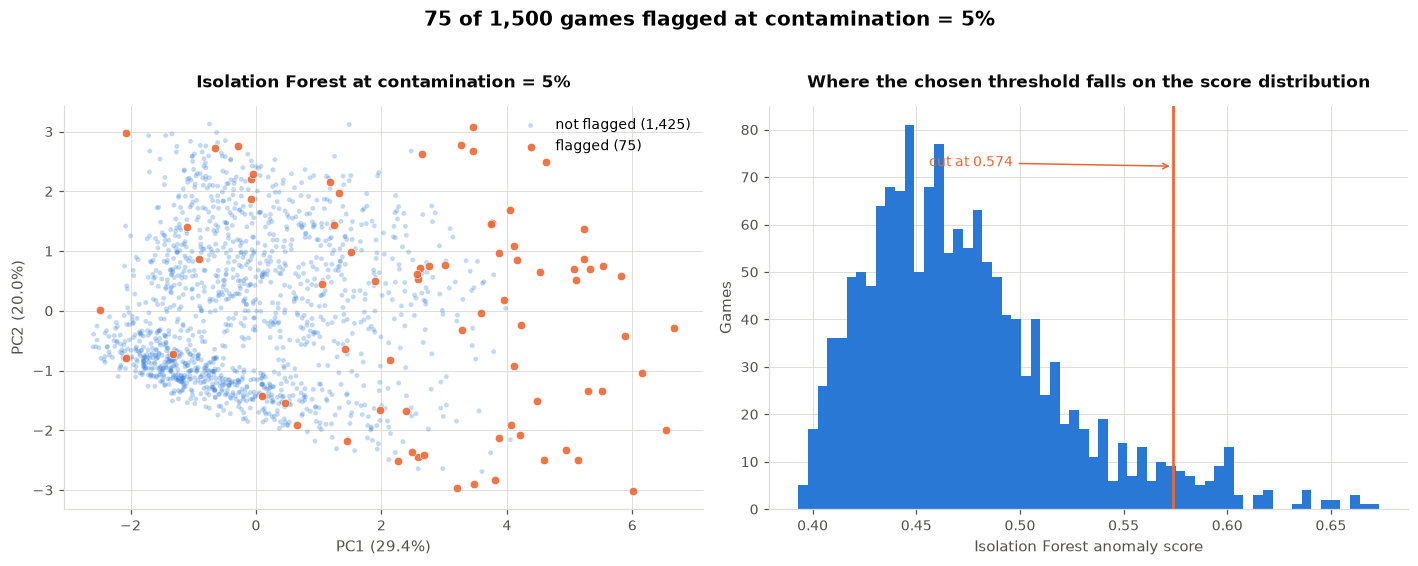

interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='contamination', max=0.2, m…

Slider active. The static 5% view above is unaffected by it.


In [43]:
from unsupervised.plots import plot_threshold_view

# Static view: always rendered, so the section stands on its own when the
# notebook is read without being executed.
display(plot_threshold_view(isolation_score, scores[:, :2], variance, CONTAMINATION))

# Interactive view: active when the notebook is executed and ipywidgets is present.
try:
    from ipywidgets import FloatSlider, interact

    interact(
        lambda contamination: display(
            plot_threshold_view(isolation_score, scores[:, :2], variance, contamination)
        ),
        contamination=FloatSlider(
            value=CONTAMINATION, min=0.01, max=0.20, step=0.01,
            description="contamination", readout_format=".0%",
            continuous_update=False,
        ),
    )
    print("Slider active. The static 5% view above is unaffected by it.")
except ImportError:
    print("ipywidgets is not installed, so only the static 5% view above is shown. "
          "Install it with 'pip install ipywidgets' to enable the slider.")

**What the control demonstrates.** Moving the slider changes how many games are
labelled, and nothing else. The score distribution in the right-hand panel is
fixed; only the vertical cut moves across it. Games leave and enter the flagged
set strictly in rank order, which is the nesting property measured in section
5.2 — every game flagged at 1% is still flagged at 20%.

This is the practical form of the conclusion in section 7.1: **the number of
anomalies in this dataset is an input, not a discovery.** The slider is a control
over an assumption, not over a finding, and no position on it is more correct
than another on the evidence available.